In [2]:
import pandas as pd 
import os 
import sys
from dotenv import load_dotenv
from pathlib import Path 
import re 
import numpy as np 
import plotly.express as px 
import plotly.io as pio
pio.renderers.default = "notebook_connected" 
import matplotlib as mpl
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Dropout, Input, LeakyReLU, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input
from sklearn.metrics import classification_report
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score,recall_score, precision_score, ConfusionMatrixDisplay, classification_report, balanced_accuracy_score, f1_score
import shap
from sklearn.inspection import PartialDependenceDisplay
from sklearn.manifold import TSNE
from sklearn import clone
import pandas as pd
from kmodes.kprototypes import KPrototypes
import optuna
import optuna.visualization as vis
import os
import joblib

# Ustawienie ścieżek
notebook_path = Path.cwd()
project_root = notebook_path.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


from src.data.load_data import train_dev_test_split, load_db, structurize,load_prepare_csv
from src.pipeline.pipe_config import preprocessor
from src.model.diag_vis import get_model_summary, plot_cm, plot_loss
from src.model.experimental_models import build_model_1, build_model_2
from src.model.train_opt import get_metrics, early_stopping, lr_decay, get_params
from src.model.diag_vis import plot_loss,plot_cm,plot_metrics
from src.model.experimental_models import build_model_1,build_model_2,build_best_opt_model
from src.model.train import train_and_save_model


RANDOM_STATE = 42

sns.set_context("talk") # Automatycznie powiększa czcionki dla "prezentacji"
pd.set_option('display.max_rows', 90)

# Dwie linijki ponizej powodują, że biblioteki odświeżają się przy każdym uruchomieniu komórki w notebooku

%load_ext autoreload
%autoreload 2

# Etap II: Modelowanie Predykcyjne i Ewaluacja

Mając za sobą rygorystyczny proces czyszczenia, transformacji danych i inżynierii cech, przechodzimy do kluczowego etapu projektu – budowy systemu predykcyjnego. Przygotowany wcześniej zbiór (6589 obserwacji, 38 predyktorów) oraz hermetyczny potok przetwarzania (`Pipeline`) stanowią teraz solidny, ustandaryzowany fundament pod algorytmy uczenia maszynowego. 



Dzięki zamknięciu całej logiki transformacji (imputacji, skalowania, kodowania zmiennych kategorycznych) wewnątrz ujednoliconego obiektu, całkowicie eliminujemy ryzyko wycieku danych (Data Leakage) podczas treningu. Gwarantuje to, że nasze wyniki będą w pełni wiarygodne i od razu gotowe do konteneryzacji oraz wdrożenia.

### Główne cele tego etapu:

* **Trening i selekcja architektur:** Zestawienie ze sobą różnych metodologii uczenia – od zaawansowanych modeli opartych na zespołach drzew decyzyjnych (Gradient Boosting / XGBoost), po architekturę głębokich sieci neuronowych (ANN) – w celu oceny ich zdolności do wychwytywania nieliniowych wzorców zachowań klientów.
* **Zaawansowana optymalizacja:** Przeszukanie przestrzeni hiperparametrów za pomocą nowoczesnych frameworków (Optuna) w celu maksymalizacji zdolności uogólniania modelu na nowych danych.
* **Kalibracja prawdopodobieństw i optymalizacja progu (Threshold):** Przejście od surowych prawdopodobieństw odcięcia do twardych decyzji biznesowych. Skupimy się na znalezieniu optymalnego progu klasyfikacji, który najlepiej zbalansuje czułość (Recall) z kosztami operacyjnymi.
* **Wielowymiarowa ewaluacja:** Ocena modeli wykraczająca poza standardową dokładność (Accuracy). Główny nacisk położony zostanie na metryki odporne na niezbalansowanie klas: **ROC AUC**, **F1-Score**

---

> **Perspektywa Biznesowa:** Celem tego etapu nie jest wyłonienie modelu o "najwyższych metrykach na papierze", lecz dostarczenie skalowalnego narzędzia biznesowego. Precyzyjnie skalibrowany algorytm pozwoli działom utrzymania (Retention) na proaktywne typowanie klientów o wysokim ryzyku odejścia, optymalizując tym samym alokację budżetu marketingowego i maksymalizując zwrot z inwestycji (ROI).

In [5]:
mpl.rcParams['figure.figsize'] = (12, 10)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
load_dotenv()

True

In [6]:
# Wczytanie danych z bazy 
df_ori = load_db("SELECT * FROM v_telcom_full_data")
# Strukturyzacja
df_structurized= structurize(df_ori)
# Przygotowanie danych do podziału
df_prepared_for_split = load_prepare_csv(data_frame=df_structurized,
                  cols_to_drop=['customer_id','churn_reason','churn_category', 'age', 'mean_income','zip_code','gender'])
# Split na 3 zbiory, wykorzystując autorską funkcję
X_train, X_dev, X_test, y_train, y_dev, y_test = train_dev_test_split(df_prepared_for_split, RANDOM_STATE)
preprocessing_pipeline = preprocessor()
# Dopasowanie i przekształcenie zbioru treningowego
X_train_proc = preprocessing_pipeline.fit_transform(X_train,y_train)
X_dev_proc = preprocessing_pipeline.transform(X_dev)
X_test_proc = preprocessing_pipeline.transform(X_test)


Liczba rekordów po usunięciu nowych klientów: 6589


### Kompensacja Niezbalansowania Klas (Class Weighting & Initial Bias)

Zbiory danych dotyczących odejść klientów (Churn) z natury charakteryzują się silnym niezbalansowaniem – odsetek klientów rezygnujących z usług jest zazwyczaj znacznie mniejszy niż lojalnej bazy użytkowników. Bez odpowiedniej interwencji matematycznej, modele (szczególnie sieci neuronowe) mają tendencję do faworyzowania klasy dominującej (ciągłe przewidywanie wartości `0`), co prowadzi do iluzorycznie wysokiej dokładności (Accuracy) przy drastycznie niskiej czułości (Recall).

Aby temu zapobiec, przed inicjalizacją modeli definiujemy funkcję pomocniczą, która dynamicznie oblicza dwa kluczowe parametry optymalizacyjne na podstawie rozkładu zbioru treningowego:

1. **Wagi klas (Class Weights):** Stosujemy heurystykę odwrotnej proporcjonalności, która "karze" model znacznie surowiej za przeoczenie klienta odchodzącego (klasa mniejszościowa) niż za błąd na kliencie pozostającym. Wykorzystujemy standardową formułę wyrównującą całkowity wpływ obu klas na gradient funkcji straty:
$$w_j = \frac{n_{samples}}{n_{classes} \cdot n_{samples, j}}$$

2. **Inicjalizacja obciążenia dla Sieci Neuronowych (Initial Bias):** Jest to krytyczny krok optymalizacyjny dla architektury ANN. Zamiast inicjalizować warstwę wyjściową losowo, ustawiamy jej początkowe obciążenie na wartość logarytmu szans (log-odds) wystąpienia klasy pozytywnej:
$$b_0 = \log\left(\frac{pos}{neg}\right)$$

> **Wartość Inżynieryjna:** Wprowadzenie `initial_bias` sprawia, że w epoce zero (przed jakimkolwiek treningiem) sieć neuronowa zwraca prawdopodobieństwo predykcji równe bazowemu rozkładowi klas w zbiorze danych. Pozwala to uniknąć tzw. "hockey stick loss curve", drastycznie przyspiesza konwergencję (zbieżność) i zapobiega destrukcyjnym, zbyt dużym aktualizacjom wag w pierwszych krokach optymalizatora.

In [8]:
initial_bias, class_weight = get_params(X_train_proc, y_train)

#### Załadowanie zmiennych środowiskowych jako zmienne globalne

In [9]:
EPOCHS =os.getenv('EPOCHS')  
BATCH_SIZE = os.getenv('BATCH_SIZE')
N_FEATURES = X_train_proc.shape[1]
INITIAL_BIAS = initial_bias
CLASS_WEIGHT = class_weight

In [ ]:
#Przygotowanie danych do sprawdzenia poprawności zbioru treningowego
overfit_batch, _ = train_test_split(X_train_proc, train_size=32,stratify=y_train, random_state=RANDOM_STATE)
y_overfit = y_train.loc[overfit_batch.index]
X_dev_ov = overfit_batch
y_dev_ov = y_overfit

## Weryfikacja Architektury (Sanity Check) i Model Bazowy

Zgodnie z najlepszymi praktykami inżynierii uczenia głębokiego (tzw. *overfitting a single batch*), przed rozpoczęciem właściwego treningu na pełnych danych, przeprowadzono test weryfikacyjny dla zaprojektowanej architektury sieci neuronowej. 

Zbudowano wstępną strukturę Multi-Layer Perceptron (MLP). Do testu wydzielono losowo miniaturową próbkę **32 obserwacji** ze zbioru treningowego, zachowując stratyfikację (proporcje zmiennej celu). Sieć z powodzeniem osiągnęła **100% dokładności (Accuracy)** na tym wycinku danych. Wynik ten jest kluczowy – jednoznacznie potwierdza, że:
* Architektura jest poprawna matematycznie.
* Przepływ gradientów (Backpropagation) działa bez zakłóceń.
* Funkcja straty poprawnie optymalizuje wagi.

### Implementacja Architektury (Baseline ANN)

Poniżej znajduje się kod definiujący przetestowany model bazowy. Został on zaprojektowany z zachowaniem klasycznych zasad budowy sieci gęstych dla problemów klasyfikacji.

```python

def build_model_1(input_shape, learning_rate=0.0001, output_bias=None):
    """
    Konstruuje i kompiluje bazową architekturę sieci neuronowej do predykcji churnu.
    """
    # Inicjalizacja obciążenia (Bias) dla warstwy wyjściowej
    if output_bias is not None:
        output_bias = tf.keras.initializers.Constant(output_bias)
        
    model = Sequential()
    
    # Warstwa wejściowa
    model.add(Input(shape=(input_shape,)))
    
    # Warstwy ukryte (Hidden Layers)
    model.add(Dense(units=64, activation='relu'))
    model.add(Dense(units=32, activation='relu'))
    
    # Warstwa wyjściowa
    model.add(Dense(units=1, 
                    activation='sigmoid',
                    bias_initializer=output_bias)) # Ułatwia uczenie we wczesnych fazach treningu

    # Kompilacja modelu
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=get_metrics())
                  
    return model

In [ ]:
# 3. Budujemy model
model_1 = build_model_1(input_shape=N_FEATURES,learning_rate=0.001)

# 4. Callback - Bezpiecznik
# Jeśli przez 10 epok 'val_loss' nie spadnie, przerwij trening.

# 5. Trening (Fit)
history = model_1.fit(
    overfit_batch, y_overfit,
    validation_data=(X_dev_ov, y_dev_ov),  
    epochs=300,           
    batch_size=32,         
    verbose=1
)

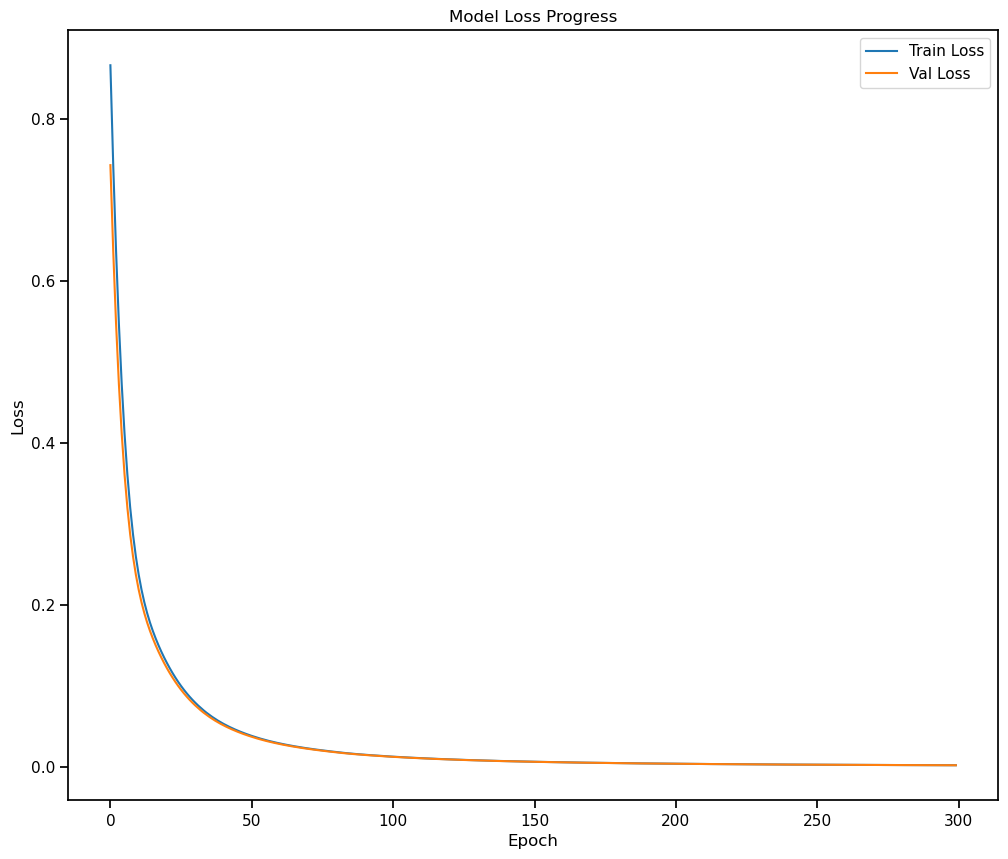

In [369]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Progress')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

### Plan Działania (Roadmapa Modelowania)

Po potwierdzeniu, że "silnik" modelu jest sprawny technicznie, przechodzimy do właściwego cyklu uczenia i optymalizacji. Proces ten podzielono na dwa strategiczne etapy:

1. **Trening na pełnym zbiorze (Redukcja Avoidable Bias):**
   Przetrenowanie modelu na całej dostępnej populacji treningowej. Głównym celem na tym etapie jest upewnienie się, że model potrafi uchwycić zależności w danych i maksymalnie zredukować obciążenie (bias). Aktywnie zarządzamy tu problemem niezbalansowania klas, wykorzystując wyliczone wcześniej wagi (`class_weights`) oraz zmodyfikowany bias początkowy (`initial_bias`).
   
2. **Optymalizacja i Regularyzacja (Zarządzanie Wariancją):**
   Gdy model udowodni, że potrafi uczyć się na pełnych danych, wprowadzona zostanie zaawansowana optymalizacja hiperparametrów za pomocą **Optuna**. Przeszukamy przestrzeń hiperparametrów w poszukiwaniu idealnego poziomu regularyzacji (np. warstwy Dropout, regularyzacji L2, optymalny Learning Rate), aby zredukować wariancję (Variance) i zapobiec przeuczeniu (Overfitting).
   

> **Wniosek:** Skuteczny test na małej próbce to fundament bezpiecznego modelowania. Mamy pewność, że kod działa poprawnie – teraz głównym wyzwaniem staje się zmuszenie architektury do skutecznej generalizacji wiedzy na nowych, niewidzianych wcześniej danych.

### Zestawienie modelu z `initial_bias` oraz bez niego

W tej sekcji przeprowadzamy eksperyment porównawczy, trenując dwie identyczne architektury sieci neuronowej. Jedyną różnicą między nimi jest sposób inicjalizacji wagi (obciążenia) w warstwie wyjściowej:

1. **Model A (Standardowy):** Inicjalizacja losowa (domyślna w Keras).
2. **Model B (Zoptymalizowany):** Inicjalizacja oparta na uprzednio wyliczonym logarytmie szans (`initial_bias`), odpowiadającym naturalnemu rozkładowi klas w zbiorze danych.

Celem tego zestawienia jest wizualizacja i udowodnienie hipotezy, że w przypadku problemów z silnym niezbalansowaniem klas (jak przewidywanie Churnu), podanie modelowi początkowego punktu odniesienia drastycznie poprawia dynamikę wczesnych etapów uczenia.

In [381]:
model_1_no_bias = build_model_1(N_FEATURES)
model_1_with_bias = build_model_1(N_FEATURES, output_bias=initial_bias)

In [391]:
model_1_no_bias = build_model_1(N_FEATURES)
model_1_with_bias = build_model_1(N_FEATURES, output_bias=initial_bias)
model_1_no_bias.predict(X_train_proc[:10])
model_1_with_bias.predict(X_train_proc[:10])
res_no_bias = model_1_no_bias.evaluate(X_train_proc,y_train, batch_size=BATCH_SIZE, verbose=0)
res_init_bias = model_1_with_bias.evaluate(X_train_proc,y_train, batch_size=BATCH_SIZE, verbose=0)
print(f'initial_bias{initial_bias}') 
print("Default init loss: {:0.4f}".format(res_no_bias[0]))
print("Initial bias init loss: {:0.4f}".format(res_init_bias[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
initial_bias[-0.92653904]
Default init loss: 0.8432
Initial bias init loss: 0.6711


### Wyniki Eksperymentu: Wpływ Initial Bias na Start Treningu

Zgodnie z założeniami teoretycznymi, zastosowanie wyliczonego wcześniej obciążenia początkowego (`initial_bias`) przyniosło natychmiastowe, mierzalne efekty już w zerowej epoce (przed rozpoczęciem właściwej optymalizacji).

**Zestawienie wartości początkowej funkcji straty (Loss):**

* **Obliczony Initial Bias:** **-0.9265** (odpowiada logarytmowi szans dla naszego niezbalansowanego zbioru)
* **Strata (Loss) - Inicjalizacja Domyślna:** **0.8432**
* **Strata (Loss) - Inicjalizacja Zoptymalizowana:** **0.6711**



> **Wniosek Analityczny:** Różnica na poziomie blisko **0.17** w początkowej wartości funkcji kosztu to znaczący zysk wydajnościowy. Udowadnia to, że zoptymalizowany model nie musi marnować pierwszych iteracji na trywialne "odkrywanie" faktu, że klasa pozytywna (odejście klienta) występuje rzadziej. Od pierwszego kroku sieć skupia się na właściwym zadaniu: poszukiwaniu głębokich, nieliniowych wzorców zachowań ukrytych w cechach klientów.

## Porównanie modeli

In [393]:
# 0 bias history 
model_1_no_bias = build_model_1(N_FEATURES)

model_1_no_bias.layers[-1].bias.assign([0.0])
zero_bias_history = model_1_no_bias.fit(
    X_train_proc,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=20,
    validation_data=(X_dev_proc, y_dev),
    verbose=0)

In [394]:
model_1_with_bias = build_model_1(N_FEATURES, output_bias=initial_bias)
careful_bias_history = model_1_with_bias.fit(
    X_train_proc,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=20,
    validation_data=(X_dev_proc, y_dev),
    verbose=0)

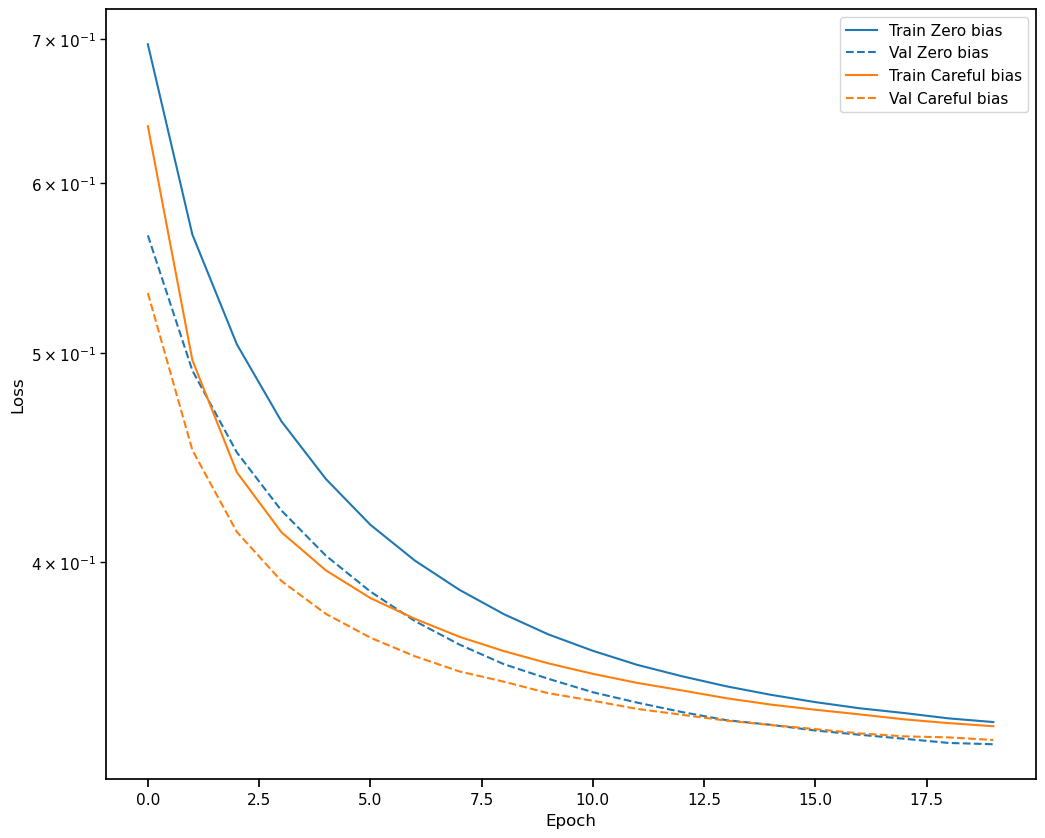

In [396]:
plot_loss(zero_bias_history, 'Zero bias',0)
plot_loss(careful_bias_history, 'Careful bias',1)

### Skala Niezbalansowania a Szybkość Konwergencji

Warto uczciwie odnotować kontekst tego eksperymentu. W analizowanym zbiorze danych telekomunikacyjnych nierównowaga klas jest zauważalna, jednak nie ma charakteru skrajnego, rozkład wynosi w przybliżeniu **74% (klienci pozostający) do 26% (klienci odchodzący)**. 

Z tego powodu ostateczna różnica w wynikach pomiędzy modelem wykorzystującym `initial_bias`, a modelem ze standardową inicjalizacją losową nie jest drastyczna (w przeciwieństwie do np. problemów detekcji anomalii finansowych, gdzie rozkład często wynosi 99:1). Niemniej jednak, analiza wykresów krzywych uczenia  prowadzi do bezspornego wniosku inżynieryjnego:

* **Przyspieszenie treningu:** Model ze wstępnie skalibrowanym obciążeniem szybciej stabilizuje wagi i osiąga optymalny poziom funkcji kosztu w mniejszej liczbie epok. 
* **Łagodniejszy gradient:** Krzywa uczenia od samego startu wykazuje bardziej przewidywalny i płynny spadek, omijając etap początkowego "chaosu".



> **Wniosek Optymalizacyjny:** Nawet przy umiarkowanym niezbalansowaniu klas (74:26), zastosowanie inicjalizacji opartej na logarytmie szans pozostaje żelazną dobrą praktyką. Wdrożenie tej techniki gwarantuje szybszą zbieżność algorytmu. W środowisku produkcyjnym, podczas trenowania dużych architektur na ogromnych zbiorach danych, bezpośrednio przekłada się to na redukcję kosztów obliczeniowych (np. zużycia instancji GPU w chmurze).

## Etap I: Redukcja "Avoidable Bias" (Minimalizacja Obciążenia)

W pierwszej fazie trenowania docelowego rozwiązania predykcyjnego podjęto świadomą decyzję o **tymczasowym zaniechaniu agresywnych metod balansowania klas** (takich jak techniki oversamplingu czy operowanie na wagach klas `class_weights`). Na tym etapie jedyną interwencją pozostaje zaimplementowany i przetestowany wcześniej `initial_bias`, który zapewnia optymalny start algorytmu.

Dlaczego przyjmujemy taką strategię? Naszym absolutnym priorytetem w tym kroku jest zredukowanie tzw. **Avoidable Bias** (obciążenia możliwego do uniknięcia). W terminologii inżynierii Machine Learningu oznacza to konieczność udowodnienia, że zaprojektowana architektura sieci neuronowej posiada wystarczającą pojemność informacyjną (model capacity), aby poprawnie uchwycić strukturę i nieliniowe zależności w zbiorze treningowym. Mówiąc wprost: najpierw musimy upewnić się, że model nie cierpi na problem niedopasowania (*Underfitting*).



### Kolejność działań optymalizacyjnych:

1. **Maksymalne dopasowanie (Obecny krok):** Zmuszenie modelu do jak najdokładniejszego odwzorowania zbioru treningowego (nawet jeśli miałoby to prowadzić do początkowego przeuczenia).
2. **Generalizacja i Wariancja (Kolejne kroki):** Po upewnieniu się, że model posiada odpowiednią siłę predykcyjną, wprowadzimy mechanizmy regularyzacyjne (np. przeszukiwanie hiperparametrów Optuną, warstwy Dropout, Early Stopping). Ich celem będzie redukcja wariancji, czyli nauczenie modelu wyciągania uniwersalnych wzorców, które zadziałają na nowych, nieznanych danych walidacyjnych.

> **Strategia Inżynieryjna:** Skuteczny proces trenowania sieci głębokich to gra w przeciąganie liny między obciążeniem a wariancją. Zawsze zaczynamy od zbudowania modelu na tyle silnego, by poradził sobie z danymi treningowymi, a dopiero potem nakładamy na niego matematyczne "kagańce" zapobiegające zapamiętywaniu szumu.

In [ ]:
baseline_model_1 = build_model_1(N_FEATURES, output_bias=initial_bias)
baseline_history = baseline_model_1.fit(
    X_train_proc, 
    y_train,
    batch_size = BATCH_SIZE, 
    epochs = EPOCHS,
    callbacks =[early_stopping(50)],
    validation_data = (X_dev_proc, y_dev)
)

## Więcej z tego nie wycisnę bez zajęcia się nierównością klas 

Brier score :  0.09962
accuracy :  0.8583
auc :  0.92242
cross entropy :  0.31752
f1_score :  0.7417
fn :  79.0
fp :  61.0
loss :  0.31752
prc :  0.83582
precision :  0.76718
recall :  0.71786
tn :  647.0
tp :  201.0
True Negatives:  647
False Positives:  61
False Negatives:  79
True Positives:  201
Total Customers that churned:  280
True Negatives:  3401
False Positives:  375
False Negatives:  373
True Positives:  1122
Total Customers that churned:  1495


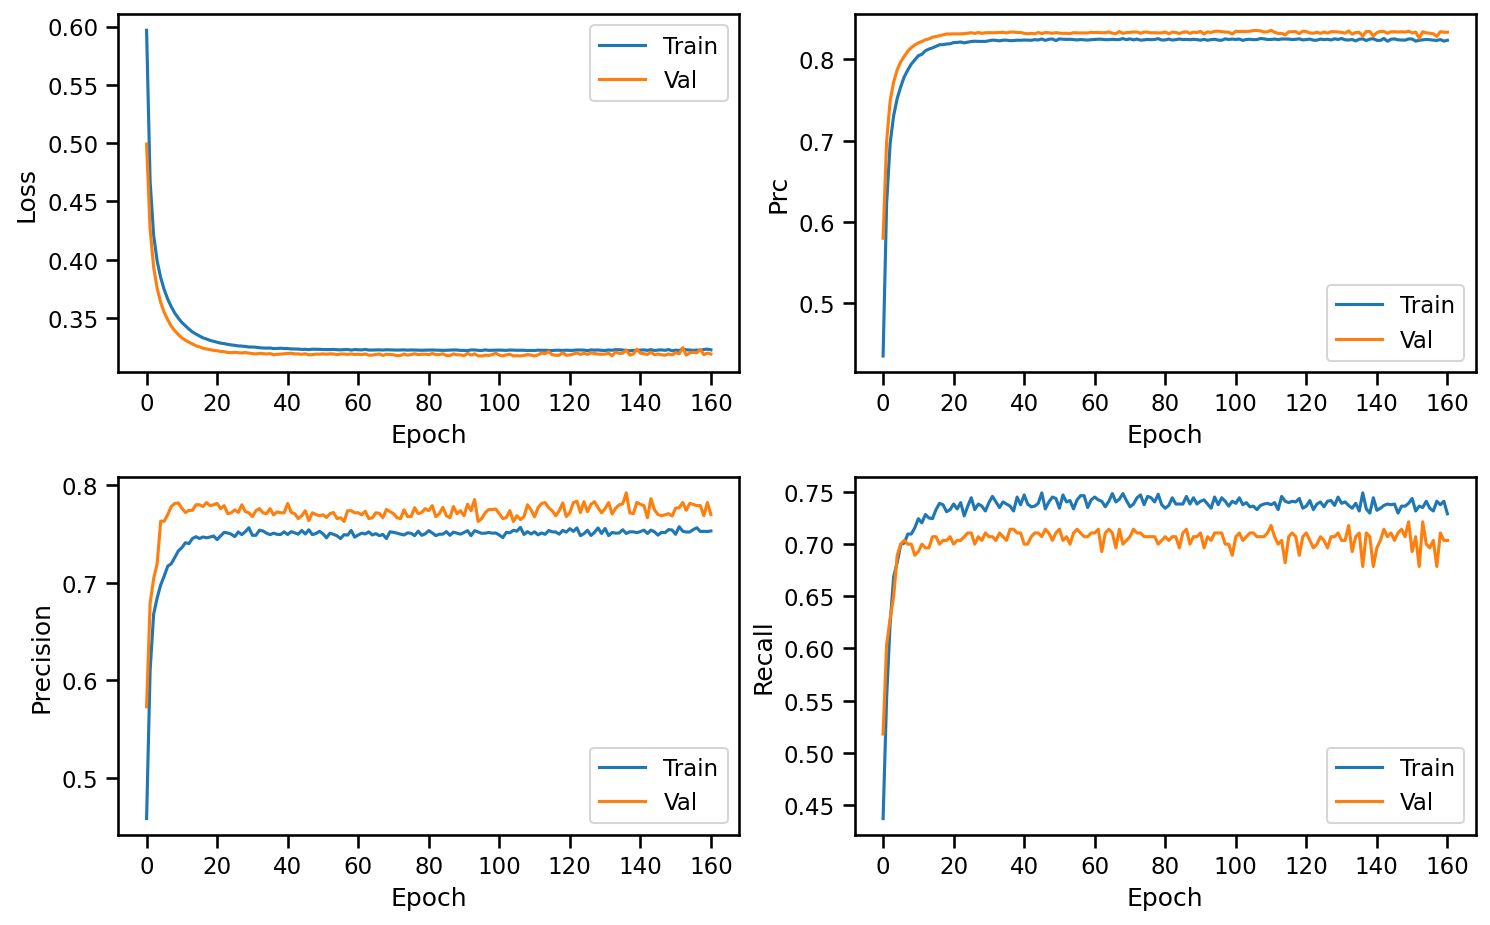

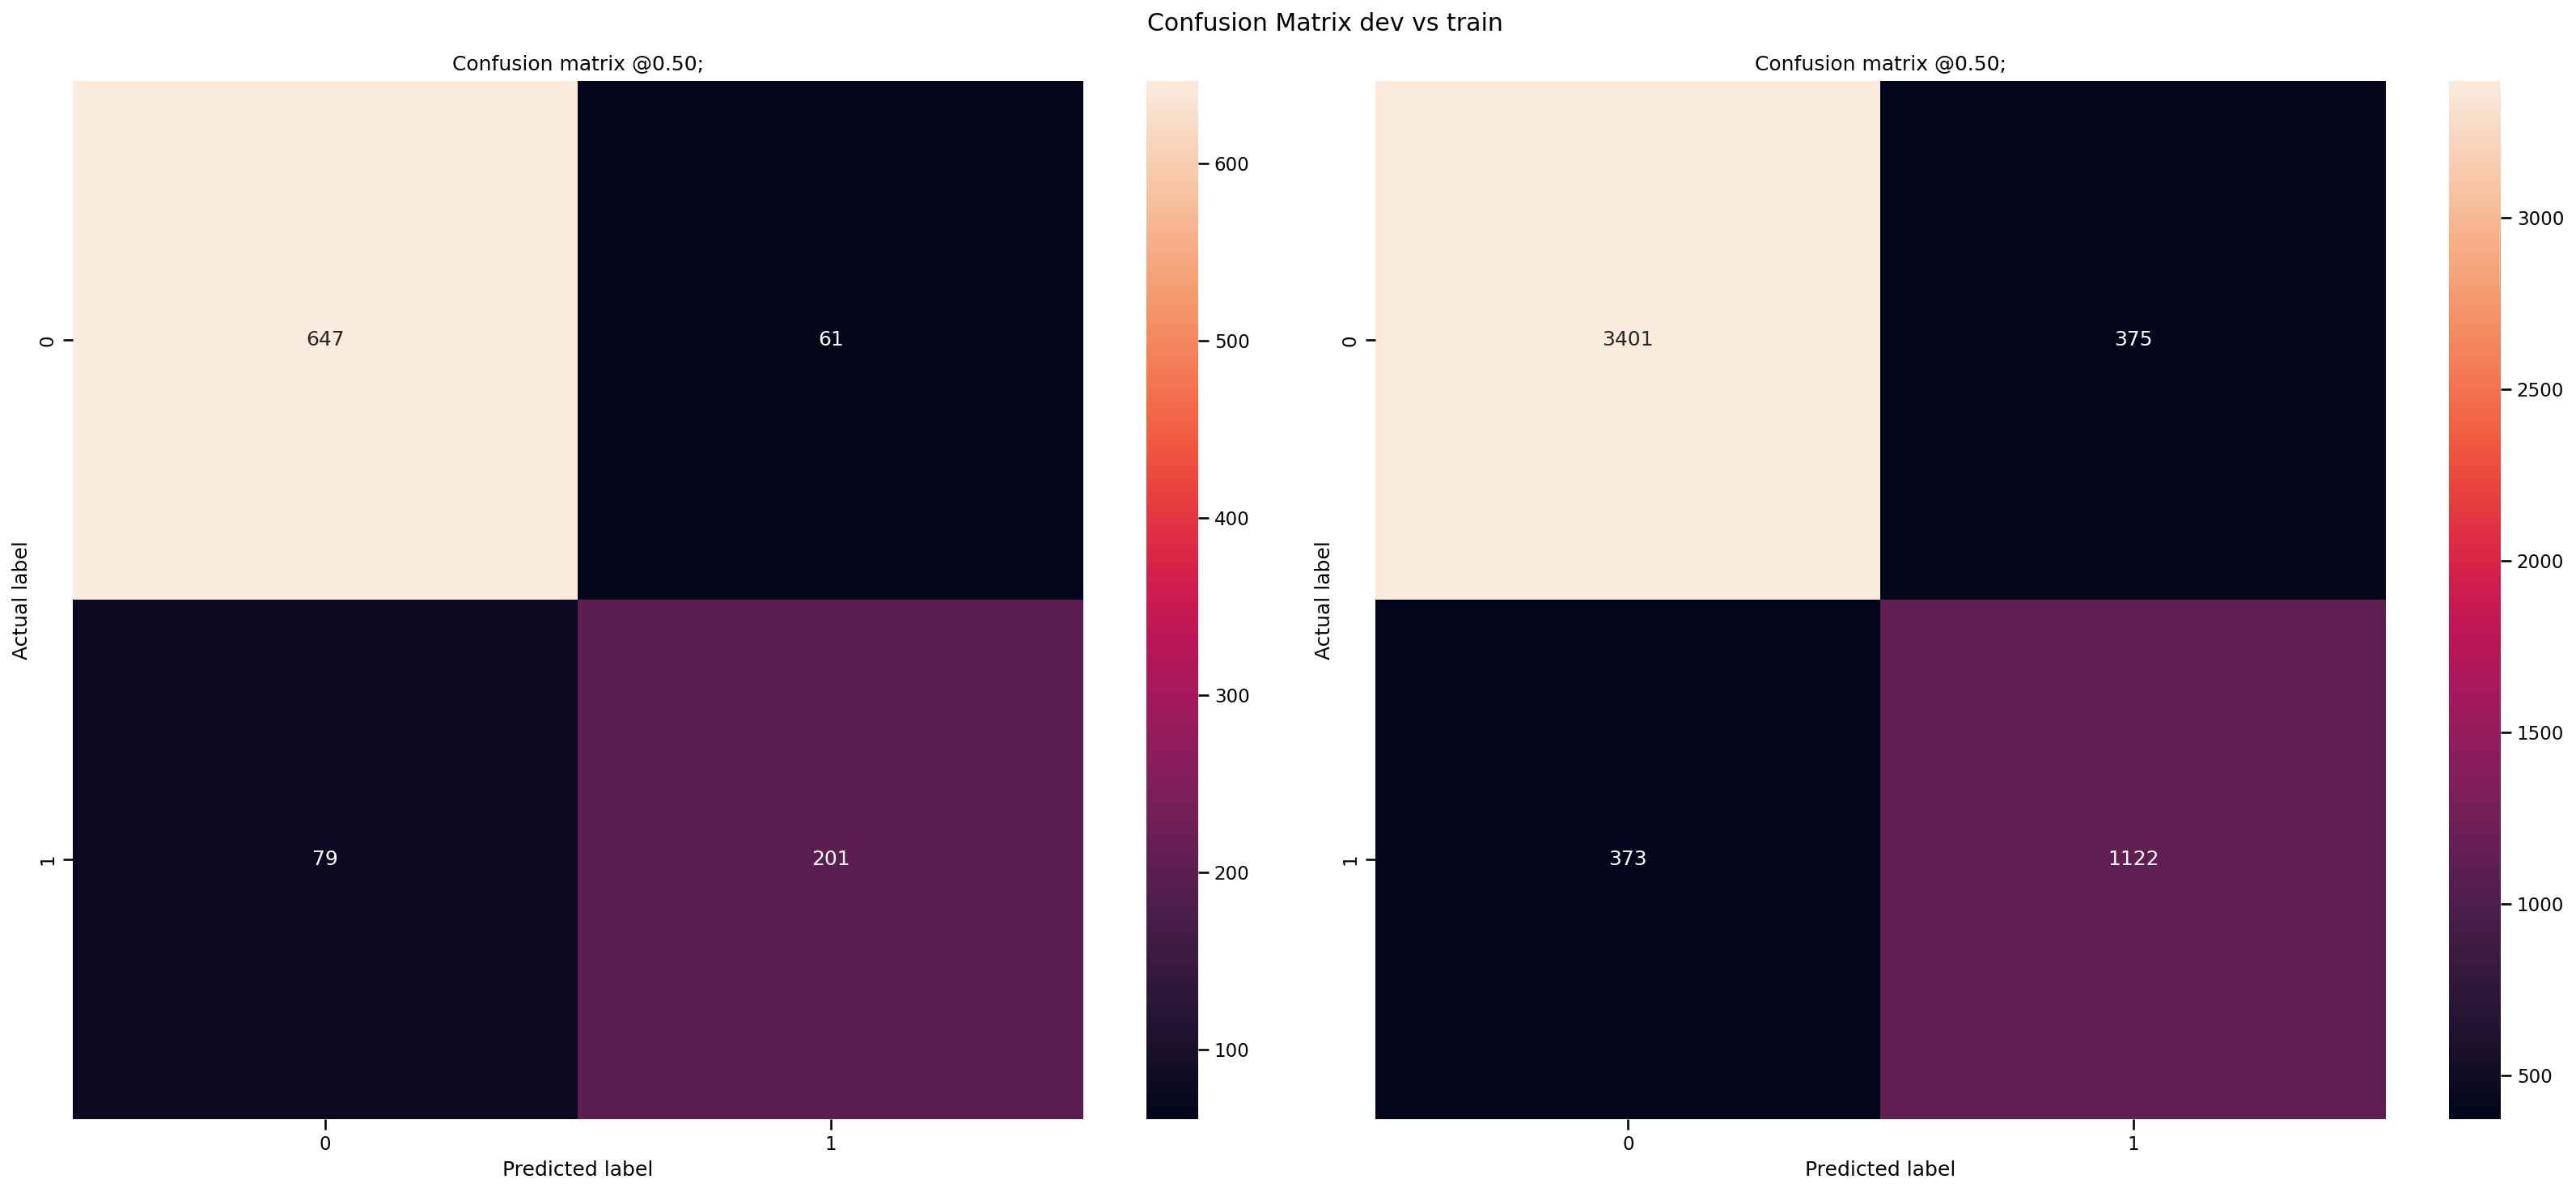

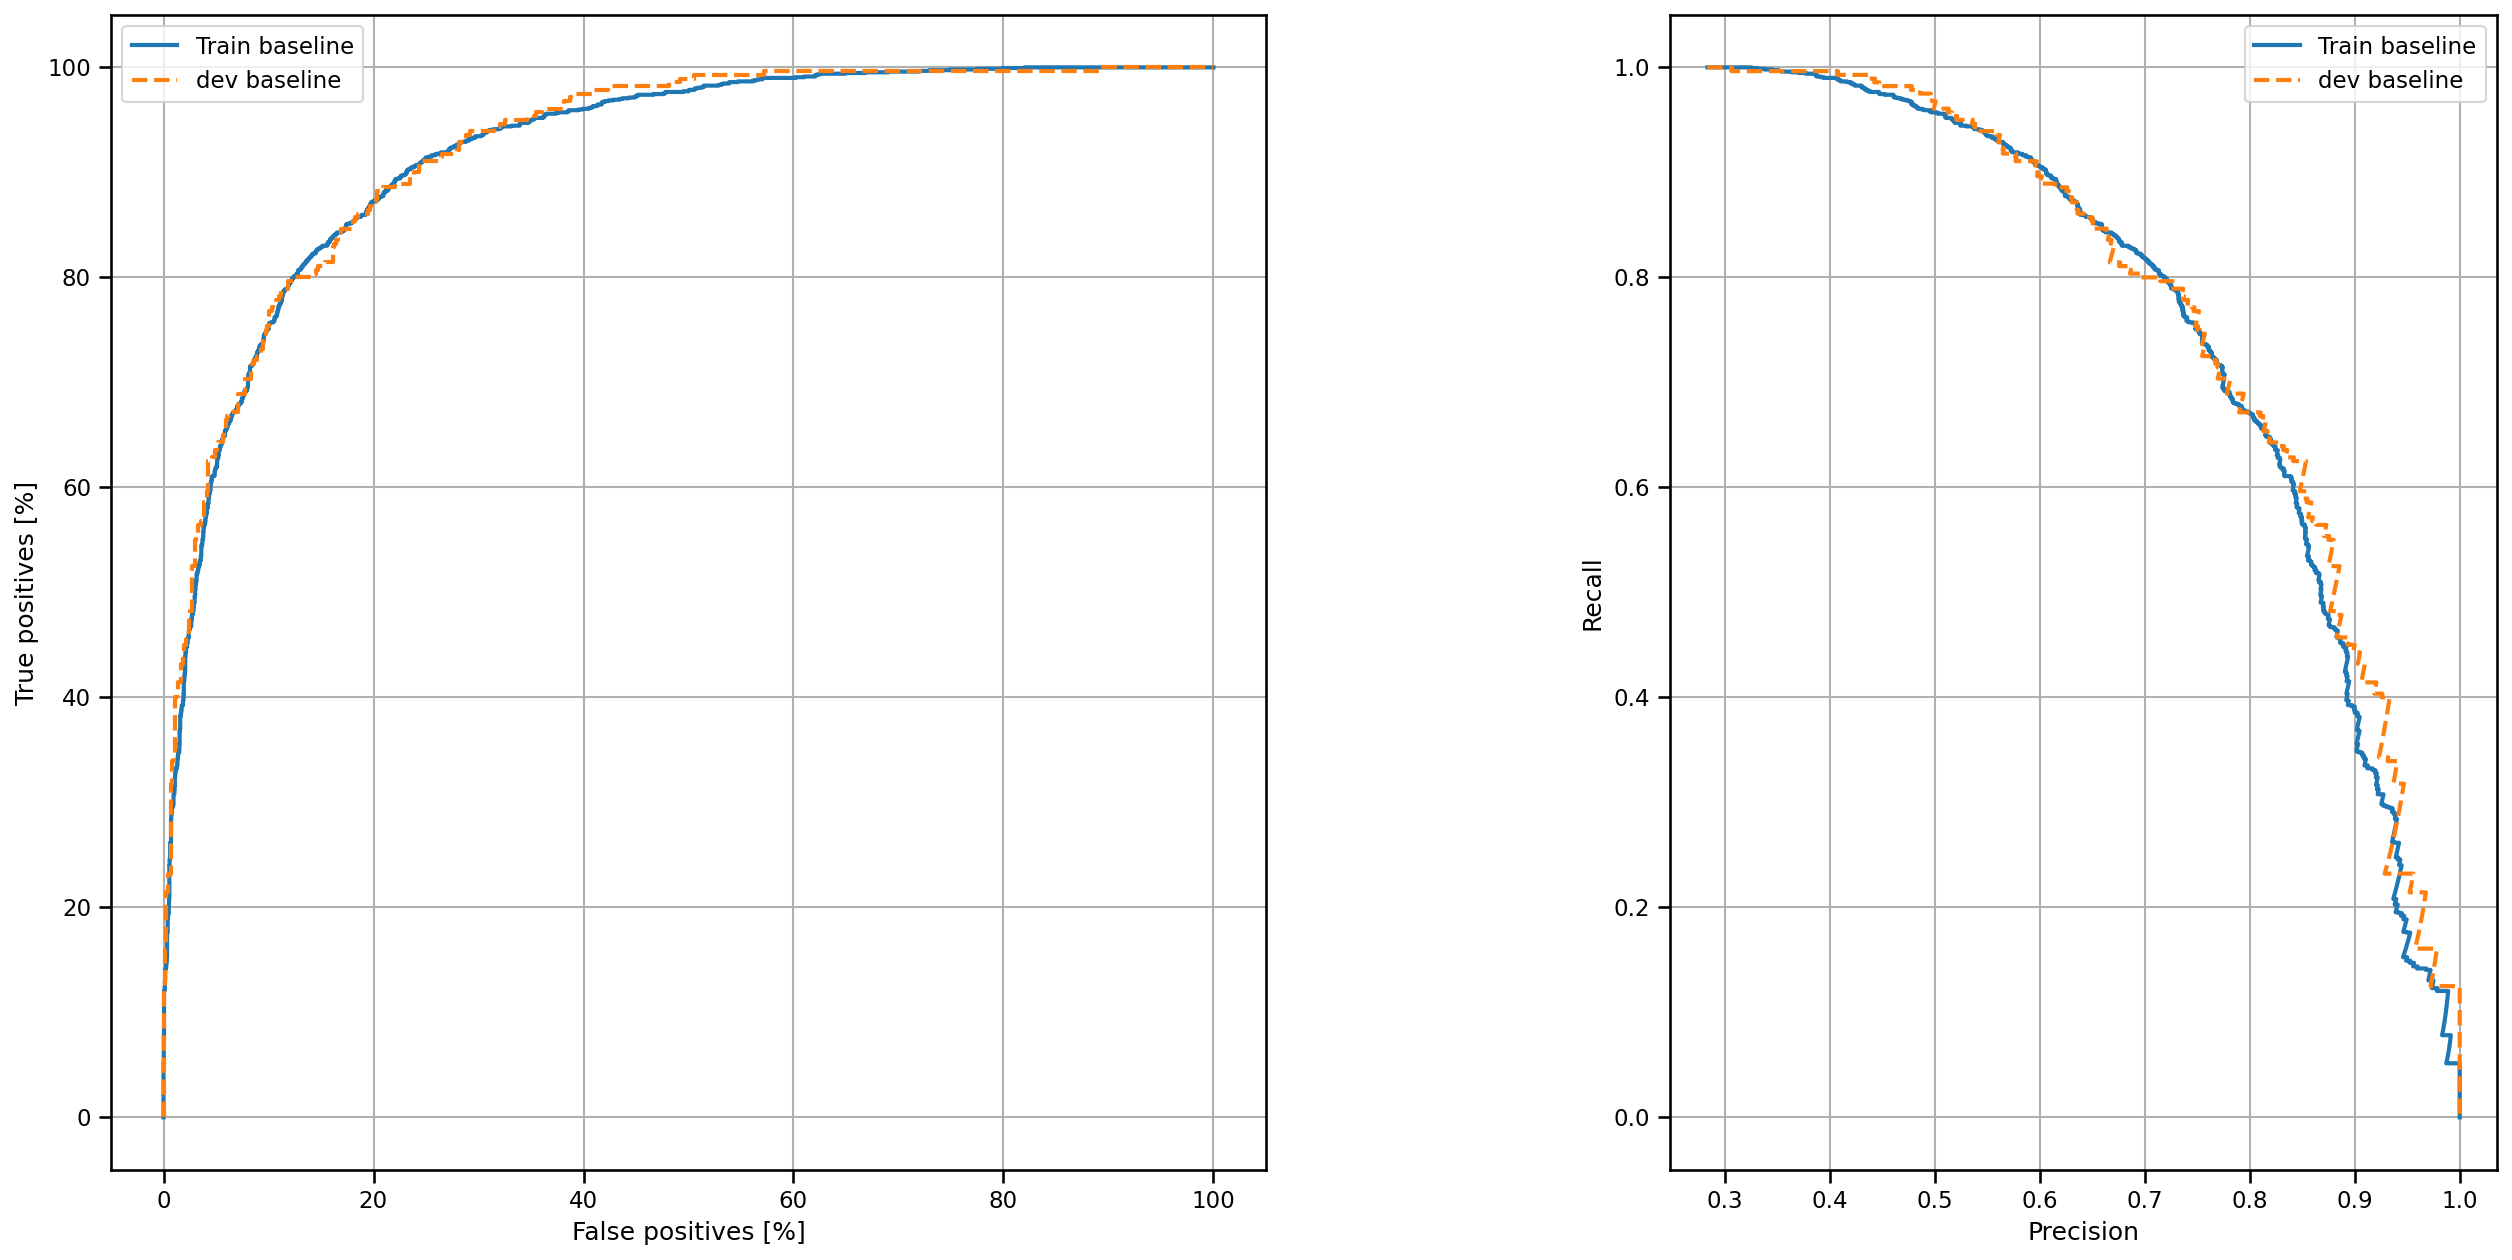

In [493]:
sns.set_context('notebook')
train_predictions_baseline , test_predictions_baseline = get_model_summary(baseline_model_1
                                                                           ,baseline_history
                                                                           ,(X_train_proc, y_train, X_dev_proc, y_dev,)
                                                                           ,b_size=32)

### Analiza Wyników Bazowych: Diagnoza Niedopasowania (Underfitting)

Z analizy wygenerowanych krzywych uczenia wyłania się niezwykle interesujący, klasyczny przypadek **niedopasowania (Underfitting)**. 

Sieci neuronowe, ze względu na swoją ogromną pojemność informacyjną, zazwyczaj wykazują silną tendencję do przeuczania (Overfitting) i szybkiego "zapamiętywania" zbioru treningowego. W tym przypadku obserwujemy jednak zjawisko odwrotne:
* Krzywe błędu (Loss) oraz metryk dla zbioru treningowego i walidacyjnego (Test/Val) pokrywają się niemal idealnie.
* Finalny *performance* modelu na obu zbiorach jest praktycznie taki sam.

Oznacza to, że obecna architektura nie wyczerpała jeszcze swojego potencjału uczenia się i zatrzymała się na wychwytywaniu jedynie bardzo ogólnych wzorców. 

#### Silny Sygnał Predykcyjny (AUC = 0.92)

Pomimo zdiagnozowanego underfittingu, model osiągnął imponujący wynik **ROC AUC = 0.92 na zbiorze walidacyjnym!** Jest to kluczowy sygnał na tak wczesnym etapie modelowania. Dowodzi on, że nawet przy zachowawczym dopasowaniu, algorytm z dużą pewnością potrafi separować klasę klientów odchodzących od pozostających. Tak wysoki wynik "na starcie" to bezpośrednia zasługa rygorystycznego procesu czyszczenia danych i inżynierii cech, który dostarczył sieci bardzo czysty sygnał informacyjny.

#### Kolejne Kroki Optymalizacyjne

Mając pewność, że dane są wysokiej jakości, naszym zadaniem jest teraz "zmuszenie" sieci do głębszej eksploracji zbioru treningowego. 

W pierwszej kolejności wprowadzimy mechanizm **ważenia klas (Class Weights)**. Zwiększając proporcjonalnie "karę" za błędy na klasie mniejszościowej (klienci odchodzący), sprawdzimy, czy sztuczne podniesienie wagi tych obserwacji przełamie obecny stan underfittingu i pozwoli modelowi na bardziej precyzyjne dopasowanie się do trudniejszych do wychwycenia zależności.

> **Wniosek Inżynieryjny:** Bardzo zbliżone do siebie wyniki na zbiorze treningowym i testowym przy jednoczesnym bardzo wysokim AUC to doskonała pozycja startowa.

Przesunięcie granicy naturalnie poprawia skuteczność predykcji odejść natomiast znacząco zwiększa liczbę błędnie sklasyfikowanych 0

## Strategia Ważenia Klas (Cost-Sensitive Learning)

Mając zdiagnozowany problem niedopasowania (Underfitting) i łagodnego niezbalansowania klas, wprowadzamy do procesu treningowego mechanizm **ważenia klas (Class Weights)**. 

**Główny cel biznesowy i optymalizacyjny:** Chcemy wymusić na sieci neuronowej zwrócenie szczególnej uwagi na obserwacje z klasy mniejszościowej (klienci odchodzący, `Churn = 1`). Z matematycznego punktu widzenia, sztucznie podnosimy "koszt" (karę) za przeoczenie klienta odchodzącego (błąd typu False Negative). Ponieważ optymalizator dąży do minimalizacji globalnej kary, model będzie zmuszony do większej precyzji w identyfikacji tej trudniejszej grupy, nawet kosztem niewielkiego spadku ogólnej dokładności (Accuracy) na klasie dominującej.



### Ważna Uwaga Metodologiczna
Przy wprowadzaniu tej techniki należy zachować szczególną ostrożność podczas interpretacji krzywych uczenia. **Całkowita wartość funkcji straty (Total Loss) staje się absolutnie nieporównywalna pomiędzy modelem bazowym (Baseline) a modelem ważonym.**

Wynika to ze zmiany samej mechaniki agregacji błędu. W modelu bazowym funkcja kosztu minimalizuje standardową średnią błędów. Po dodaniu wag, optymalizator zaczyna wyliczać **średnią ważoną**. Pojedyncze błędy są teraz skalowane przez przypisane im mnożniki:

* Błąd na klasie większościowej (`Churn = 0`): 
  $$Loss_0 = W_0 \cdot \text{Error}$$
* Błąd na klasie mniejszościowej (`Churn = 1`): 
  $$Loss_1 = W_1 \cdot \text{Error}$$

Ponieważ w tym przypadku waga dla klasy mniejszościowej jest znacznie wyższa ($W_1 > W_0$), każda pomyłka na kliencie odchodzącym generuje proporcjonalnie większy gradient, zmuszając sieć do drastyczniejszej korekty wag w architekturze. 

> **Wniosek Analityczny:** Do porównywania obu modeli nie możemy już używać surowej wartości parametru `loss`. Głównym kryterium ewaluacji stają się teraz metryki odporne na manipulację progiem i niezbalansowanie, takie jak **ROC AUC**, **Precision-Recall AUC** oraz **F1-Score**.

In [84]:
print('Weight for class 0: {:.2f}'.format(class_weight[0]))
print('Weight for class 1: {:.2f}'.format(class_weight[1]))

Weight for class 0: 0.70
Weight for class 1: 1.76


In [ ]:
weighted_model_1 = build_model_1(N_FEATURES, output_bias=initial_bias)
weighted_1_history = weighted_model_1.fit(
    X_train_proc, 
    y_train,
    batch_size = BATCH_SIZE, 
    epochs = EPOCHS,
    callbacks =[early_stopping(50)],
    validation_data = (X_dev_proc, y_dev),
    class_weight = class_weight
)

In [ ]:
weighted_model_baseline = build_model_1(N_FEATURES, output_bias=initial_bias)

weighted_model_baseline_history = weighted_model_baseline.fit(
    X_train_proc,
    y_train,
    batch_size = BATCH_SIZE,
    epochs = EPOCHS, 
    callbacks = [early_stopping(10),],
    validation_data = (X_dev_proc, y_dev),
    class_weight = class_weight
)

Brier score :  0.11764
accuracy :  0.82389
auc :  0.91954
cross entropy :  0.36181
f1_score :  0.73795
fn :  35.0
fp :  139.0
loss :  0.36181
prc :  0.82922
precision :  0.63802
recall :  0.875
tn :  569.0
tp :  245.0
True Negatives:  569
False Positives:  139
False Negatives:  35
True Positives:  245
Total Customers that churned:  280
True Negatives:  3014
False Positives:  762
False Negatives:  188
True Positives:  1307
Total Customers that churned:  1495


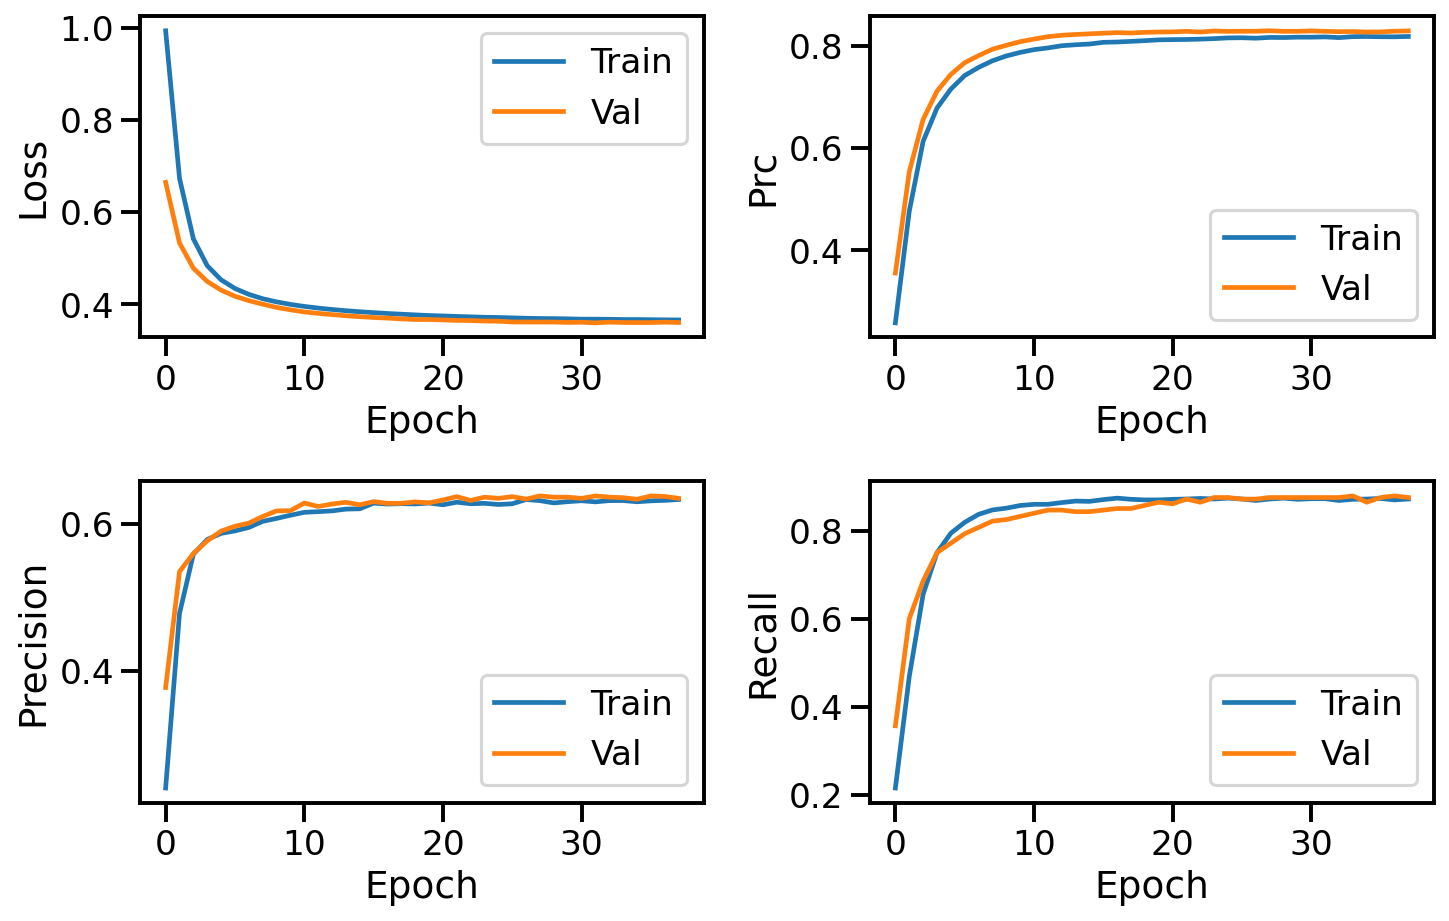

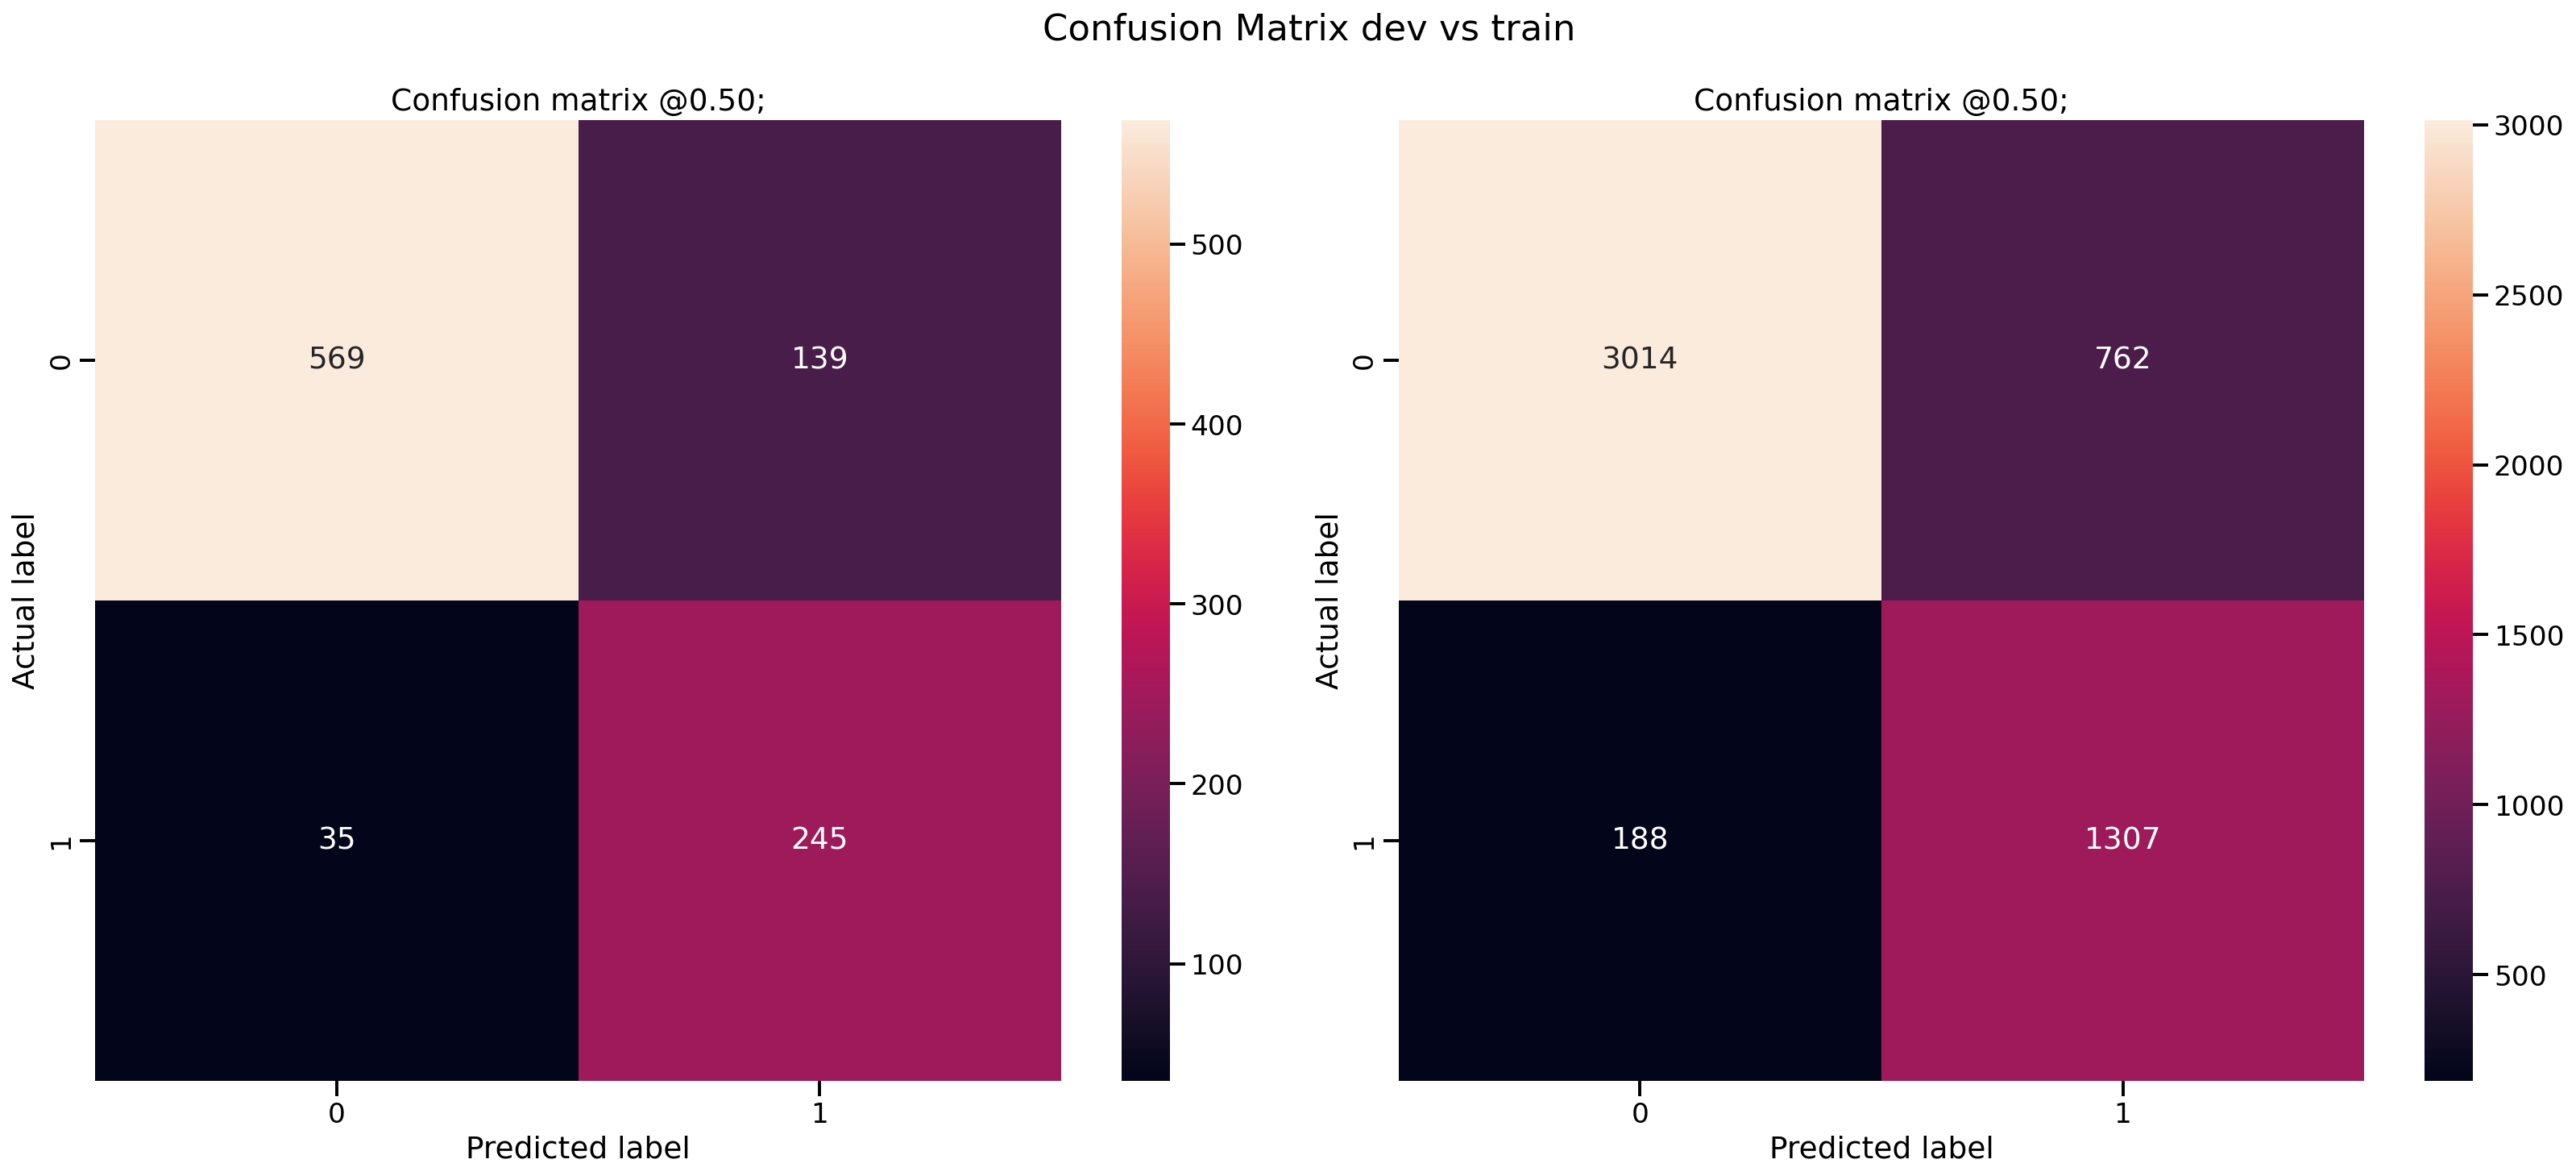

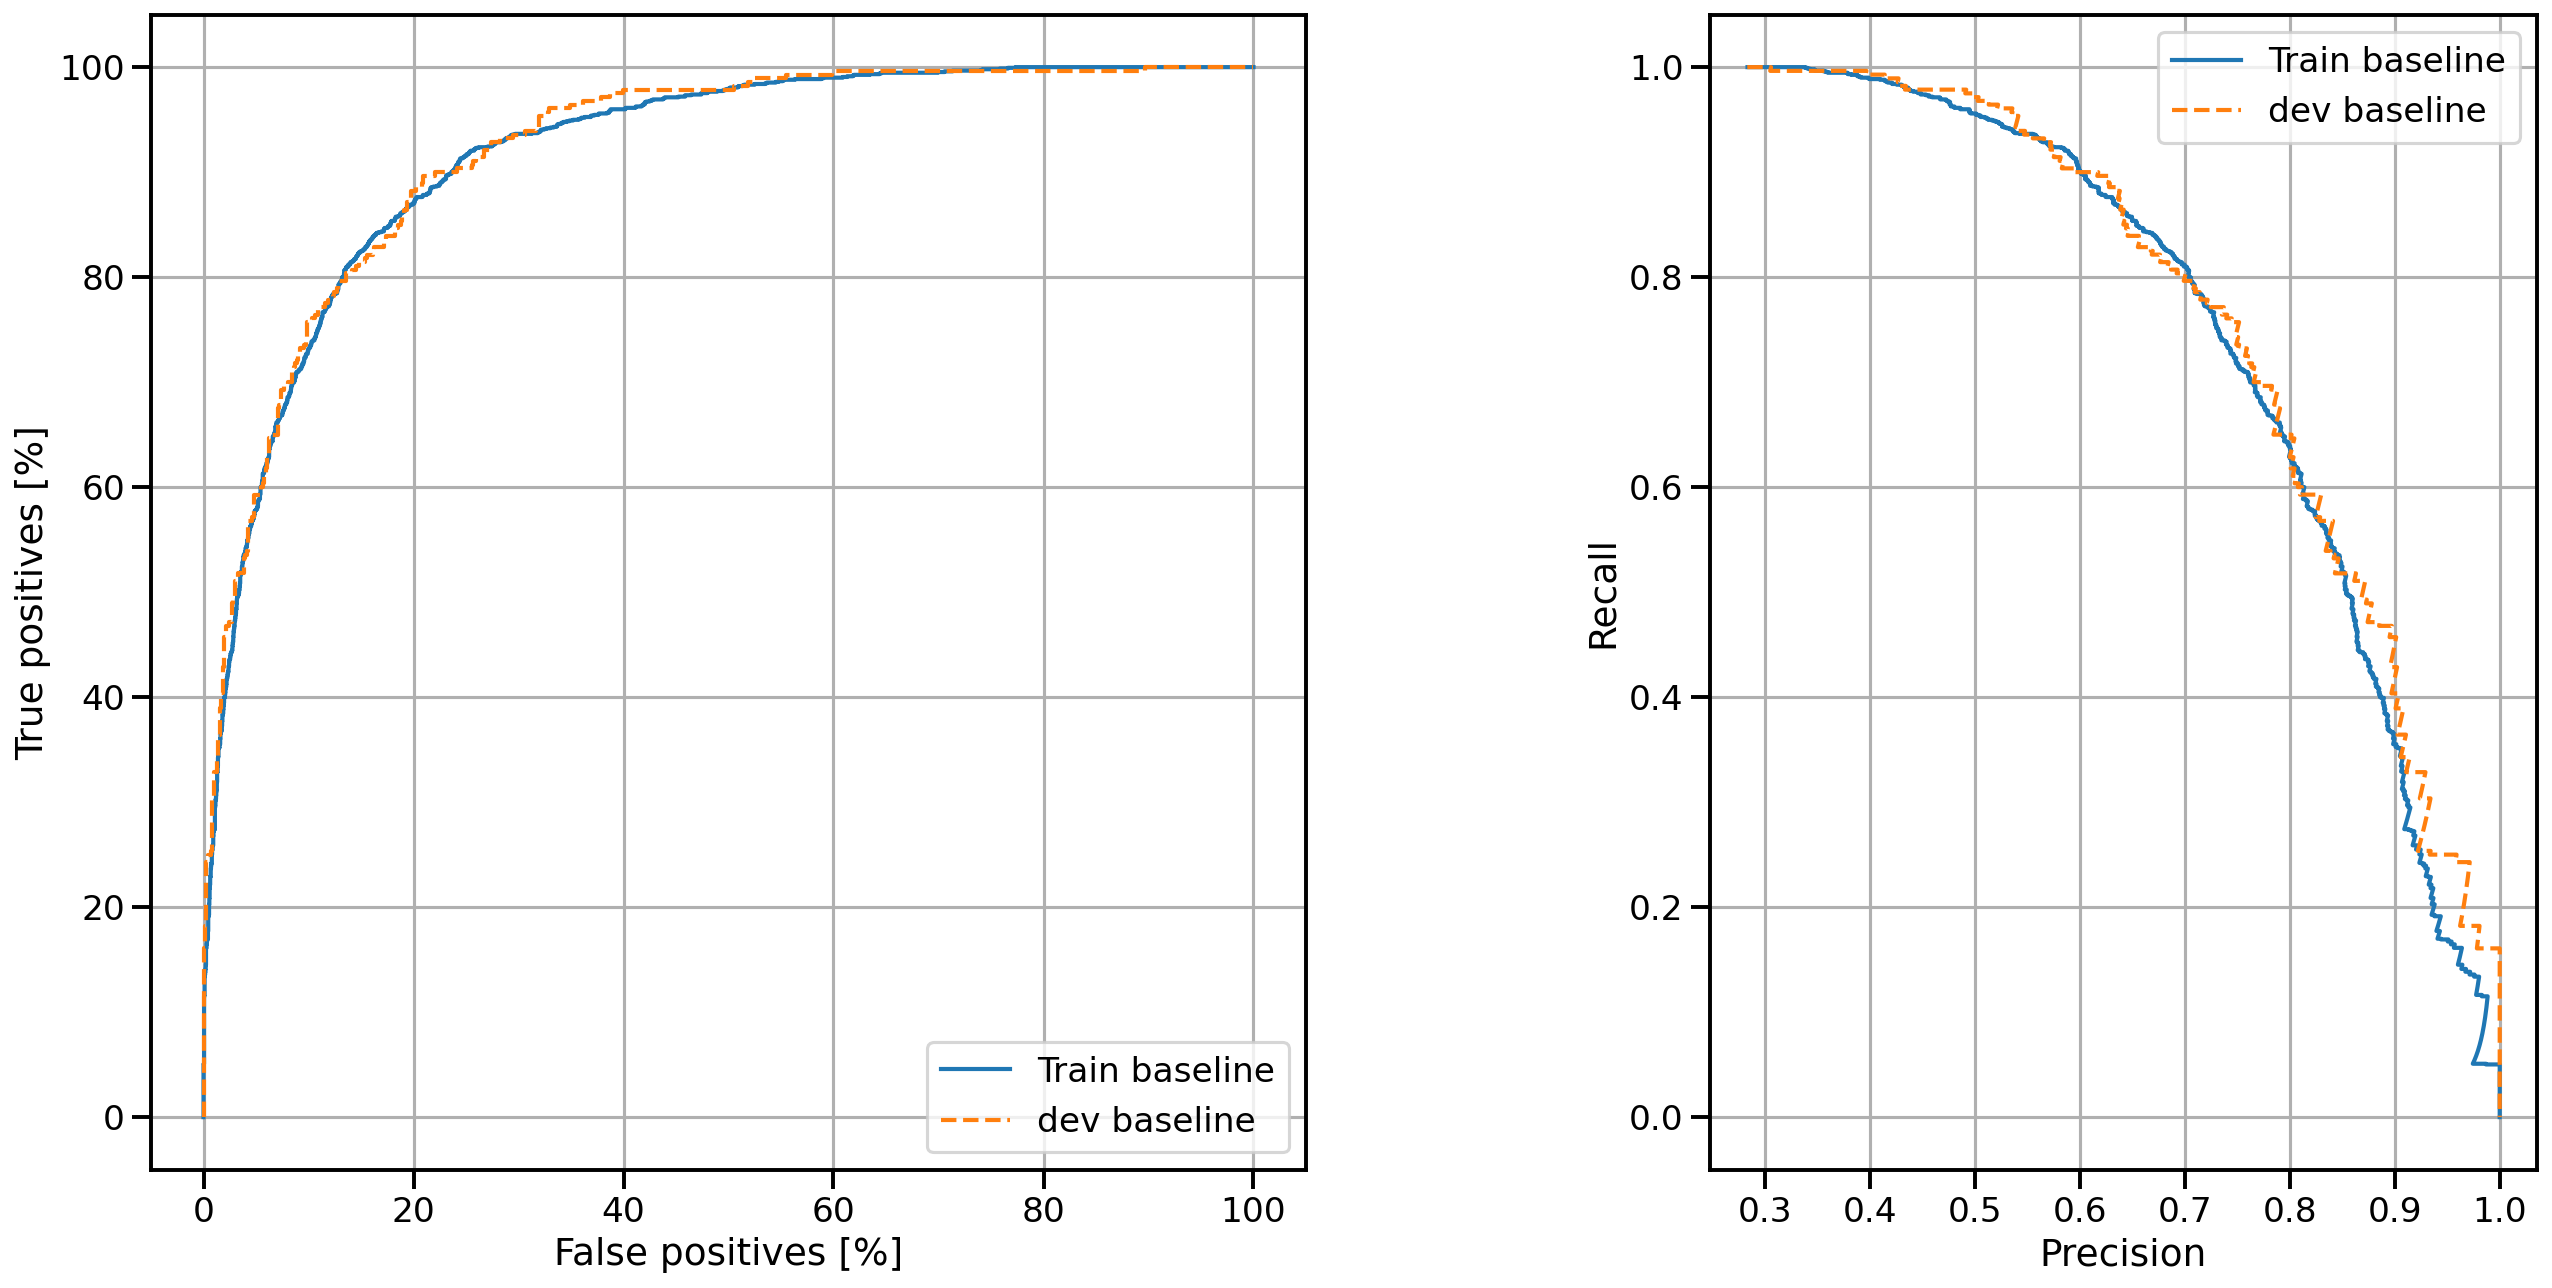

In [516]:
train_weighted_predictions_baseline , test_weighted_predictions_baseline = get_model_summary(weighted_model_baseline
                                                                           ,weighted_model_baseline_history
                                                                           ,(X_train_proc, y_train, X_dev_proc, y_dev,)
                                                                           ,b_size=BATCH_SIZE)

###  Wyniki po Ważeniu Klas: Trade-off i Problem Pojemności

Zgodnie z teoretycznymi przewidywaniami, implementacja wag klas przyniosła natychmiastowy i wyraźny efekt na płaszczyźnie decyzyjnej modelu, uwidaczniając klasyczny **Precision-Recall Trade-off**:

* **Sukces (Wzrost Recall):** Model stał się znacznie bardziej wyczulony na klasę mniejszościową. Zdecydowanie lepiej radzi sobie z identyfikacją klientów, którzy faktycznie rezygnują z usług. Z perspektywy biznesowej to pożądany efekt – minimalizujemy ryzyko "przegapienia" klienta, którego można by było utrzymać odpowiednią ofertą.
* **Koszt (Wzrost False Positives):** Skutkiem ubocznym tej agresywniejszej strategii jest wzrost liczby błędnie sklasyfikowanych klientów lojalnych (False Positives). Algorytm woli "dmuchać na zimne", przez co częściej podnosi fałszywy alarm.

####  Diagnoza Underfittingu i Specyfika Danych Tabelarycznych

Pomimo poprawy w identyfikacji klasy pozytywnej, sieć nadal wykazuje uparte objawy **Underfitting-u**. Zjawisko to było jednak wkalkulowane w ryzyko projektowe z dwóch głównych powodów:
1. **Rozmiar zbioru:** Architektury Głębokiego Uczenia (Deep Learning) są ekstremalnie "głodne danych" . Nasz zbiór treningowy, liczący około 6500 obserwacji, stanowi dla nich zaledwie drobną próbkę.
2. **Natura danych:** Złotą zasadą współczesnego Data Science jest to, że standardowe wielowarstwowe perceptrony (MLP) często przegrywają z algorytmami opartymi na drzewach decyzyjnych (np. **Gradient Boosting**, XGBoost, LightGBM) w przypadku ustrukturyzowanych danych tabelarycznych.

####  Plan Awaryjny (Zwiększenie Złożoności)

Zanim podejmiemy ostateczną decyzję o zmianie paradygmatu modelowania i przejściu na algorytmy ensemble, przeprowadzimy eksperyment weryfikujący potencjał samego zbioru danych. 

> **Wniosek Inżynieryjny i Kolejny Krok:** Obecna architektura może posiadać zbyt małą pojemność informacyjną. W następnym kroku sztucznie "pompujemy" architekturę, budując testowo relatywnie dużą i głęboką sieć (dodanie warstw i neuronów). Jeśli nawet tak złożony model nie zdoła "wgryźć" się w dane treningowe (pokonać underfittingu), zyskamy twardy dowód, że więcej z tego modelu już nie wyciśniemy.

## Nowy Baseline: Rozbudowa Architektury i Zwiększenie Pojemności

W odpowiedzi na zdiagnozowany problem niedopasowania (Underfitting) oraz ograniczenia poprzedniej sieci, definiujemy nową, znacznie potężniejszą architekturę (Model 2). 

Celem tego kroku jest radykalne zwiększenie pojemności informacyjnej modelu poprzez dodanie kolejnych warstw ukrytych i modyfikację mechaniki przepływu sygnału. Chcemy sprawdzić, czy głębsza sieć będzie w stanie ostatecznie wyekstrahować ukryte, nieliniowe zależności z naszych danych tabelarycznych.

```python
def build_model_2(input_shape, units, learning_rate=0.0001, output_bias=None):
    """
    Tworzy rozbudowany model (nowy baseline) z zaawansowanymi technikami optymalizacji.
    
    Parametry:
    - units (tuple/list): Zestaw 3 wartości określających szerokość kolejnych warstw ukrytych.
    """
    # 1. Inicjalizacja wag dopasowana do funkcji ReLU/LeakyReLU
    he_init = tf.keras.initializers.HeNormal()
    
    # Rozpakowanie liczby neuronów dla 3 warstw ukrytych
    un_1, un_2, un_3 = units
    
    # 2. Zarządzanie Initial Bias
    if output_bias is not None:
        output_bias_init = tf.keras.initializers.Constant(output_bias)
    else:
        output_bias_init = "zeros"

    model = Sequential()
    model.add(Input(shape=(input_shape,)))
    
    # Warstwa ukryta 1
    model.add(Dense(units=un_1, kernel_initializer=he_init))
    model.add(LeakyReLU(negative_slope=0.01)) # Zapobieganie "Dead Neurons"
 
    # Warstwa ukryta 2 (Utrzymanie szerokości)
    model.add(Dense(units=un_2, kernel_initializer=he_init)) 
    model.add(LeakyReLU(negative_slope=0.01))

    # Warstwa ukryta 3
    model.add(Dense(units=un_3, kernel_initializer=he_init))
    model.add(LeakyReLU(negative_slope=0.01))
    
    # Warstwa wyjściowa
    model.add(Dense(units=1, 
                    activation='sigmoid',
                    bias_initializer=output_bias_init))
    
    # 3. Kompilacja z Gradient Clipping
    model.compile(
        optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=get_metrics()
    )
    return model

In [ ]:
new_baseline_model = build_model_2(N_FEATURES,units=[256,256,128], learning_rate=0.001, output_bias=initial_bias)
new_baseline_model.summary()
new_baseline_sc_history= new_baseline_model.fit(overfit_batch,
                                  y_overfit, 
                                  batch_size = 32,
                                  epochs = 100, 
                                  callbacks = [early_stopping(20),
                                               lr_decay],
                                  validation_data = (X_dev_ov, y_dev_ov),
                                  class_weight = class_weight
                                  )

Model: "sequential_99"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_333 (Dense)               │ (None, 256)            │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_94 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_334 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_95 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_335 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_96 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_336 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

#### Nowy baseline przeszedł sanity check

In [ ]:
new_baseline_model = build_model_2(N_FEATURES,units=[512,256,128], learning_rate=0.001, output_bias=initial_bias)

new_baseline_history = new_baseline_model.fit(X_train_proc,
                                  y_train, 
                                  batch_size = 64,
                                  epochs = 200, 
                                  callbacks = [early_stopping(30),
                                               lr_decay],
                                  validation_data = (X_dev_proc, y_dev),
                                  class_weight = class_weight
                                  )

Brier score :  0.1042
accuracy :  0.84514
auc :  0.91925
cross entropy :  0.33209
f1_score :  0.74372
fn :  58.0
fp :  95.0
loss :  0.33209
prc :  0.81816
precision :  0.70032
recall :  0.79286
tn :  613.0
tp :  222.0
True Negatives:  613
False Positives:  95
False Negatives:  58
True Positives:  222
Total Customers that churned:  280
True Negatives:  3311
False Positives:  465
False Negatives:  180
True Positives:  1315
Total Customers that churned:  1495


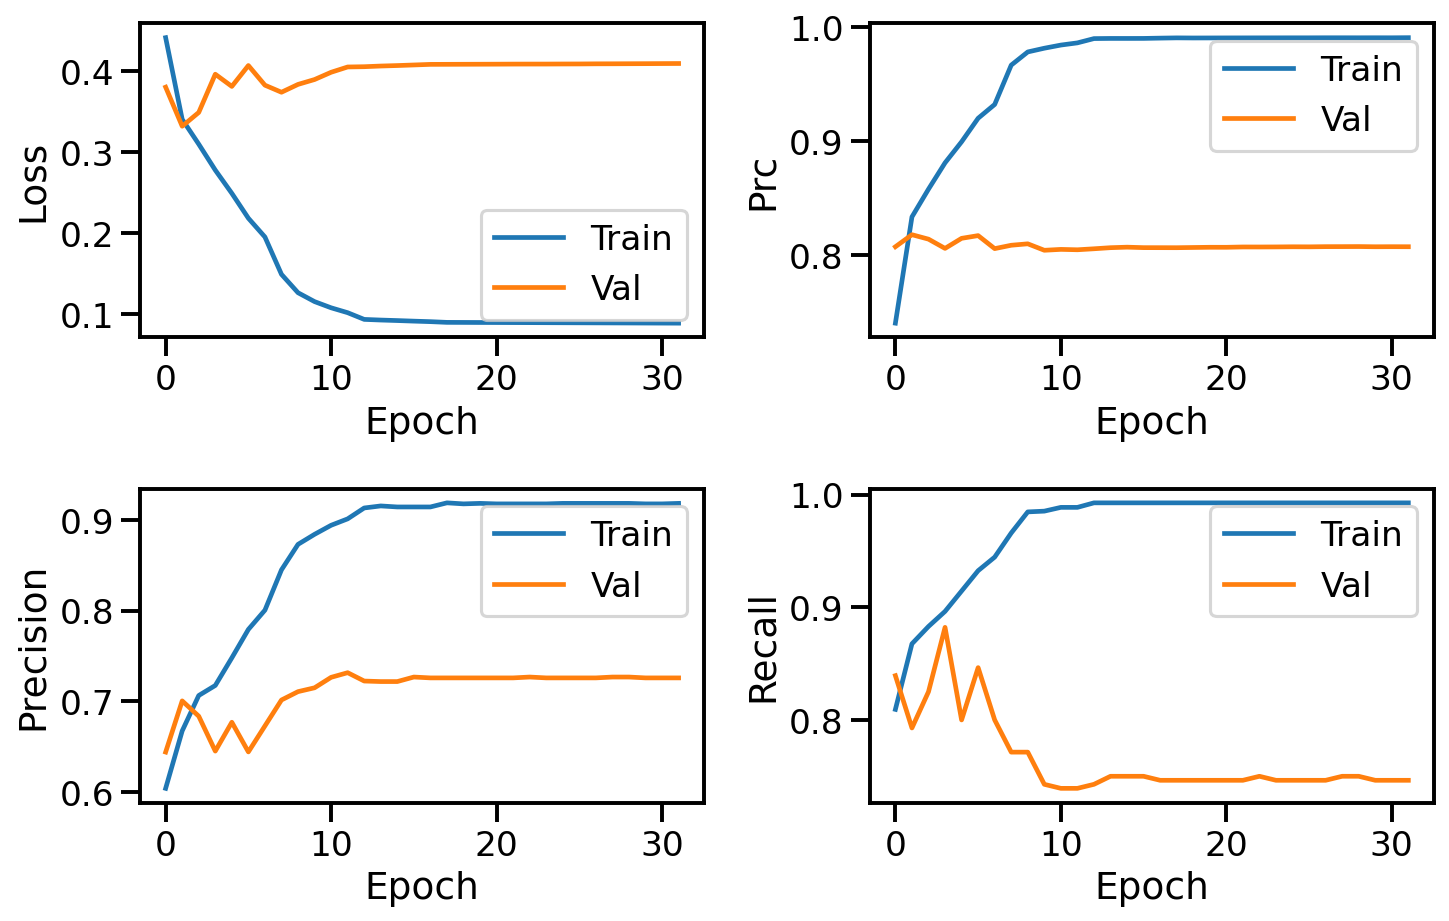

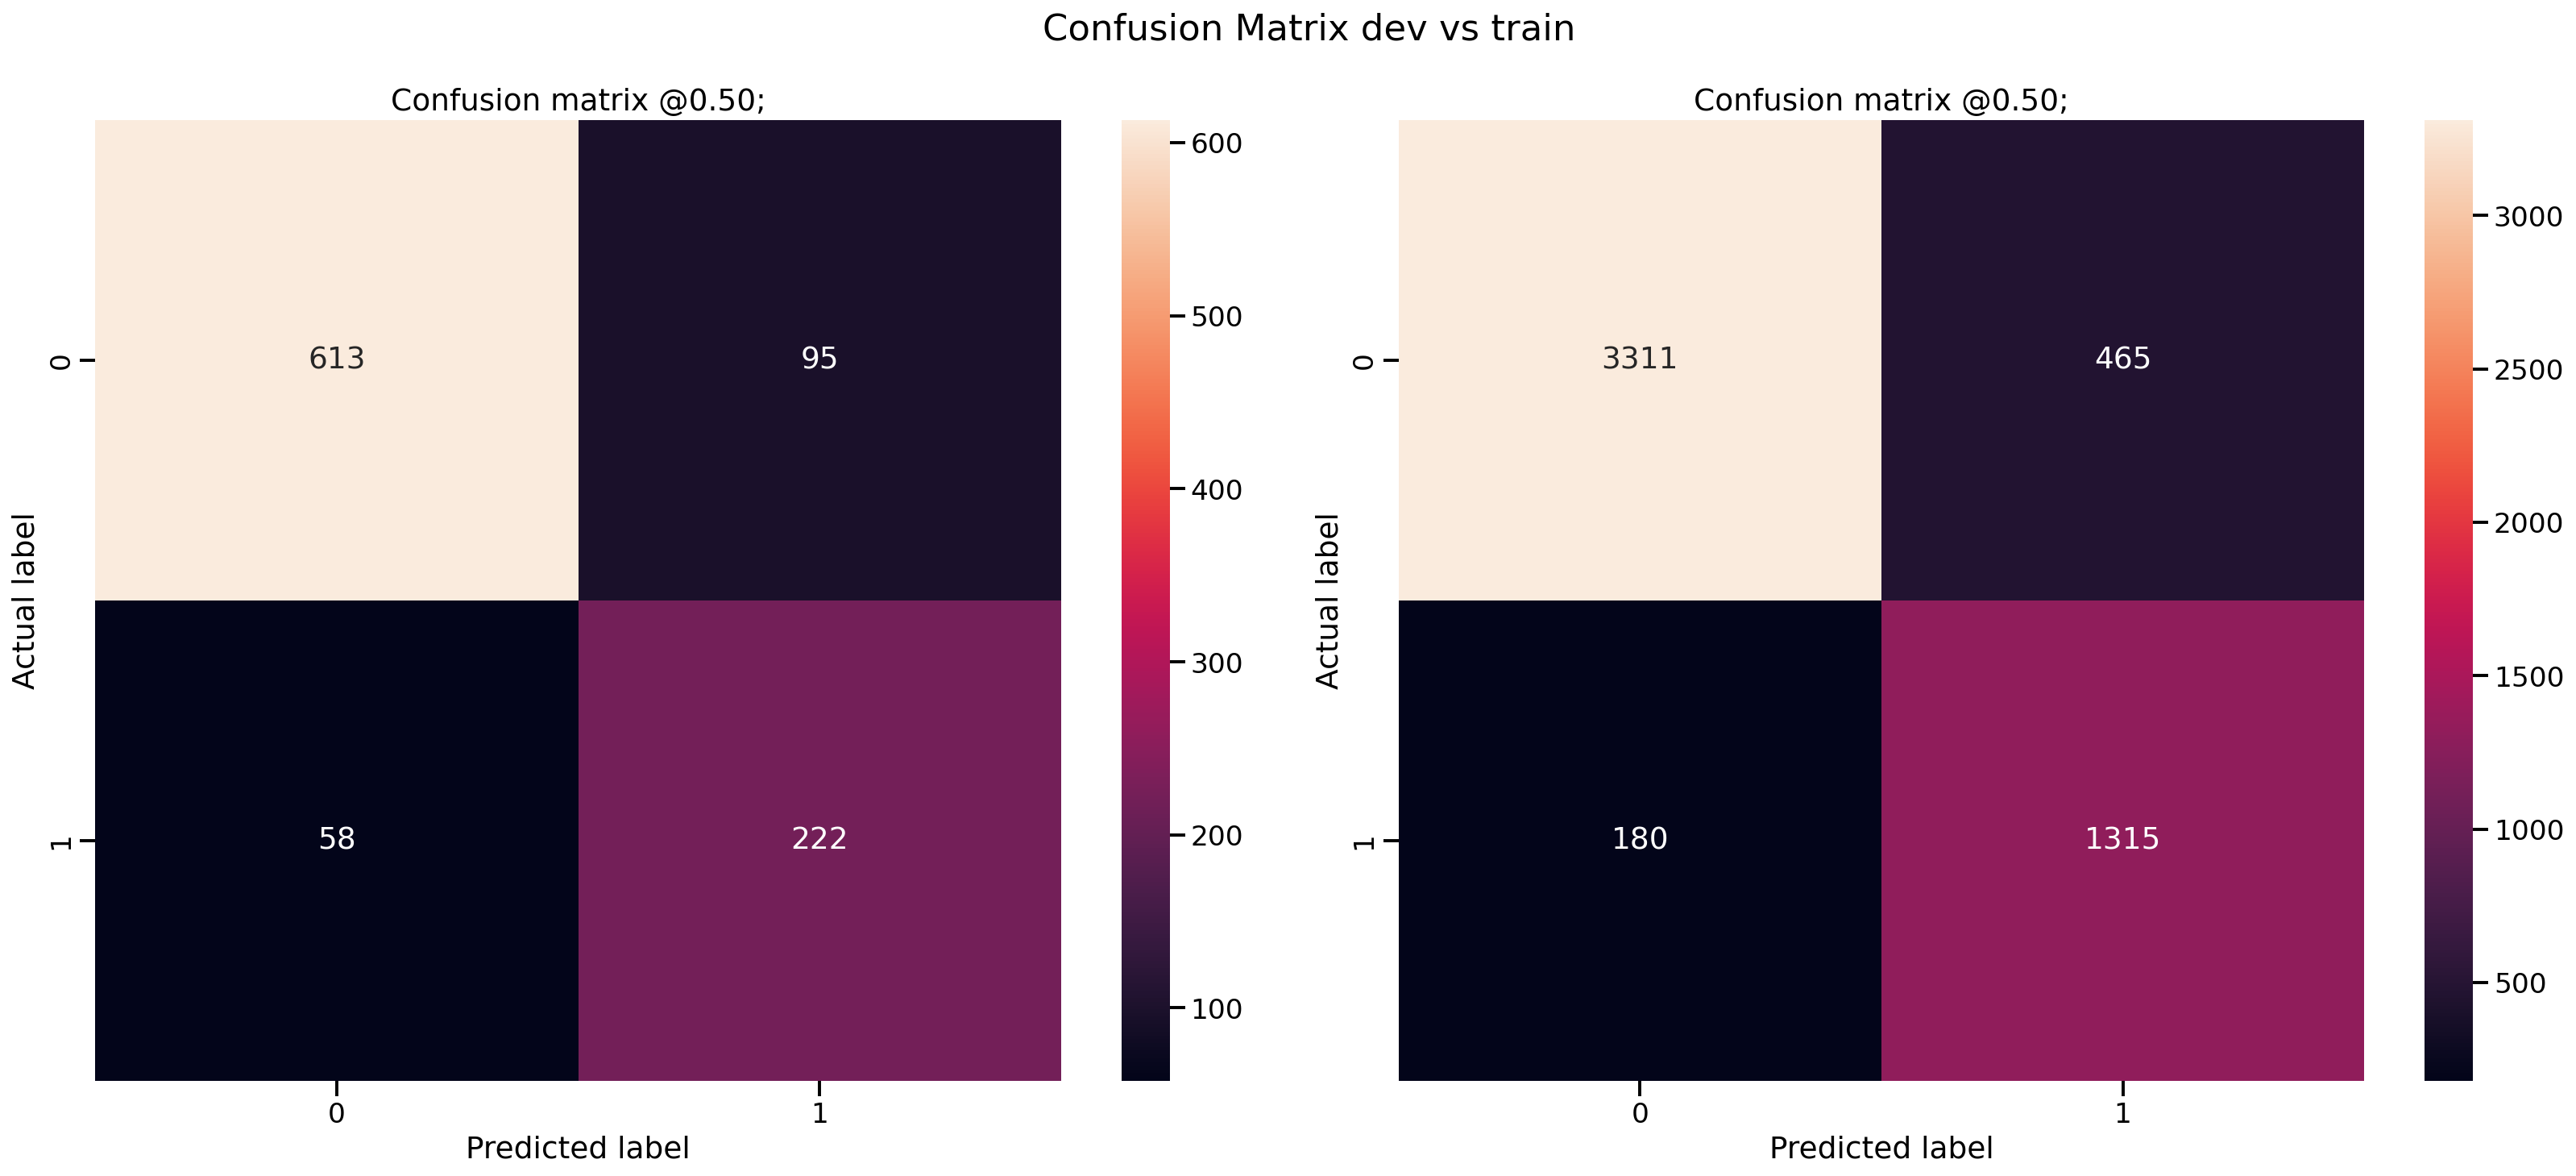

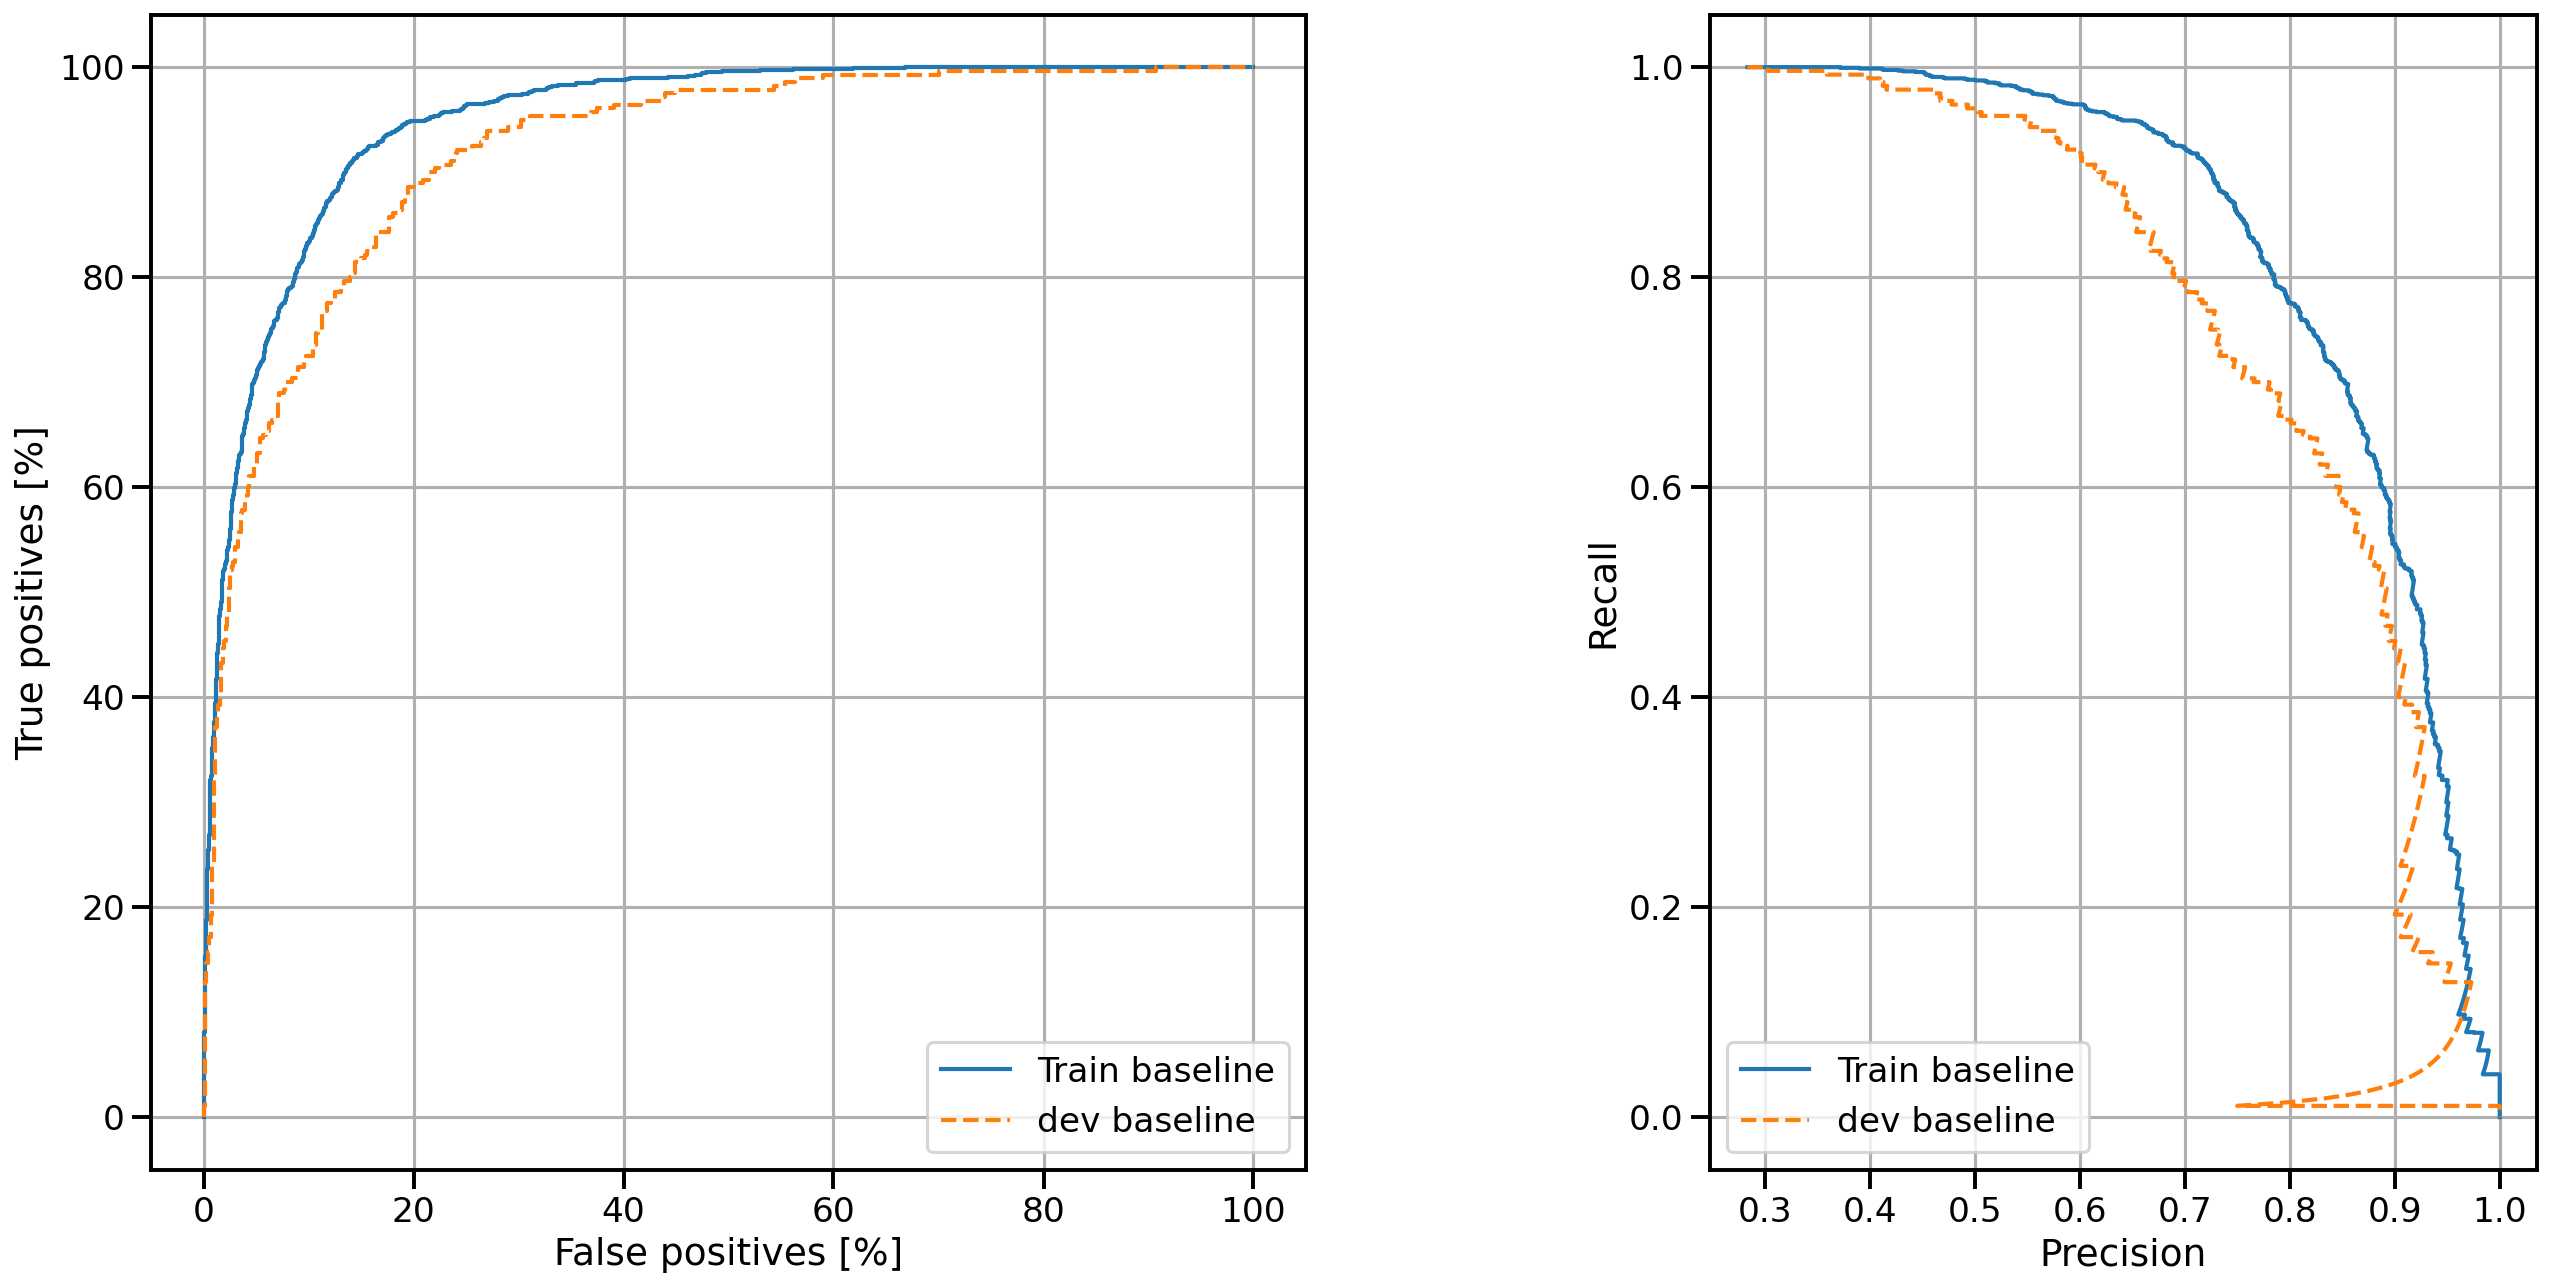

In [527]:
train_weighted_predictions_baseline , test_weighted_predictions_baseline = get_model_summary(new_baseline_model
                                                                           ,new_baseline_history
                                                                           ,(X_train_proc, y_train, X_dev_proc, y_dev,)
                                                                           ,b_size=BATCH_SIZE)

## Sukces: Przełamanie Underfittingu i Zmiana Strategii

Zgodnie z naszymi założeniami inżynieryjnymi, radykalne rozbudowanie architektury (Model 2) przyniosło oczekiwany skutek. Udało się skutecznie **przeuczyć sieć (Overfitting)** na zbiorze treningowym, eliminując tym samym wcześniejszy problem niedopasowania. 

Choć na zbiorze walidacyjnym model osiąga na ten moment rezultaty zbliżone do pierwszego baseline'u, osiągnęliśmy krytyczny punkt w projekcie: udowodniliśmy, że sieć dysponuje odpowiednio dużą pojemnością (Model Capacity), aby zmapować złożone zależności w danych tabelarycznych. Naszym nowym celem staje się teraz **regularyzacja** – nałożenie na sieć odpowiednich ograniczeń (kar), aby przestała zapamiętywać dane treningowe na pamięć, a zaczęła generalizować wiedzę.

### Automatyzacja z Optuną (Optymalizacja Bayesowska)

Aby uniknąć żmudnego i nieefektywnego manualnego strojenia modelu (lub stosowania "ślepego" przeszukiwania siatki – Grid Search), do procesu regularyzacji wykorzystany nowoczesny framework **Optuna**. 
Wykorzystuje on optymalizację bayesowską (algorytm *Tree-structured Parzen Estimator*), co oznacza, że każde kolejne przetestowanie hiperparametrów uczy się na wynikach poprzednich prób. Pozwala to na niezwykle szybkie i celowe odnajdywanie globalnych maksimów dla naszych metryk.



W celu odnalezienia optymalnej architektury i poziomu regularyzacji, zdefiniowano następującą przestrzeń poszukiwań (Search Space):

* **Złożoność Architektury:**
  * `n_layers`: Dynamiczny dobór optymalnej głębokości sieci.
  * `n_units`: Szerokość poszczególnych warstw ukrytych.
* **Dynamika Uczenia:**
  * `learning_rate`: Rozmiar kroku dla optymalizatora Adam.
  * `gradient_clipping`: Próg obcinania gradientów, kluczowy przy ważeniu klas.
* **Metody Regularyzacji (Redukcja Wariancji):**
  * `l2_reg` (Weight Decay): Kary za zbyt duże wartości pojedynczych wag (zapobiega opieraniu decyzji przez sieć na pojedynczych cechach).
  * `dropout`: Losowe "usypianie" procentu neuronów w trakcie epoki, co wymusza na sieci tworzenie redundantnych, odpornych ścieżek wnioskowania.

> **Realizacja Eksperymentu:** Uruchomiono potężną sesję optymalizacyjną składającą się z **300 iteracji (trials)**. Cały proces był na bieżąco monitorowany i analizowany przy użyciu interaktywnego panelu **Optuna Dashboard**, co pozwoliło na wizualną ewaluację zbieżności algorytmu i ważności poszczególnych hiperparametrów.

In [18]:
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
db_path = os.path.join(base_dir, 'src', 'model', 'optuna_results.db')
storage_url = f"sqlite:///{db_path}"
study = optuna.load_study(study_name='churn_opt_v1', storage=storage_url)
print(f"Załadowano study! Najlepszy wynik: {study.best_value}")


Załadowano study! Najlepszy wynik: 0.9323874711990356


In [11]:
vis.plot_optimization_history(study)

### Analiza Historii Optymalizacji: Efektywność "Early Pruning"

Analiza wykresu historii optymalizacji dostarcza kluczowych wniosków na temat wydajności procesu strojenia hiperparametrów. Z zaplanowanej, potężnej puli **300 iteracji (trials)**, zaledwie kilkanaście zostało poddanych pełnemu cyklowi treningowemu. Zdecydowana większość prób została wcześnie przerwana (pruned) przez wbudowane algorytmy Optuny.


**Wartość Inżynieryjna (Optymalizacja Zasobów):**
Zastosowanie mechanizmu *Early Pruning* (`MedianPruner`) to standard produkcyjny MLOps. Algorytm w czasie rzeczywistym ewaluuje krzywe uczenia i błyskawicznie "zabija" te konfiguracje hiperparametrów (ślepe uliczki), które po kilku pierwszych epokach rokują gorzej niż dotychczasowy model lidera. W środowisku biznesowym przekłada się to na drastyczną oszczędność czasu oraz redukcję kosztów infrastruktury chmurowej (np. rachunków za instancje GPU).

#### Stabilność Metryki i Siła Sygnału (AUC 0.916 - 0.932)

Podobnie jak na wcześniejszych etapach modelowania, krzywa optymalizowanej metryki (ROC AUC) na ukończonych iteracjach okazała się wysoce stabilna i niemal liniowa:

* **Najlepszy wynik (Best Trial):** **AUC = 0.932**
* **Najsłabszy (ukończony) wynik:** **AUC = 0.916**

> **Wniosek Analityczny i Biznesowy:** Niewielka rozpiętość (delta wynosząca zaledwie ~0.016) pomiędzy najsłabszą a optymalną konfiguracją hiperparametrów potwierdza fundamentalną stabilność naszego potoku danych (Data Pipeline). Oznacza to, że sygnał predykcyjny ukryty w zbiorze jest na tyle czysty i silny, że model potrafi go odczytać niezależnie od drobnych zmian w architekturze sieci. Dotarliśmy do "szklanego sufitu" tej metody, co jest ostatecznym potwierdzeniem, że dalsze mikrostrojenie sieci neuronowej mija się z celem. --> Zmiana podejścia modelowania 

In [271]:
study.best_params

{'n_layers': 2,
 'learning_rate': 0.01684853493488324,
 'clip_norm': 0.3059410456942121,
 'l2_reg': 2.3426754464306136e-05,
 'nodes_l0': 95,
 'dropout_l0': 0.49832053139823584,
 'nodes_l1': 31,
 'dropout_l1': 0.3273991127743286}

## Konstrukcja Finalnej Architektury (Zoptymalizowany Model ANN)

Na podstawie wyników wielowymiarowej optymalizacji bayesowskiej (300 iteracji) wyciągnięto słownik najlepszych hiperparametrów (`best_params`). Wykorzystamy go teraz do zbudowania ostatecznej wersji naszej sieci neuronowej. 
Poniższa funkcja została zaprojektowana w sposób wysoce modularny – głębokość sieci (`n_layers`), szerokość poszczególnych warstw oraz poziom regularyzacji są generowane dynamicznie.

```python
import tensorflow as tf
def build_best_opt_model(best_params, initial_bias, n_features):
    """
    Buduje dynamiczną architekturę sieci na podstawie optymalnych parametrów z Optuny.
    """
    he_init = tf.keras.initializers.HeNormal()
    model = Sequential()
    
    # Warstwa wejściowa
    model.add(Input(shape=(n_features,)))

    # Dynamiczne budowanie warstw ukrytych
    for i in range(best_params['n_layers']):
        # 1. Warstwa Gęsta (Szerokość dopasowana przez Optunę)
        model.add(Dense(best_params[f'nodes_l{i}'], kernel_initializer=he_init))
        
        # 2. Normalizacja Wsadowa (Batch Normalization)
        model.add(BatchNormalization())
        
        # 3. Aktywacja (LeakyReLU)
        model.add(LeakyReLU(negative_slope=0.01))
        
        # 4. Regularyzacja (Dropout o natężeniu dobranym przez Optunę dla danej warstwy)
        model.add(Dropout(best_params[f'dropout_l{i}']))

    # Warstwa wyjściowa z prekalibrowanym obciążeniem (Initial Bias)
    model.add(Dense(1, 
                    activation='sigmoid', 
                    bias_initializer=tf.keras.initializers.Constant(initial_bias)))
    
    # Kompilacja z dynamicznym przycinaniem gradientu i tempem uczenia
    model.compile(
        optimizer=Adam(learning_rate=best_params['learning_rate'], 
                       clipnorm=best_params['clip_norm']),
        loss='binary_crossentropy',
        metrics=get_metrics()
    )
    
    return model

In [19]:
final_model = build_best_opt_model(study.best_params, INITIAL_BIAS, N_FEATURES)
final_model.summary()

2026-03-01 13:32:36.914460: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-01 13:32:36.914519: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-03-01 13:32:36.914523: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-03-01 13:32:36.914567: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-01 13:32:36.914581: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 95)             │         3,705 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 95)             │           380 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 95)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 95)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         2,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 31)             │           124 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            32 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,217 (28.19 KB)

 Trainable params: 6,965 (27.21 KB)

 Non-trainable params: 252 (1008.00 B)

In [20]:
final_model_history = final_model.fit(
     X_train_proc
    ,y_train
    ,epochs = 200
    ,batch_size = 64
    ,shuffle=True
    ,validation_data = (X_dev_proc, y_dev)
    ,callbacks = [lr_decay(), 
                  early_stopping(100)]
    ,class_weight = class_weight,
    verbose = 1
)

Epoch 1/200


2026-03-01 13:32:43.311204: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - Brier score: 0.1521 - accuracy: 0.7814 - auc: 0.8613 - cross entropy: 0.4672 - f1_score: 0.6720 - fn: 315.0000 - fp: 837.0000 - loss: 0.4674 - prc: 0.7041 - precision: 0.5850 - recall: 0.7893 - tn: 2939.0000 - tp: 1180.0000 - val_Brier score: 0.1263 - val_accuracy: 0.8360 - val_auc: 0.9119 - val_cross entropy: 0.4191 - val_f1_score: 0.7437 - val_fn: 45.0000 - val_fp: 117.0000 - val_loss: 0.4191 - val_prc: 0.8188 - val_precision: 0.6676 - val_recall: 0.8393 - val_tn: 591.0000 - val_tp: 235.0000 - learning_rate: 0.0168
Epoch 2/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - Brier score: 0.1299 - accuracy: 0.8173 - auc: 0.8986 - cross entropy: 0.4065 - f1_score: 0.7226 - fn: 241.0000 - fp: 722.0000 - loss: 0.4017 - prc: 0.7720 - precision: 0.6346 - recall: 0.8388 - tn: 3054.0000 - tp: 1254.0000 - val_Brier score: 0.1215 - val_accuracy: 0.8289 - val_auc: 0.9203 - val_cross entropy: 0.3912 - val_f1_score: 0.7404 - val_fn: 39.0000 - val_fp: 130.0000 - 

Brier score :  0.10981
accuracy :  0.83806
auc :  0.92958
cross entropy :  0.34683
f1_score :  0.75078
fn :  39.0
fp :  121.0
loss :  0.34683
prc :  0.85945
precision :  0.66575
recall :  0.86071
tn :  587.0
tp :  241.0
True Negatives:  587
False Positives:  121
False Negatives:  39
True Positives:  241
Total Customers that churned:  280
True Negatives:  3167
False Positives:  609
False Negatives:  135
True Positives:  1360
Total Customers that churned:  1495


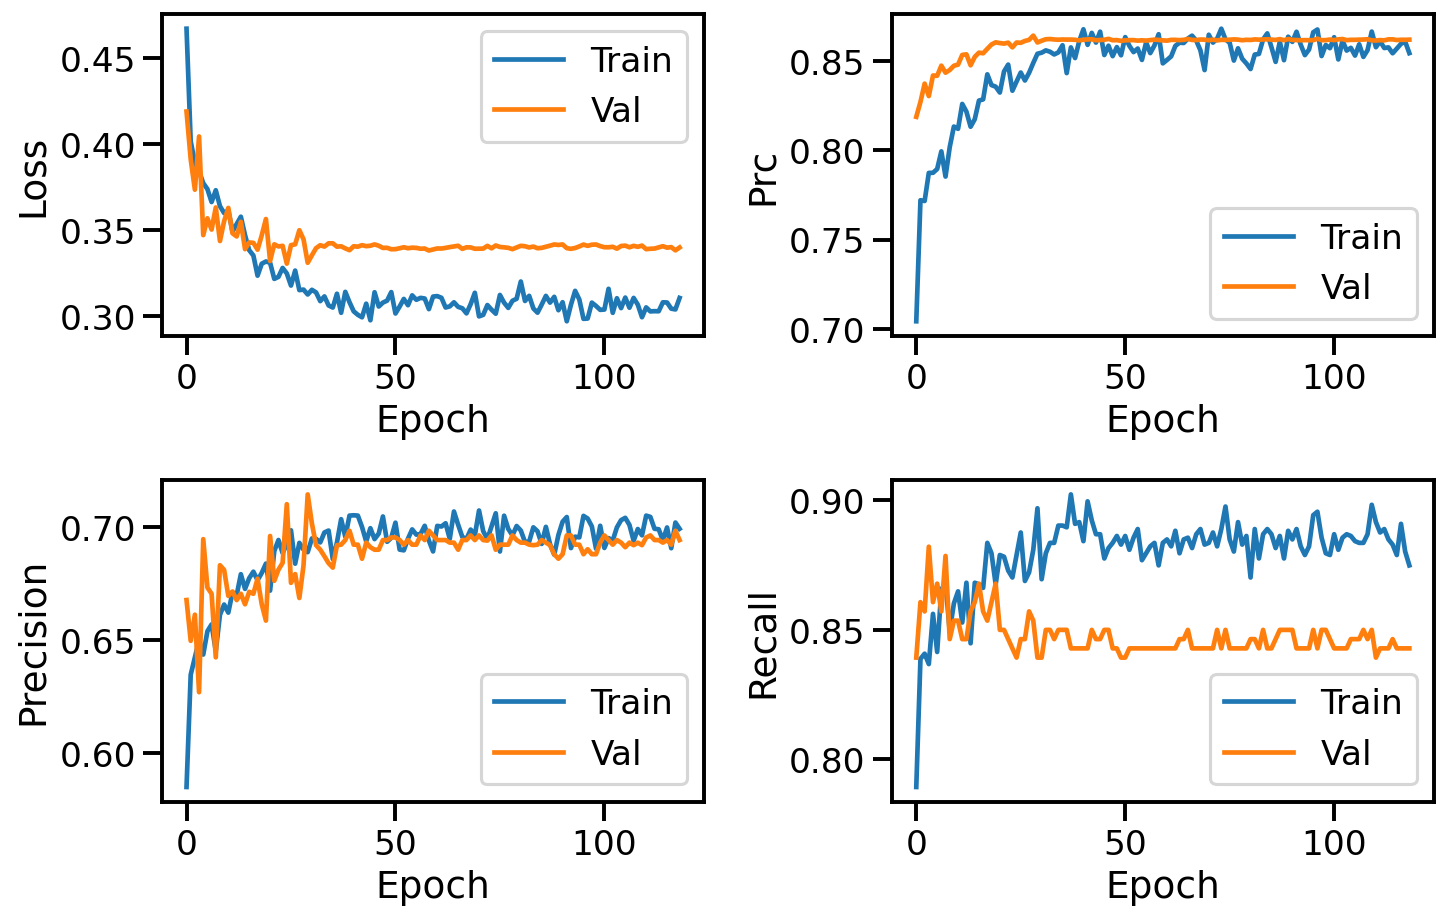

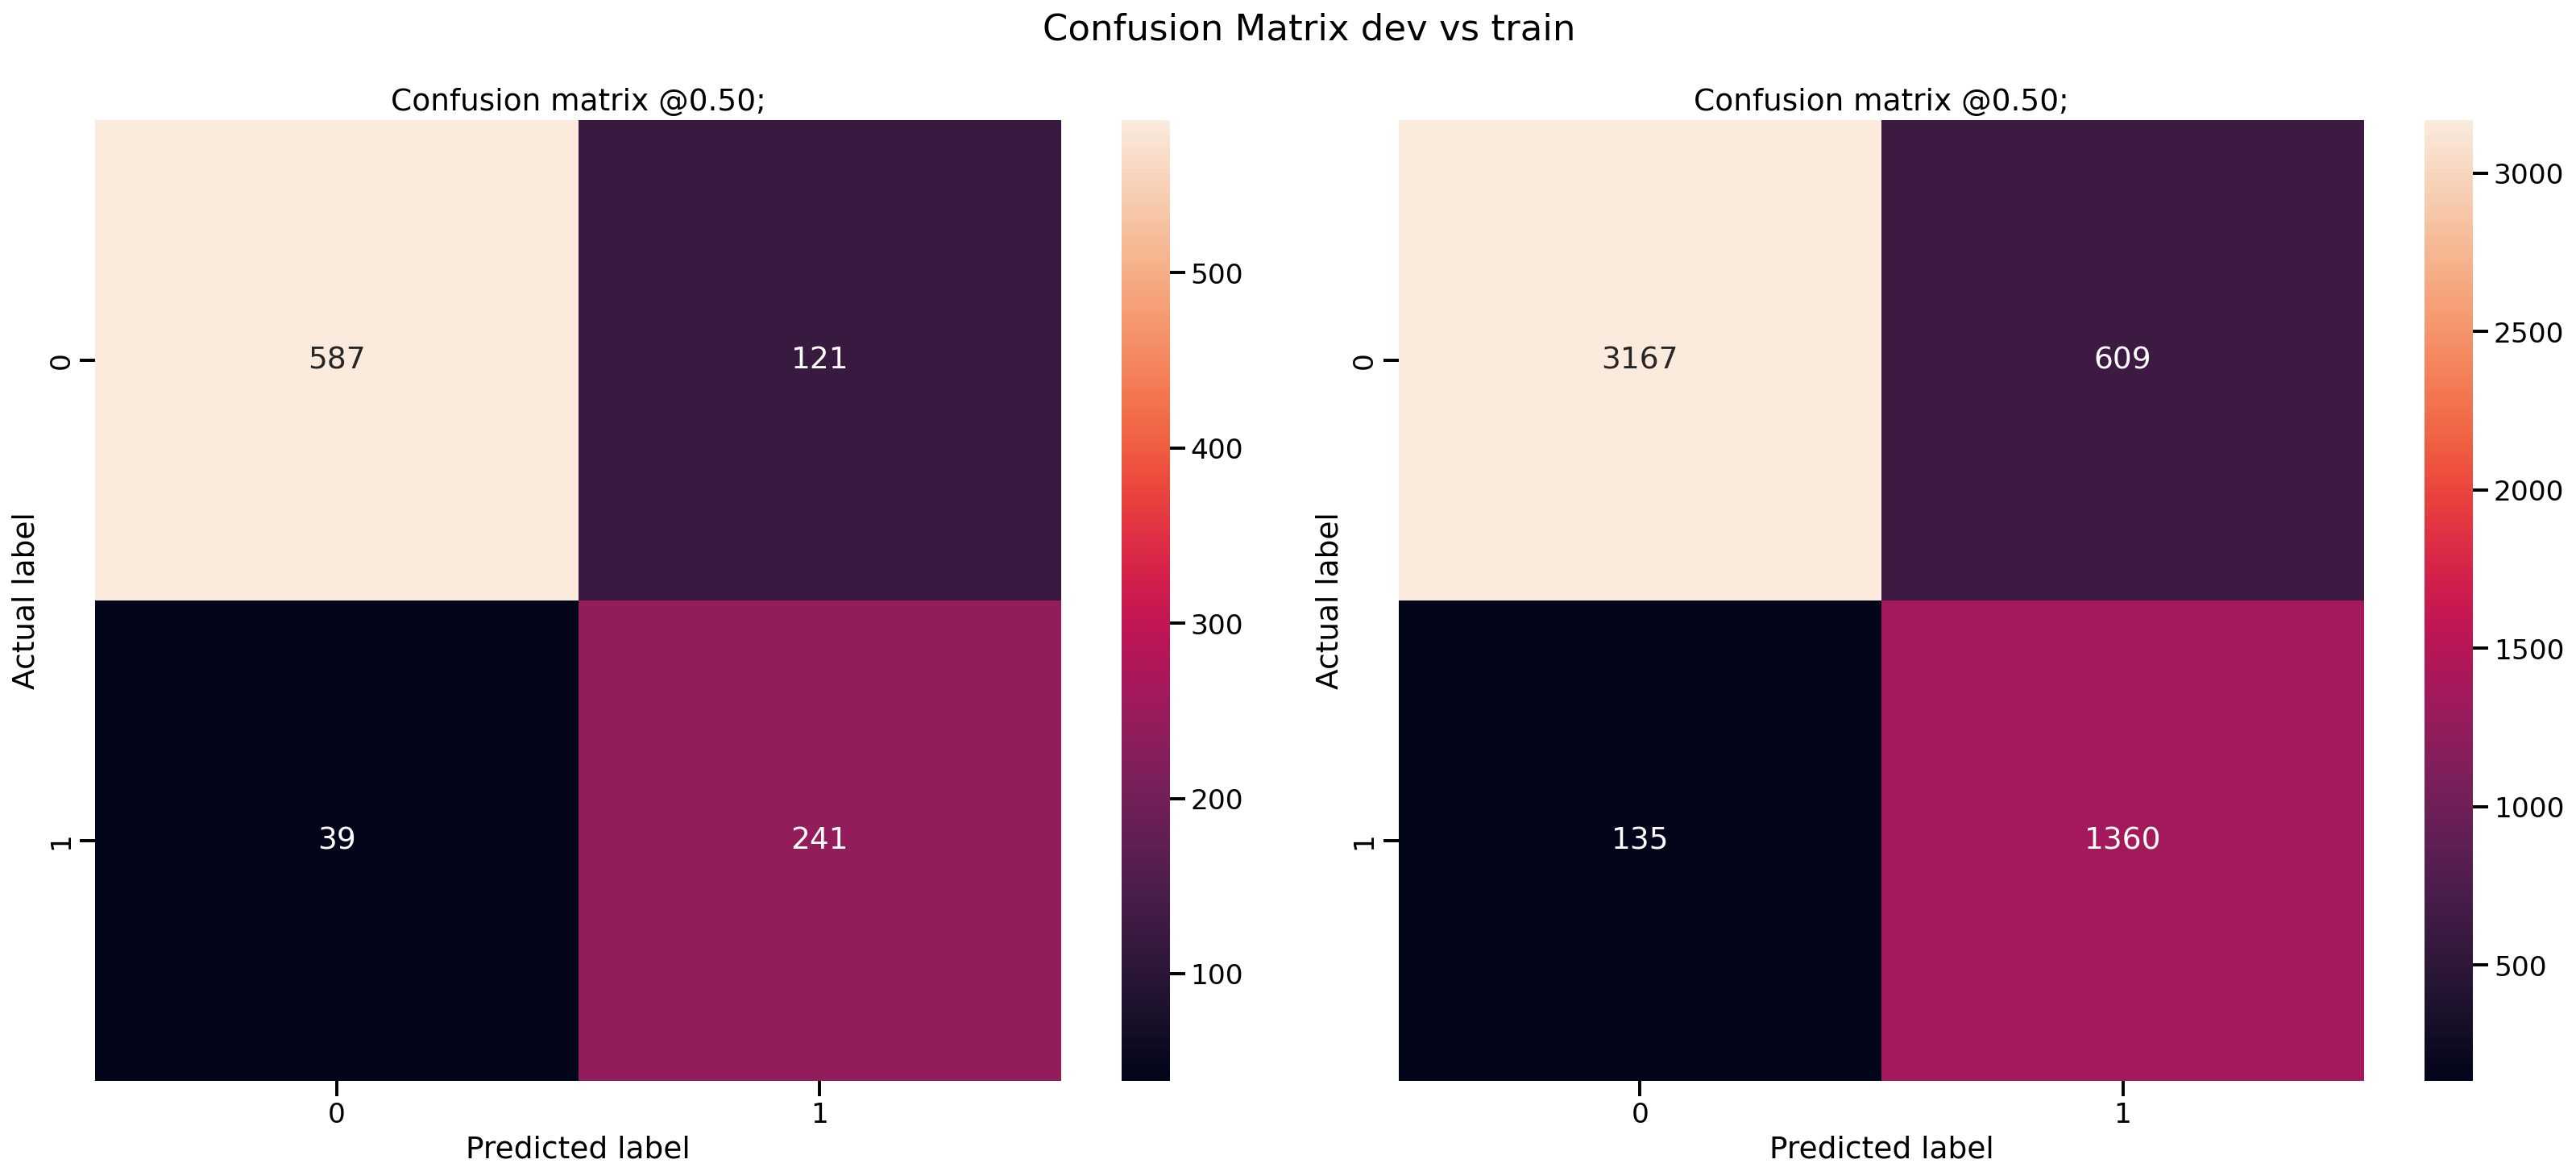

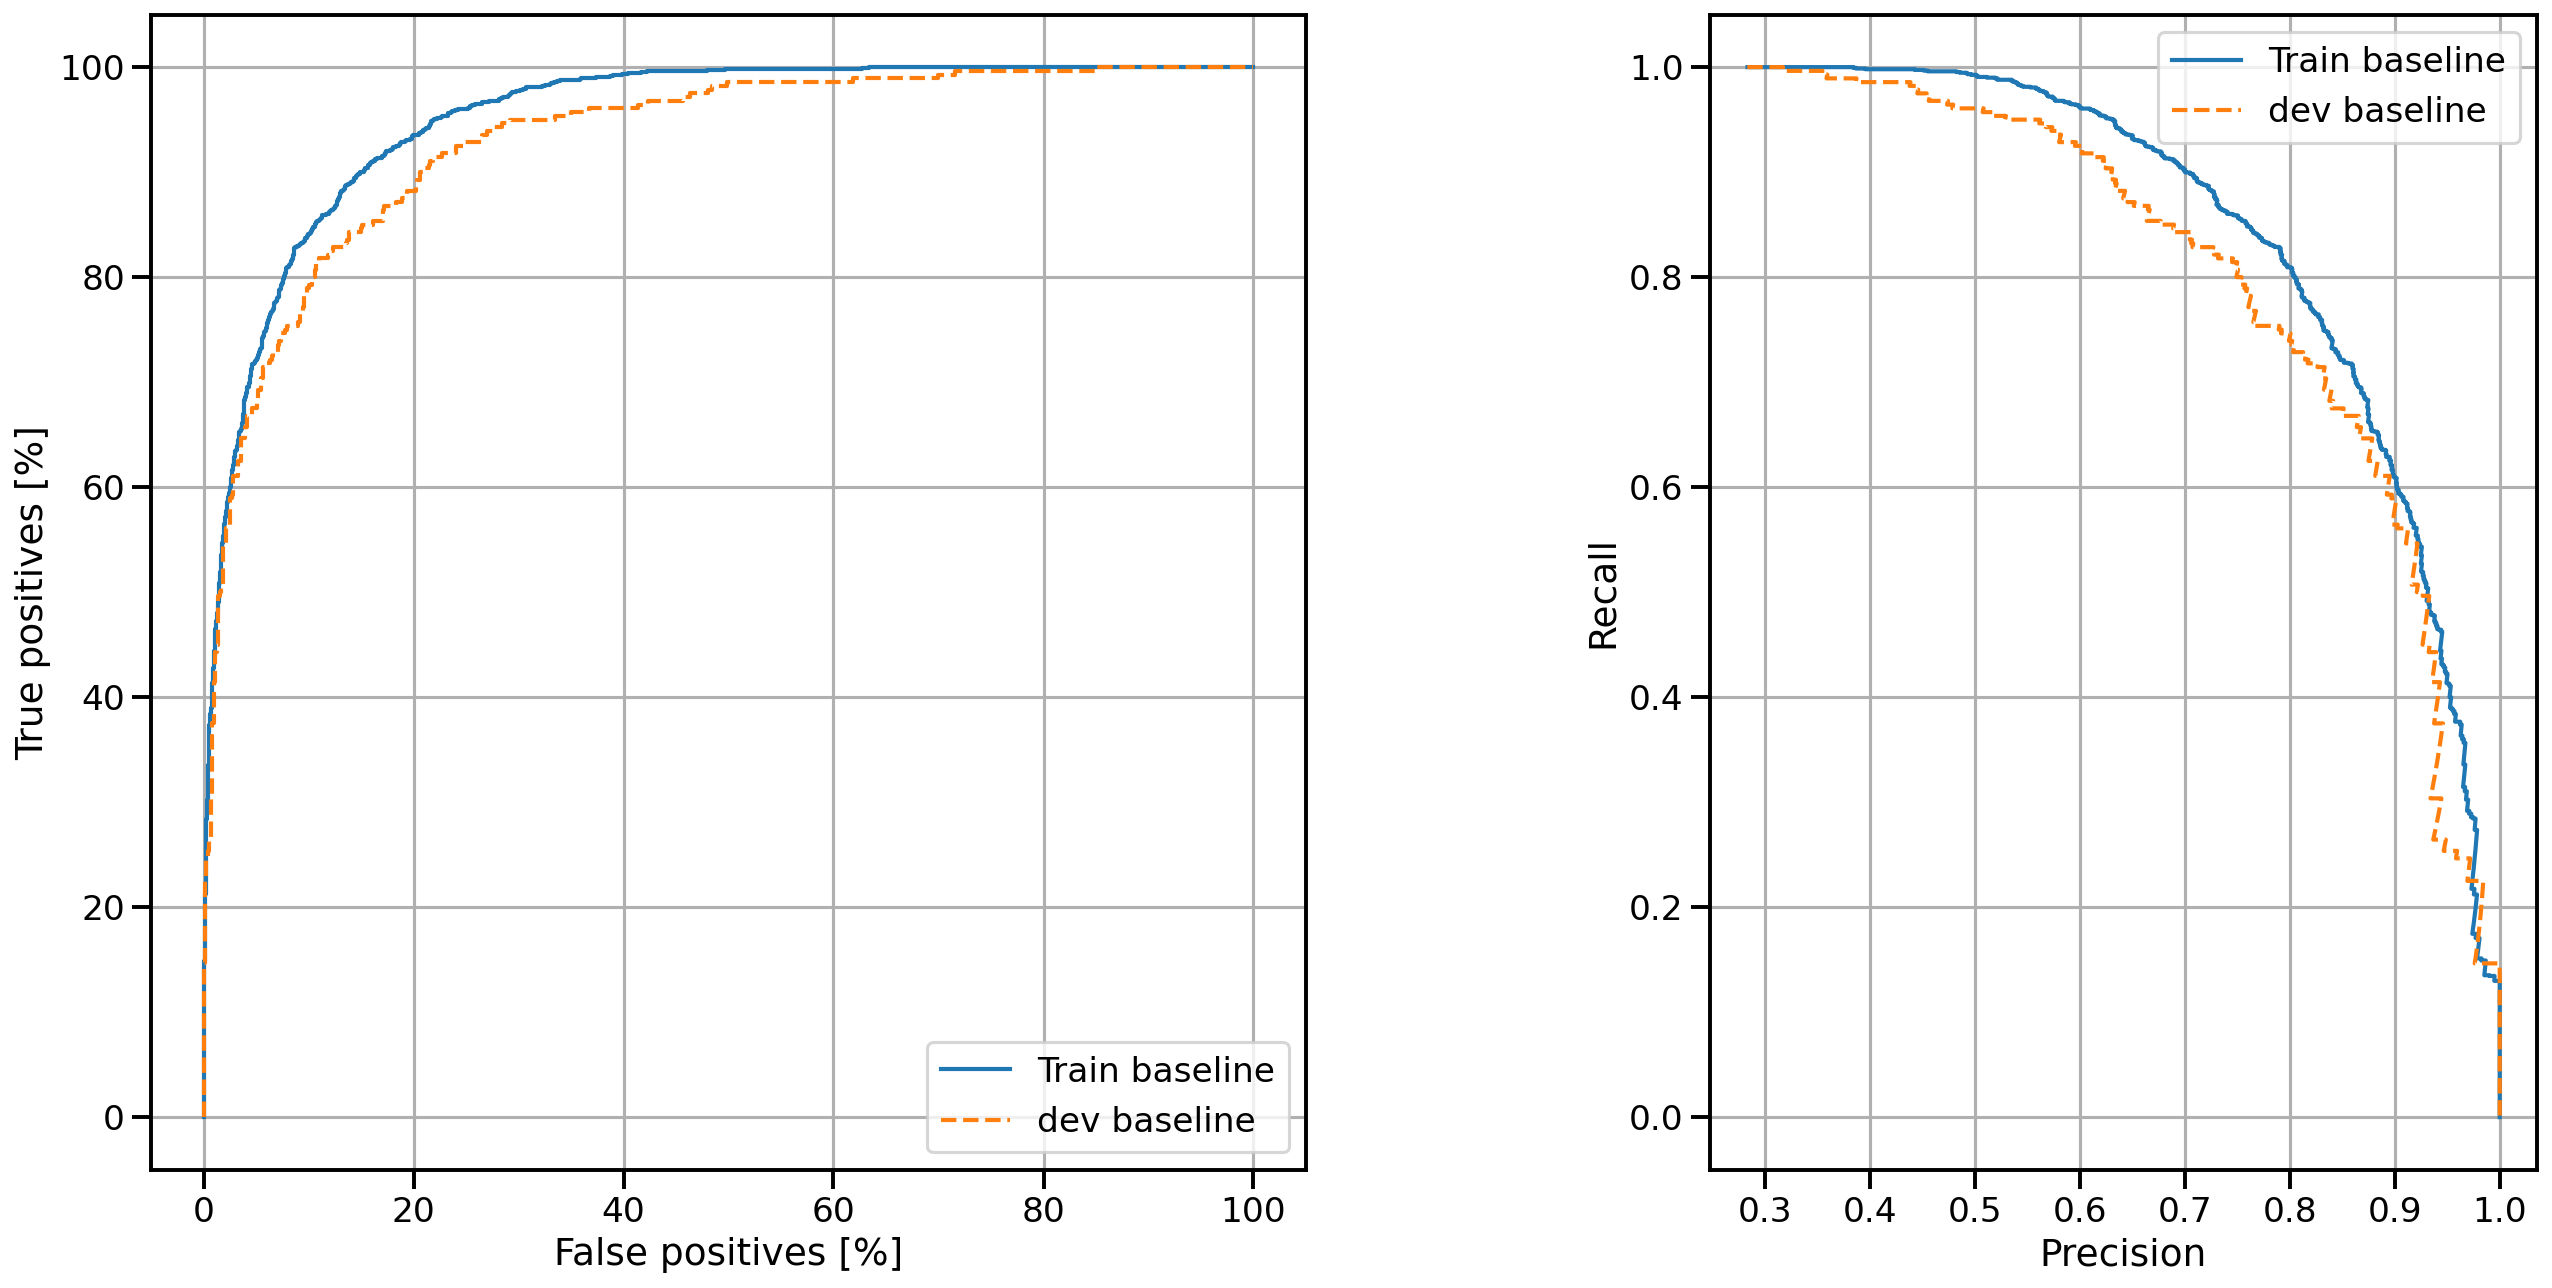

In [22]:
train_weighted_predictions_baseline , test_weighted_predictions_baseline = get_model_summary(final_model
                                                                           ,final_model_history
                                                                           ,(X_train_proc, y_train, X_dev_proc, y_dev,)
                                                                           ,b_size=64)

In [23]:
y_pred_ann_fin = (test_weighted_predictions_baseline>0.5).astype(int)
fin_dev_preds_mod = (test_weighted_predictions_baseline >= 0.6).astype(int)
print(classification_report(fin_dev_preds_mod, y_dev))
print(classification_report((test_weighted_predictions_baseline >= 0.5).astype(int), y_dev))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       665
           1       0.83      0.72      0.77       323

    accuracy                           0.86       988
   macro avg       0.85      0.82      0.83       988
weighted avg       0.86      0.86      0.86       988

              precision    recall  f1-score   support

           0       0.83      0.94      0.88       626
           1       0.86      0.67      0.75       362

    accuracy                           0.84       988
   macro avg       0.84      0.80      0.82       988
weighted avg       0.84      0.84      0.83       988



Finalny model jest tylko troche lepszy od baselinu (gdzy był silny overfitting). Performance na zbiorze walidacyjnym jest w zasadzie bardzo zbliżony do baselinu. Przyczyny upatruje się w zbyt małej ilości danych. Sieci neuronowe radzą sobie najlepiej w sytuacji gdzie danych jest bardzo dużo. W kolejnym etapie wypróbujemy inne metody modelowania w celu stworzenia możliwie njalpeszego narzędzia 

## Podsumowanie Etapu Deep Learning: Ewaluacja i Wnioski

Po rygorystycznym przetestowaniu zoptymalizowanej architektury, ewaluacja na zbiorze walidacyjnym dostarczyła niezwykle cennych wniosków analitycznych. Finalny, dostrojony przez Optunę model wykazał jedynie marginalną poprawę wydajności względem przeuczonego modelu bazowego (Baseline). Metryki walidacyjne ustabilizowały się.

### Pivot Technologiczny (Dalsze Kroki)

Osiągnięcie limitu możliwości dla sieci neuronowych kończy ten etap eksperymentów, ale otwiera drzwi do budowy docelowego narzędzia. Udowodniliśmy, że w danych drzemie silny sygnał predykcyjny (historyczne AUC > 0.91), który może skorzystać na zmianie aparatu matematycznego,

> **Decyzja Inżynieryjna:** W celu stworzenia możliwie najlepszego, produkcyjnego narzędzia biznesowego dla działu Retencji, w kolejnym etapie dokonujemy strategicznego zwrotu (Pivot). Wykorzystane zostaną metody modelowania z rodziny **Gradient Boostingu**, które stanowią absolutny standard rynkowy dla małych i średnich zbiorów tabelarycznych. Spodziewamy się, że dzięki wbudowanej zdolności do obsługi nieliniowości i odporności na szum, algorytmy te pozwolą nam przebić obecne osiągi i zmaksymalizować wartość biznesową modelu.

***
# XGBoost 


In [ ]:
# Ustawienie wagi (Analogicznie jak dla sieci)
cw_xgb = class_weight[1]/class_weight[0]

In [ ]:
baseline_xgb = Pipeline([
    ('preprocessor', preprocessor()),
    ('classifier', xgb.XGBClassifier(eval_metric='auc',
                                 scale_pos_rate = cw_xgb))
])

baseline_xgb.fit(X_train, y_train);
y_dev_pred_proba = baseline_xgb.predict_proba(X_dev)[:,1]
y_dev_pred_xgb = (y_dev_pred_proba > 0.5).astype(int)

AUC XGB: 0.936087570621469
AUC ANN: 0.9313609765940274
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       708
           1       0.80      0.71      0.75       280

    accuracy                           0.87       988
   macro avg       0.84      0.82      0.83       988
weighted avg       0.86      0.87      0.86       988



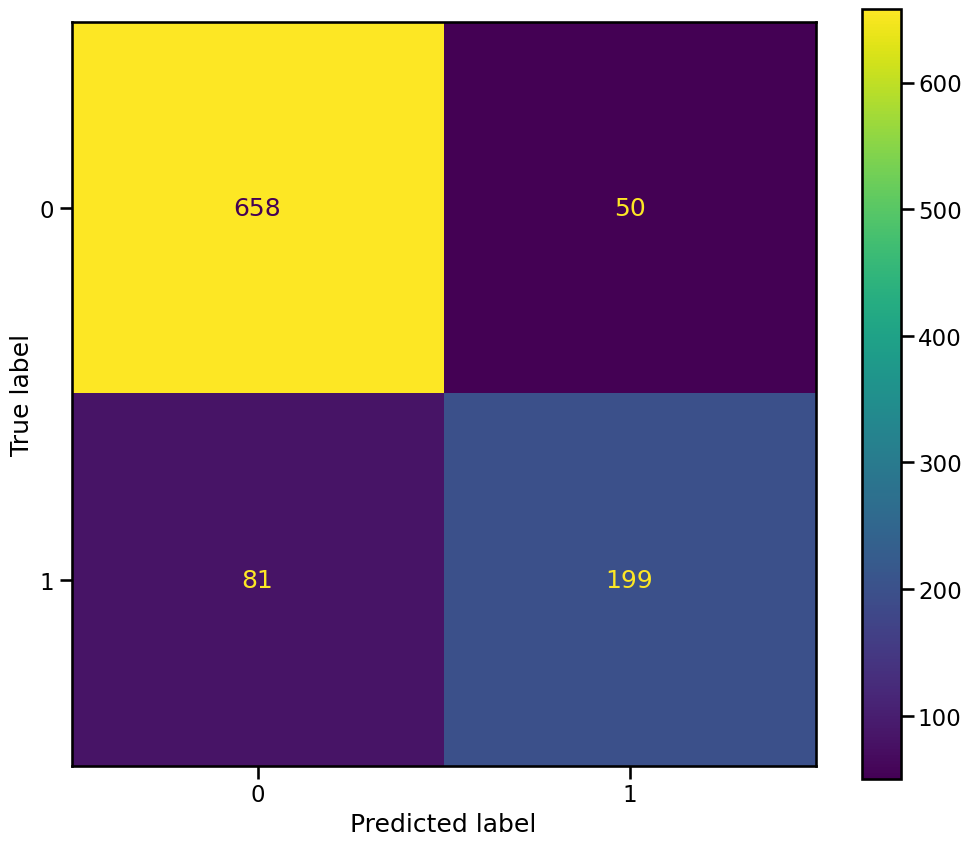

In [737]:
# ConfusionMatrixDisplay.from_predictions(y_dev, (y_dev_pred > 0.5).astype(int))
# print(f"Recall XGB: {recall_score(y_dev,y_dev_pred)}")
# print(f"Recall ANN: {recall_score(y_dev, test_weighted_predictions_baseline)}")
print(f"AUC XGB: {roc_auc_score(y_dev,y_dev_pred_proba)}")
print(f"AUC ANN: {roc_auc_score(y_dev,test_weighted_predictions_baseline)}")
ConfusionMatrixDisplay.from_predictions(y_dev, y_dev_pred_xgb)
print(classification_report(y_dev, y_dev_pred_xgb))

## XGBoost Baseline vs Zoptymalizowana Sieć Neuronowa (ANN)

Zgodnie z naszymi przewidywaniami dotyczącymi specyfiki danych tabelarycznych, wdrożenie algorytmu z XGBoost natychmiast przyniosło wymierne rezultaty. Dokonaliśmy bezpośredniego zestawienia zdolności separacji klas (mierzonej polem pod krzywą ROC) dla obu architektur.

### Porównanie Metryk (ROC AUC):

* **XGBoost (Model Bazowy / Out-of-the-box):** **0.9361**
* **Sieć Neuronowa (Zoptymalizowana przez Optunę):** **0.9314**



### Wnioski Analityczne i Biznesowe:

Jak można zauważyć, domyślny, nieskonfigurowany model **XGBoost już na starcie lepiej rozdziela klasy niż głęboka sieć neuronowa**, która była rygorystycznie trenowana i tunowana przez setki iteracji optymalizacji bayesowskiej. 

Choć w wartościach bezwzględnych różnica w metryce AUC jest stosunkowo niewielka (marginalna przewaga na poziomie ~0.005), niesie ona za sobą implikacje inżynieryjne:

1. **Inductive Bias (Zniekształcenie indukcyjne):** Drzewa decyzyjne posiadają naturalną przewagę w radzeniu sobie z nieciągłymi, ustrukturyzowanymi danymi (tzw. *tabular inductive bias*). Nie wymagają tak ogromnych zbiorów danych do odnalezienia optymalnych reguł podziału, jak ma to miejsce w przypadku propagacji wstecznej w sieciach MLP.
2. **Koszty Obliczeniowe (ROI):** Sieć neuronowa wymagała złożonej architektury, inicjalizacji wag, balansowania gradientów i setek prób Optuny. XGBoost osiągnął wyższy wynik praktycznie "od ręki". W realiach biznesowych oznacza to drastyczne skrócenie czasu wdrożenia (Time-to-Market) oraz niższe koszty utrzymania modelu na produkcji.

> **Następny Krok:** Skoro bazowy XGBoost potrafi wyciągnąć ze zbioru AUC na poziomie 0.936, istnieje ogromny potencjał na jeszcze lepszy wynik. W kolejnym kroku poddamy ten algorytm zaawansowanemu procesowi strojenia hiperparametrów (Również wykorzystując optunę), aby wycisnąć z niego maksymalne możliwe możliwości predykcyjne.

In [12]:

base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
db_path = os.path.join(base_dir, 'src', 'model', 'optuna_xgb_results.db')
storage_url = f"sqlite:///{db_path}"
study = optuna.load_study(study_name='churn_opt_xgb_v1', storage=storage_url)
print(f" Załadowano study! Najlepszy wynik: {study.best_value}")


 Załadowano study! Najlepszy wynik: 0.939491793252231


## Optymalizacja Hiperparametrów XGBoost (Optuna)

Analogicznie do procesu przeprowadzonego dla sieci neuronowej, model XGBoost został poddany rygorystycznemu procesowi strojenia hiperparametrów. Wykorzystano framework Optuna, uruchamiając sesję składającą się z 300 iteracji, w celu precyzyjnego dostosowania mechaniki budowy drzew decyzyjnych oraz redukcji wariancji.

### Porównanie Wyników (ROC AUC):

* **XGBoost (Baseline Out-of-the-box):** 0.9361
* **XGBoost (Optuna Best Trial):** 0.9395

### Wnioski Analityczne: Potwierdzenie "Szklanego Sufitu"

Osiągnięty po optymalizacji wynik (0.9395) jest absolutnie najwyższym w całym projekcie, co ostatecznie udowadnia wyższość algorytmów z rodziny Gradient Boostingu na tym konkretnym, ustrukturyzowanym zbiorze danych. Należy jednak obiektywnie odnotować, że przyrost jakości w stosunku do modelu bazowego jest ponownie marginalny (poprawa o niespełna 0.0034).

Stanowi to ostateczne i twarde potwierdzenie hipotezy o osiągnięciu limitu informacyjnego (tzw. "szklanego sufitu"). Rygorystyczna inżynieria cech oraz konfrontacja ze sobą skrajnie różnych architektur (od Deep Learningu po zaawansowane metody zespołowe) udowadniają, że algorytmy wyciągneły już z dostępnych zmiennych sto procent użytecznego sygnału predykcyjnego. 

> **Rekomendacja Biznesowa:** Dalsze, kosztowne obliczeniowo strojenie hiperparametrów nie przyniesie już wymiernego zwrotu z inwestycji (ROI). Głównym czynnikiem blokującym model przed osiągnięciem jeszcze wyższych metryk nie jest brak optymalizacji algorytmu, lecz obiektywna wielkość samego zbioru danych (około 6500 obserwacji). Aby znacząco podnieść skuteczność systemu w warunkach komercyjnych, jedyną racjonalną ścieżką jest powiększenie wolumenu danych historycznych lub wzbogacenie struktury o zupełnie nowe predyktory (np. dane behawioralne z aplikacji mobilnej operatora).

In [13]:
best_xgb_study = study.best_params
print('Najlepsze hiperparametry: ')
display(best_xgb_study)
xgb_opt_best = xgb.XGBClassifier(**best_xgb_study)

best_xgb = Pipeline([
    ('preprocessor', preprocessor()),
    ('classifier', xgb_opt_best)
])

best_xgb.fit(X_train, y_train)
best_xgb_preds = best_xgb.predict(X_dev)
best_xgb_proba_preds = best_xgb.predict_proba(X_dev)[:,1]
best_xgb_preds = (best_xgb_proba_preds > 0.5).astype(int)

Najlepsze hiperparametry: 


{'n_estimators': 650,
 'learning_rate': 0.0107213861045388,
 'max_depth': 4,
 'subsample': 0.8579900598858515,
 'colsample_bytree': 0.6131320506993851,
 'gamma': 0.05000372507756223,
 'scale_pos_weight': 2.9828375863556613}

In [15]:
vis.plot_edf(study)

In [14]:
vis.plot_slice(study)

### Analiza Przestrzeni Poszukiwań: Konwergencja Algorytmu Optuna

Analizując wygenerowany wykres zależności hiperparametrów (z zaimplementowanego panelu wizualizacyjnego Optuny,*Slice Plot*), można jednoznacznie stwierdzić, że proces optymalizacji zakończył się pełnym sukcesem i osiągnął zamierzoną konwergencję (zbieżność).


**Kluczowe obserwacje analityczne:**

 * Wyraźnie zauważalne jest silne zagęszczenie punktów reprezentujących poszczególne iteracje (trials) w ściśle określonych, wąskich rejonach przestrzeni poszukiwań. Te widoczne klastry najlepszych wyników to bezpośredni wizualny dowód na prawidłowe działanie wbudowanego algorytmu TPE (*Tree-structured Parzen Estimator*). 
 * Zamiast próbkować przestrzeń w sposób losowy i rozproszony przez wszystkie 300 iteracji, optymalizator efektywnie uczył się na historycznych wynikach, sukcesywnie zawężając obszar eksploracji do strefy gwarantującej maksymalizację optymalizowanej metryki (ROC AUC).

> **Wniosek Inżynieryjny:** Obecność wyraźnych, gęstych skupisk wysoko ocenianych prób potwierdza, że odnalezione optymalne hiperparametry nie są wynikiem statystycznego przypadku czy szumu. Algorytm skutecznie zlokalizował stabilne maksimum wydajności dla architektury XGBoost w kontekście analizowanego zbioru danych.

Recall XGB: 0.8678571428571429
Recall ANN: 0.8607142857142858
AUC XGB: 0.9417927764326071
AUC TRAIN XGB: 0.9620601510685336
AUC ANN: 0.9295349071832122


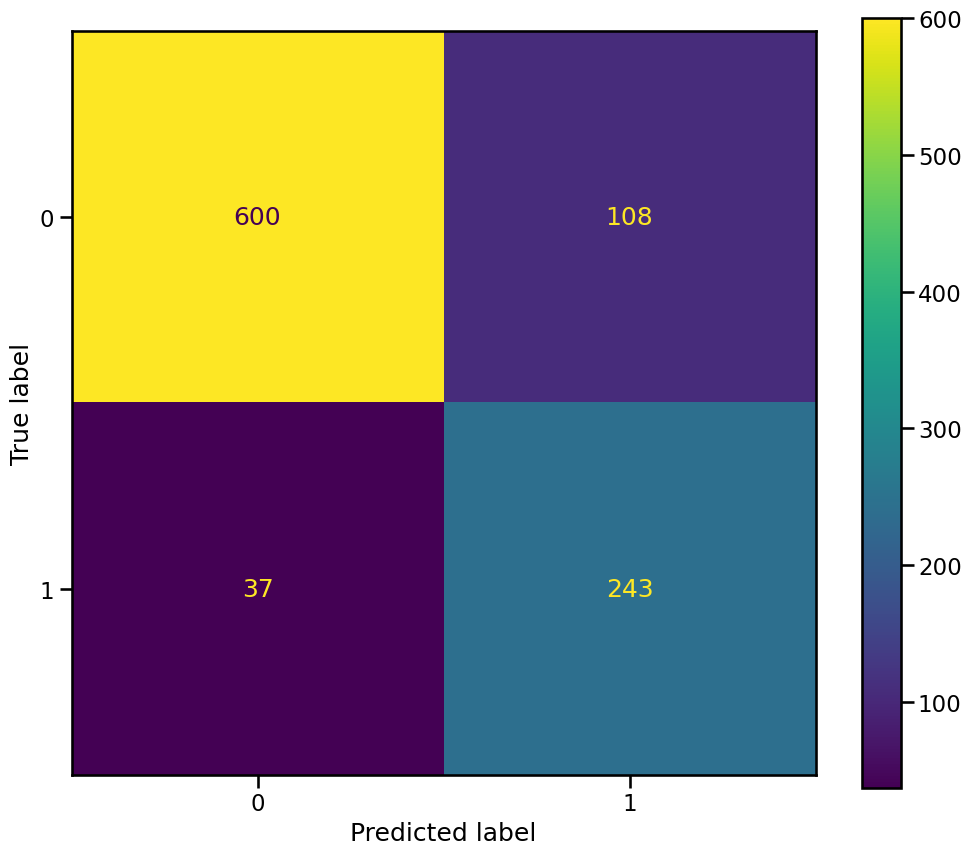

In [24]:
ConfusionMatrixDisplay.from_predictions(y_dev, best_xgb_preds)
print(f"Recall XGB: {recall_score(y_dev,best_xgb_preds)}")
print(f"Recall ANN: {recall_score(y_dev,y_pred_ann_fin)}")
print(f"AUC XGB: {roc_auc_score(y_dev,best_xgb_proba_preds)}")
print(f"AUC TRAIN XGB: {roc_auc_score(y_train,best_xgb.predict_proba(X_train)[:, 1])}")
print(f"AUC ANN: {roc_auc_score(y_dev, test_weighted_predictions_baseline)}")

### Jak widać na wykresie oraz po metrykach najlepszy rezultat z optuny jest najlepszym modelem dotychczas

## Finalne Porównanie Najlepszego modelu ANN oraz XGB

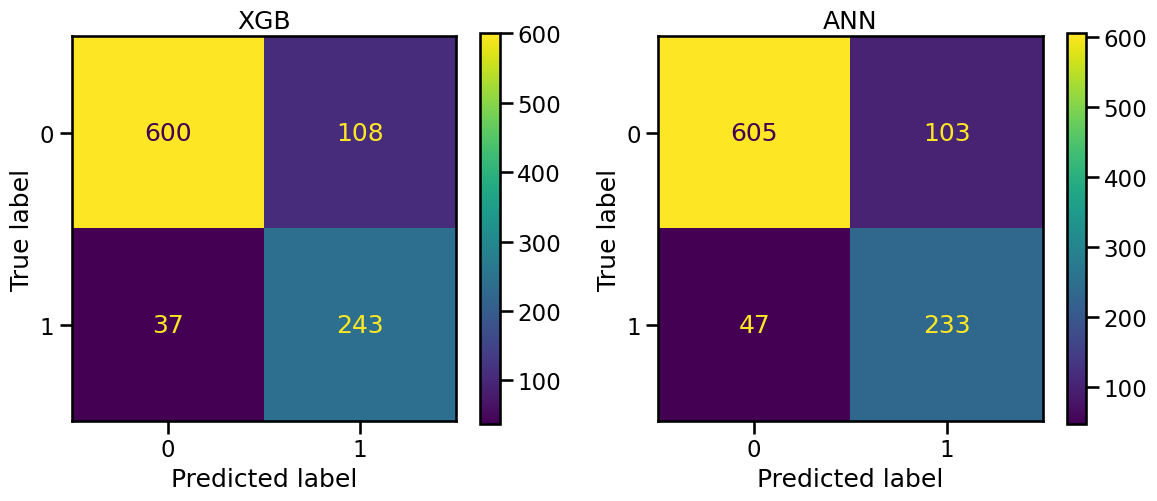

In [752]:
# Tworzymy figurę z dwoma miejscami na wykresy
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Lewy wykres: np. Standardowy próg 0.5
ConfusionMatrixDisplay.from_predictions(y_dev, best_xgb_preds, ax=ax[0])
ax[0].set_title(f"XGB")
ConfusionMatrixDisplay.from_predictions(y_dev, y_pred_ann_fin, ax=ax[1])
ax[1].set_title("ANN")
# Prawy wykres: Krzywa ROC (lepiej oddaje charakter proba niż macierz)
# Tutaj możemy użyć RocCurveDisplay dla best_xgb_preds_proba


plt.tight_layout()
plt.show()

### Porównanie Macierzy Błędów:  ANN vs XGBoost

Szczegółowa analiza porównawcza macierzy błędów (Confusion Matrix) dla obu zoptymalizowanych modeli potwierdza wcześniejsze wnioski płynące z krzywych ROC. Wydajność globalna obu architektur jest do siebie silnie zbliżona, co ostatecznie weryfikuje limit informacyjny zawarty w zbiorze danych.

Weryfikacja bezpośredniego rozkładu predykcji ujawnia jednak subtelną, lecz fundamentalną z punktu widzenia biznesu przewagę algorytmu opartego na drzewach decyzyjnych. Model XGBoost wykazuje wyższą precyzję klasyfikacji na obu krańcach spektrum decyzyjnego:

1. **Klasa większościowa (Klienci lojalni):** XGBoost skuteczniej minimalizuje błędy pierwszego rodzaju (False Positives), trafniej identyfikując użytkowników, którzy nie mają zamiaru rezygnować z usług.
2. **Klasa mniejszościowa (Klienci odchodzący / Churn):** Model wykazuje również wyższą czułość w wychwytywaniu faktycznych rezygnacji (redukcja błędów False Negatives), z większą pewnością typując grupę podwyższonego ryzyka.


> **Wniosek Biznesowy:** Nawet marginalna poprawa precyzji w obu klasach jednocześnie to scenariusz wysoce pożądany operacyjnie. Wybór XGBoosta jako modelu docelowego oznacza podwójny zysk dla przedsiębiorstwa: skuteczniejsze zapobieganie rotacji (dzięki lepszemu wychwytywaniu uciekających klientów) przy jednoczesnej optymalizacji budżetu marketingowego (dzięki unikaniu niepotrzebnego kierowania kosztownych ofert retencyjnych do bezpiecznej bazy użytkowników).

## Optymalizacja Progu Odcięcia (Threshold Tuning)

Kluczowym i ostatecznym etapem kalibracji systemu predykcyjnego jest transformacja ciągłych prawdopodobieństw (zwracanych przez model XGBoost) na twarde decyzje klasyfikacyjne (Churn: 0 lub 1). 

W przypadku problemów charakteryzujących się niezbalansowanym rozkładem klas, przyjmowanie domyślnego progu decyzyjnego na poziomie 0.5 jest podejściem wysoce suboptymalnym. Aby zmaksymalizować użyteczność modelu, próg ten musi zostać dostosowany do specyfiki problemu oraz akceptowalnego kompromisu między precyzją (Precision) a czułością (Recall).



### Zautomatyzowana Ewaluacja Przestrzeni Decyzyjnej

W celu wyznaczenia optymalnego punktu pracy modelu, zaimplementowano zautomatyzowany skrypt oparty na pętli iteracyjnej. Mechanizm ten systematycznie przesuwa próg odcięcia (np. od 0.1 do 0.9), poddając każdą wartość rygorystycznej weryfikacji. 

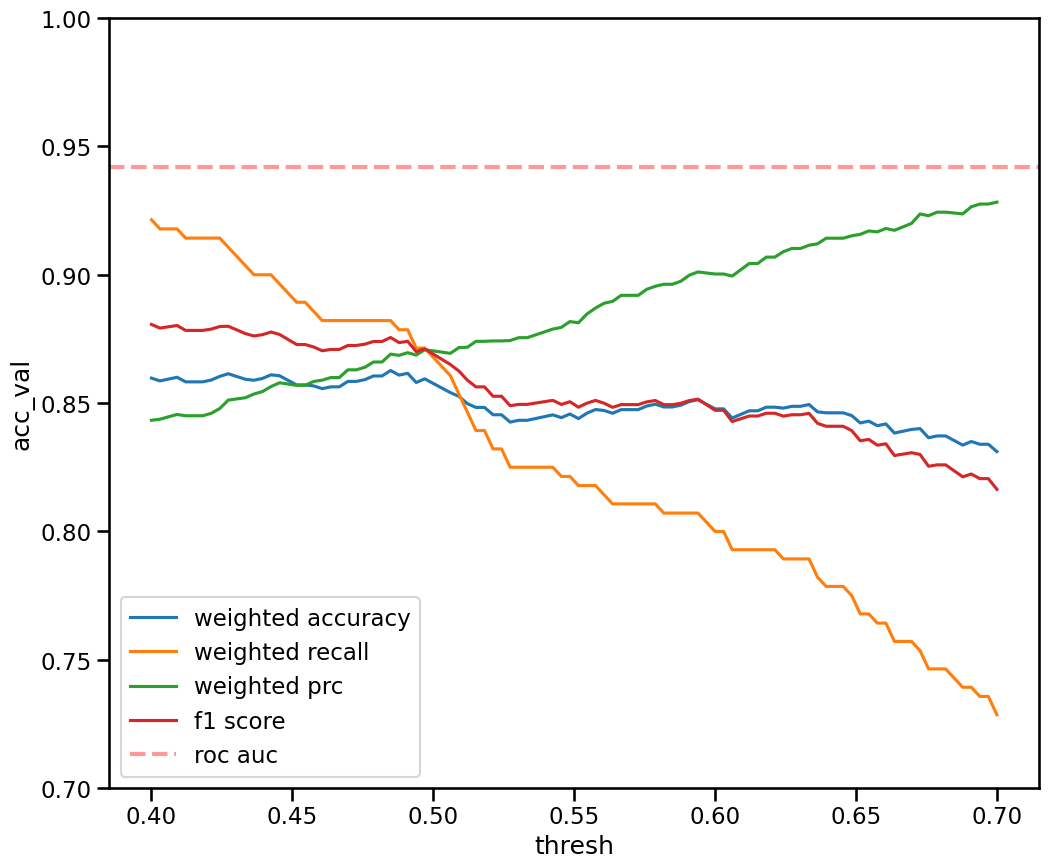

In [25]:

weights = np.where(y_dev == 1, best_xgb_study['scale_pos_weight'], 1.0)
results = []
ac_tab = pd.DataFrame(columns=['thresh','acc_val'])
for i in np.linspace(0.4,0.7,100):
    preds = (best_xgb_proba_preds > i).astype(int)
    acc_score =  balanced_accuracy_score(y_dev, preds, sample_weight=weights)
    recall = recall_score(y_dev, preds, sample_weight=weights)
    prc = precision_score(y_dev, preds, sample_weight=weights)
    f1 = f1_score(y_dev, preds, sample_weight=weights)
    results.append({'thresh': i, 
                    'acc_val' : acc_score,
                    'recall': recall,
                    'prc': prc,
                    'f1_score': f1})
    
ac_tab = pd.DataFrame.from_dict(results)

sns.lineplot(ac_tab, x ='thresh',y = 'acc_val', label = 'weighted accuracy')
sns.lineplot(ac_tab, x ='thresh',y = 'recall', label = 'weighted recall')
sns.lineplot(ac_tab, x ='thresh',y = 'prc', label = 'weighted prc')
sns.lineplot(ac_tab, x ='thresh',y = 'f1_score', label = 'f1 score')
plt.axhline(
    roc_auc_score(y_dev, best_xgb_proba_preds, sample_weight=weights), 
    label='roc auc', 
    ls='--', 
    color='red', 
    lw=3,
    alpha = 0.4
)
plt.ylim(0.7,1)
plt.legend()


In [28]:
ac_tab.sort_values(by = 'acc_val', ascending=False).head()

,thresh,acc_val,recall,prc,f1_score
28,0.484848,0.862682,0.882143,0.869067,0.875556
30,0.490909,0.861602,0.878571,0.869634,0.874080
9,0.427273,0.861431,0.910714,0.851168,0.879935
14,0.442424,0.861017,0.900000,0.856439,0.877679
29,0.487879,0.860896,0.878571,0.868605,0.873560


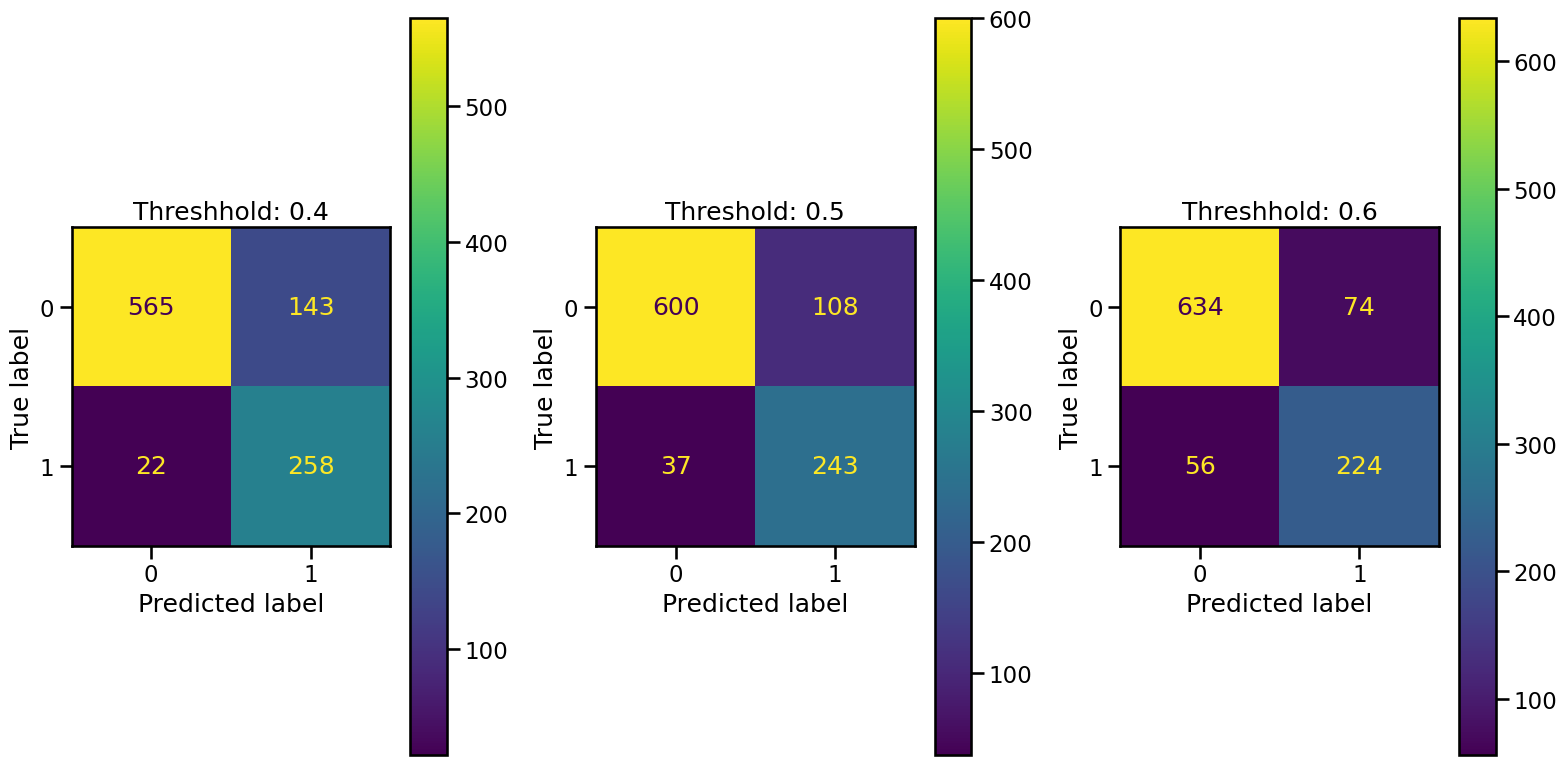

In [932]:
# Tworzymy figurę z dwoma miejscami na wykresy
fig, ax = plt.subplots(1, 3, figsize=(16, 8))

# Lewy wykres: np. Standardowy próg 0.5
ConfusionMatrixDisplay.from_predictions(y_dev, best_xgb_preds, ax=ax[1])
ax[1].set_title(f"Threshold: 0.5")
test_tresh_preds_06 = (best_xgb_proba_preds > 0.6).astype(int)
ConfusionMatrixDisplay.from_predictions(y_dev, test_tresh_preds_06, ax=ax[2])
ax[2].set_title(f"Threshhold: 0.6")
test_tresh_preds_04 = (best_xgb_proba_preds > 0.4).astype(int)
ConfusionMatrixDisplay.from_predictions(y_dev, test_tresh_preds_04, ax=ax[0])
ax[0].set_title(f"Threshhold: 0.4")
# Prawy wykres: Krzywa ROC (lepiej oddaje charakter proba niż macierz)
# Tutaj możemy użyć RocCurveDisplay dla best_xgb_preds_proba


plt.tight_layout()
plt.show()

## Strategia Biznesowa: Analiza Scenariuszy i Wybór Progu Odcięcia

Zdolność modelu do separacji klas na poziomie AUC rzędu 0.94 potwierdza jego wysoką skuteczność analityczną. Jednak to ostateczna decyzja o punkcie odcięcia (Threshold) determinuje rzeczywisty kształt kampanii retencyjnej i jej opłacalność. 

Poniżej zdefiniowano trzy główne scenariusze operacyjne, uzależnione od relacji między kosztem pozyskania nowego klienta (CAC - Customer Acquisition Cost) a kosztem jego utrzymania (CRC - Customer Retention Cost).

### Analiza Wariantów Decyzyjnych

* **Próg 0.4 (Strategia Agresywnej Retencji):**
  Priorytetem jest maksymalizacja czułości (Recall) i wyłapanie niemal wszystkich klientów planujących odejście. Akceptowanym kosztem operacyjnym jest spadek precyzji – około 35% użytkowników wytypowanych przez system stanowiliby klienci lojalni (False Positives), którzy otrzymaliby niepotrzebny rabat.
  *Zastosowanie biznesowe:* Optymalne rozwiązanie w sytuacji, gdy koszt pozyskania nowego abonenta drastycznie przewyższa koszt przyznania zniżki obecnemu.
  

* **Próg 0.6 (Strategia Konserwatywna):**
  Faworyzowanie wysokiej precyzji kosztem pominięcia części odchodzących klientów (spadek Recall). System typuje do kampanii wyłącznie przypadki o najwyższym prawdopodobieństwie rezygnacji.
  *Zastosowanie biznesowe:* Scenariusz uzasadniony ekonomicznie, gdy budżet na działania retencyjne jest mocno ograniczony, a koszt zastąpienia klienta nowym jest niższy niż koszt oferowanych benefitów utrzymaniowych.
  

* **Próg 0.5 (Złoty Środek - Strategia Zbalansowana):**
  Kompromis pomiędzy agresywną obroną bazy klientów a precyzją alokacji budżetu marketingowego.

### Ostateczna Decyzja i Uzasadnienie Matematyczne

Podjęto ostateczną decyzję o implementacji progu odcięcia na poziomie **0.5**. 

Wybór ten nie jest przypadkowy. Jak wykazuje analiza krzywych ewaluacyjnych, to właśnie ten punkt pracy maksymalizuje globalną wartość **ważonej dokładności (Weighted Accuracy)**. Gwarantuje to optymalny balans pomiędzy precyzją a czułością, tworząc stabilne, gotowe do wdrożenia narzędzie, które skutecznie chroni przychody firmy, nie generując przy tym nieuzasadnionych strat na nietrafionych ofertach promocyjnych.

## Otwarcie Czarnej Skrzynki: Zrozumienie Procesu Decyzyjnego

Text(0.5, 1.0, '10 najistotniejszych zmiennych w modelu XGboost')

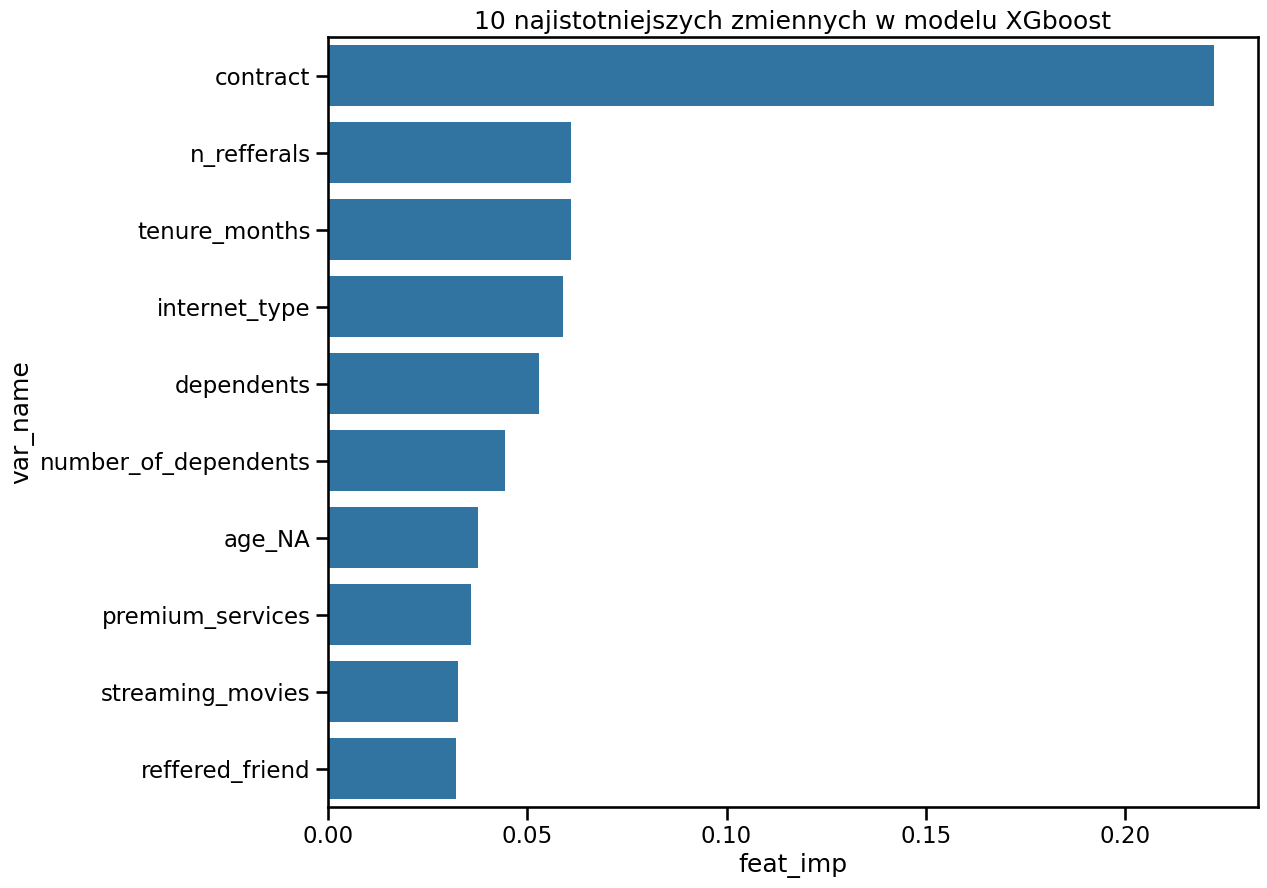

In [31]:
xgb_model = best_xgb.named_steps['classifier']
xgb_feat_imps = xgb_model.feature_importances_
nams = X_train_proc.columns
feat_imps = pd.DataFrame(data = [nams, xgb_feat_imps], index=['var_name','feat_imp']).T.sort_values(by = 'feat_imp', ascending=False)
sns.barplot(feat_imps.head(10),  x = 'feat_imp', y = 'var_name')
plt.title('10 najistotniejszych zmiennych w modelu XGboost')

### Globalna Analiza Istotności Cech (XGBoost Feature Importance)

Pierwszym krokiem w kierunku otwarcia "czarnej skrzynki" jest weryfikacja globalnej ważności cech (Feature Importance), wygenerowanej natywnie przez algorytm XGBoost (w oparciu o metryki takie jak *Gain* lub *Weight* przy podziałach węzłów).

Wyniki tej analizy dostarczają niezwykle silnego, pozytywnego sygnału o poprawności procesu modelowania. Hierarchia zmiennych wytypowanych przez model w 100% pokrywa się z wnioskami wyciągniętymi na etapie Eksploracyjnej Analizy Danych (EDA). Wszystkie 10 najistotniejszych cech to dokładnie te same zmienne, które w najbardziej wyraźny sposób stratyfikowały portfel klientów podczas wstępnej analizy eksploracyjnej.



**Kluczowe predyktory decydujące o Churnie:**

* **Typ umowy (`contract`):** Bezdyskusyjnie najsilniejsza zmienna w całym zestawie danych. Stanowi to bezpośrednie matematyczne odzwierciedlenie faktu zidentyfikowanego w EDA: około 90% wszystkich rezygnacji w historycznym portfelu generowali klienci posiadający elastyczne kontrakty odnawialne co miesiąc (Month-to-Month).
* **Liczba poleceń (Referrals):** Cecha ta pełni w modelu funkcję silnego wskaźnika zastępczego (proxy) dla satysfakcji i lojalności. Zgodnie z intuicją biznesową, promotorzy marki, którzy aktywnie polecają usługi w swoim otoczeniu, wykazują drastycznie mniejszą skłonność do migracji do konkurencji.
* **Długość współpracy (Tenure) oraz Typ Internetu:** Kolejne kluczowe filary decyzyjne drzew. Wskazują one, że stabilność relacji z klientem oraz technologia dostarczanego łącza są krytycznymi czynnikami wpływającymi na jego żywotność w sieci.

#### Ograniczenia Tradycyjnej Metody i Przejście do SHAP

Natywna analiza ważności cech w drzewach decyzyjnych posiada jednak pewne ograniczenie: informuje nas, *jak bardzo* dana zmienna była użyteczna przy podziałach, ale nie mówi nam precyzyjnie, *w jakim kierunku* i z jaką siłą konkretna wartość tej zmiennej przesuwa ostateczną predykcję. 
Aby w pełni zrozumieć mechanikę działania modelu i wyposażyć biznes w rekomendacje z dokładnością co do pojedynczego klienta, w kolejnym kroku przeprowadzona zostanie zaawansowana analiza oparta na teorii gier – **wartości Shapleya (SHAP)**.

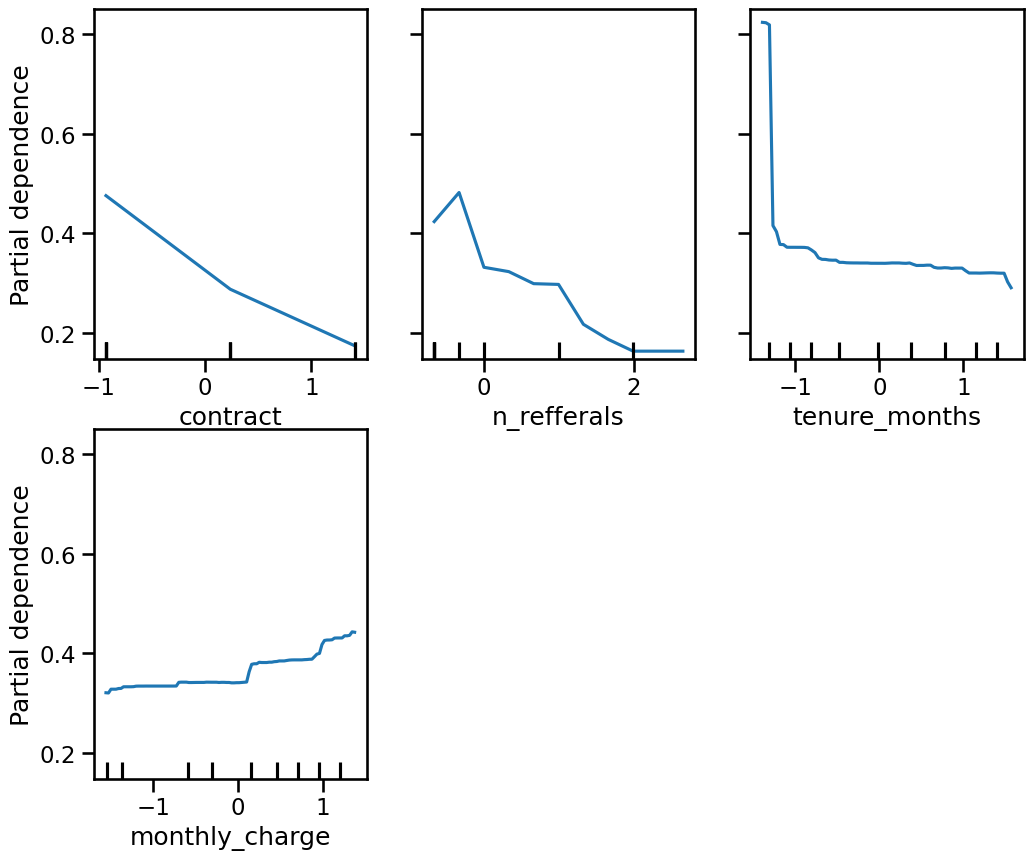

In [33]:
colnames = [*X_dev_proc.columns,]
pdp_ids = [colnames.index('contract'), colnames.index('n_refferals'),colnames.index('tenure_months'), colnames.index('monthly_charge'), ]
pdp_names = ['contract', 'n_refferals', 'tenure_months', 'monthly_charge']
pdp_ids = []
for i in pdp_names: 
    pdp_ids.append(colnames.index(i))
    
PartialDependenceDisplay.from_estimator(
    xgb_model, 
    X_dev_proc, 
    features=pdp_ids,
    feature_names=colnames,
    kind='average' # lub 'both' dla PDP + ICE
)


## Analiza Częściowej Zależności (PDP)

Aby precyzyjnie zrozumieć kierunek oraz siłę wpływu kluczowych predyktorów na decyzje algorytmu XGBoost, wygenerowano Wykresy Częściowej Zależności (Partial Dependence Plots). Metoda ta pozwala na wyizolowanie wpływu pojedynczej zmiennej na przewidywane prawdopodobieństwo rezygnacji klienta (Churn), przy jednoczesnym uśrednieniu efektów pozostałych cech.

Analiza profili dla najważniejszych zmiennych decyzyjnych dostarcza następujących, jednoznacznych wniosków biznesowych:

* **Typ Umowy (Contract):** Zaobserwowano silnie opadający trend. Im dłuższy horyzont czasowy kontraktu (przejście z umów miesięcznych na roczne lub dwuletnie), tym drastycznie spada marginalne prawdopodobieństwo odejścia klienta. Model traktuje długoterminowe zobowiązanie jako najsilniejszy bufor bezpieczeństwa.
* **Liczba Poleceń (Number of Referrals):** Zależność jest odwrotnie proporcjonalna. Z każdym kolejnym poleceniem wygenerowanym przez użytkownika, przewidywane ryzyko odejścia maleje. Potwierdza to, że zaangażowanie klienta w programy afiliacyjne buduje wysoką lojalność wobec marki.
* **Staż Klienta (Tenure in Months):** Wykres wykazuje negatywną korelację z ryzykiem rezygnacji. Wraz z upływem kolejnych miesięcy współpracy, krzywa prawdopodobieństwa odejścia systematycznie opada, stabilizując się dla klientów wieloletnich.
* **Miesięczne Opłaty (Monthly Charge):** Jest to jedyna z analizowanych w tym zestawieniu zmiennych o wektorze dodatnim. Wykres wyraźnie pnie się w górę wraz ze wzrostem miesięcznego rachunku. Oznacza to, że klienci wysokomarżowi (płacący najwyższe abonamenty) są jednocześnie najbardziej wrażliwi na ofertę konkurencji i wykazują największą skłonność do migracji. Wniosek ten potwierdza hipotezy z etapu eksploracji

> **Rekomendacja Operacyjna:** Powyższe trendy stanowią gotowy fundament do budowy matrycy działań retencyjnych. Dział utrzymania klienta powinien priorytetyzować kampanie zachęcające do zmiany umów miesięcznych na długoterminowe, a także proaktywnie monitorować segment klientów o najwyższych rachunkach miesięcznych, oferując im pakiety lojalnościowe zanim ci zgłoszą chęć odejścia.

In [796]:
X_train_shap = X_train_proc.astype(float)
X_dev_shap = X_dev_proc.astype(float)
xgb_explainer = shap.Explainer(xgb_model.predict, X_train_shap)
shap_values = xgb_explainer.shap_values(X_dev_shap)


PermutationExplainer explainer: 989it [00:27, 28.59it/s]                         


In [797]:
shap.plots.initjs()

/var/folders/d2/1zkn182s18l4sf2dw4m2nj880000gn/T/ipykernel_39245/489765813.py:1: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



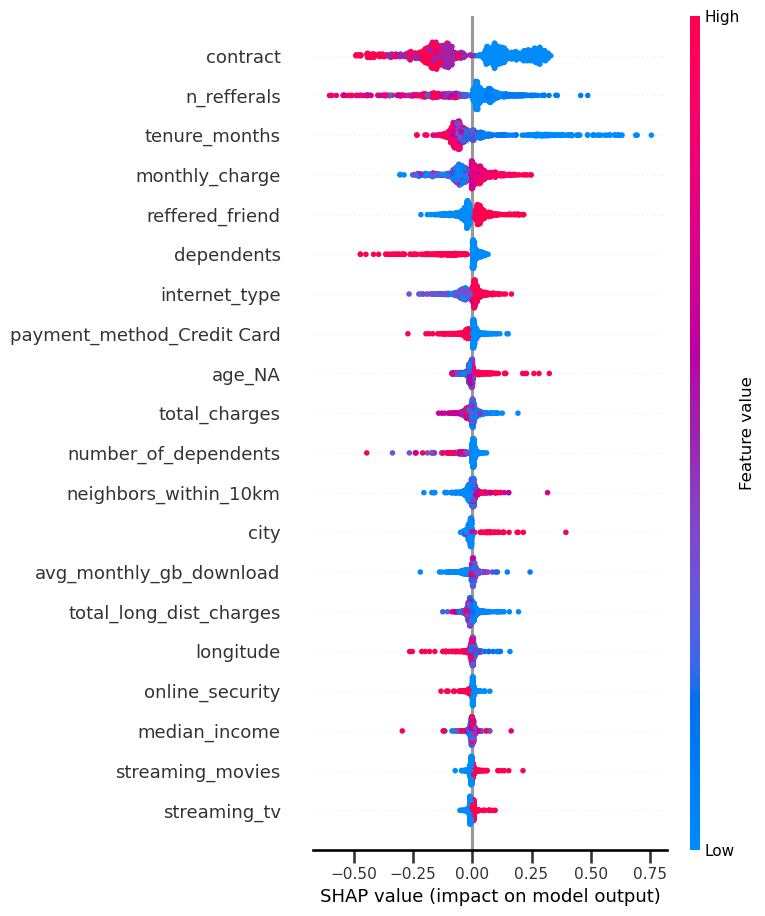

In [822]:
shap.summary_plot(shap_values, X_dev_shap)

## Interpretowalność Modelu: Wartości Shapleya (SHAP Summary Plot)

Aby uzyskać pełny wgląd w to, jak model podejmuje decyzje na poziomie poszczególnych klientów, zastosowano zaawansowaną metodę interpretacji opartą na teorii gier – SHAP (SHapley Additive exPlanations). 

Wykres podsumowujący (Summary Plot) dostarcza nam wielowymiarowego spojrzenia na proces decyzyjny algorytmu XGBoost. W przeciwieństwie do standardowej weryfikacji ważności cech, SHAP pozwala na jednoczesną ocenę wagi zmiennej, kierunku jej wpływu oraz rozkładu tych wartości w całej populacji.

### Weryfikacja Hipotez i Wnioski Biznesowe

Analiza rozkładu wartości SHAP dla najważniejszych kryteriów decyzyjnych w pełni pokrywa się z wnioskami wyciągniętymi na wcześniejszym etapie Eksploracyjnej Analizy Danych (EDA), co stanowi ostateczne potwierdzenie trafności postawionych tam hipotez. 

Szczegółowa inspekcja wykresu ujawnia precyzyjne mechanizmy obniżające ryzyko odejścia:

* **Typ Umowy (Contract):** Potwierdza się dominująca rola tego predyktora. Zgodnie z rozkładem kolorów i wartości na osi X, posiadanie umów długoterminowych drastycznie przesuwa predykcję w lewą stronę (wartości ujemne SHAP), stanowiąc najsilniejszy bufor chroniący przed odejściem klienta. 
* **Liczba Poleceń (Number of Referrals):** Klienci charakteryzujący się wysoką wartością tej cechy (oznaczeni na czerwono) systematycznie grupują się po lewej stronie osi zerowej. Oznacza to, że sam fakt polecenia usługi wprost przekłada się na redukcję prawdopodobieństwa rezygnacji.
* **Staż i Zależności (Tenure Months oraz Dependents):** Analogiczny, silnie stabilizujący wpływ wykazuje długość trwania relacji z operatorem oraz posiadanie osób zależnych na koncie (np. pakietów rodzinnych). Wysokie wartości tych cech istotnie popychają predykcję w dół, kategoryzując takich użytkowników jako bezpieczny, lojalny rdzeń bazy abonenckiej.

> **Podsumowanie Analityczne:** Model XGBoost nie wygenerował sztucznych, pozbawionych sensu reguł. Jego aparat matematyczny wyodrębnił i nadał precyzyjne wagi dokładnie tym zjawiskom, które od początku wskazywały na silną stratyfikację portfela. Daje to biznesowi gwarancję, że model jest logiczny, interpretowalny i gotowy do bezpiecznego wdrożenia produkcyjnego.

## Analiza Błędów Modelu (Error Analysis): Zrozumienie Ograniczeń

Niezwykle ważnym, a jednocześnie jednym z najczęściej pomijanych etapów w cyklu życia projektu uczenia maszynowego, jest ranaliza błędów modelu (Error Analysis). Wielu analityków kończy pracę w momencie osiągnięcia satysfakcjonującej metryki globalnej (jak wypracowane AUC na poziomie 0.94), ignorując fakt, że to właśnie błędnie sklasyfikowane przypadki kryją w sobie najwięcej informacji o fizycznych ograniczeniach systemu oraz jakości samych danych.

Zamiast traktować pomyłki algorytmu wyłącznie jako akceptowalny statystyczny margines, w tej sekcji poddajemy je inżynieryjnej dekonstrukcji. Naszym celem jest zidentyfikowanie wzorców w obszarach przestrzeni cech, w których zoptymalizowany model XGBoost podejmuje błędne decyzjeF

In [ ]:
preprocessor_temp = preprocessor()[:-1] # Wycięcie fragmentu pipeline bez scalingu
preprocessor_temp = clone(preprocessing_pipeline)
preprocessor_temp = preprocessor_temp[:-1] # Preprocessor bez scalingu dla lepszej analizy wyników 
preprocessor_temp.fit(X_train, y_train)
ea_set = preprocessor_temp.transform(X_dev).loc[:,X_dev_proc.columns]

In [38]:
ea_set['prediction'] = best_xgb_preds
ea_set['pred']= np.where(ea_set['prediction']!=y_dev,'missed','ok')
ea_set['pred_proba'] = best_xgb_proba_preds

Text(0.5, 1.0, 'wśród błędnych predykcji')

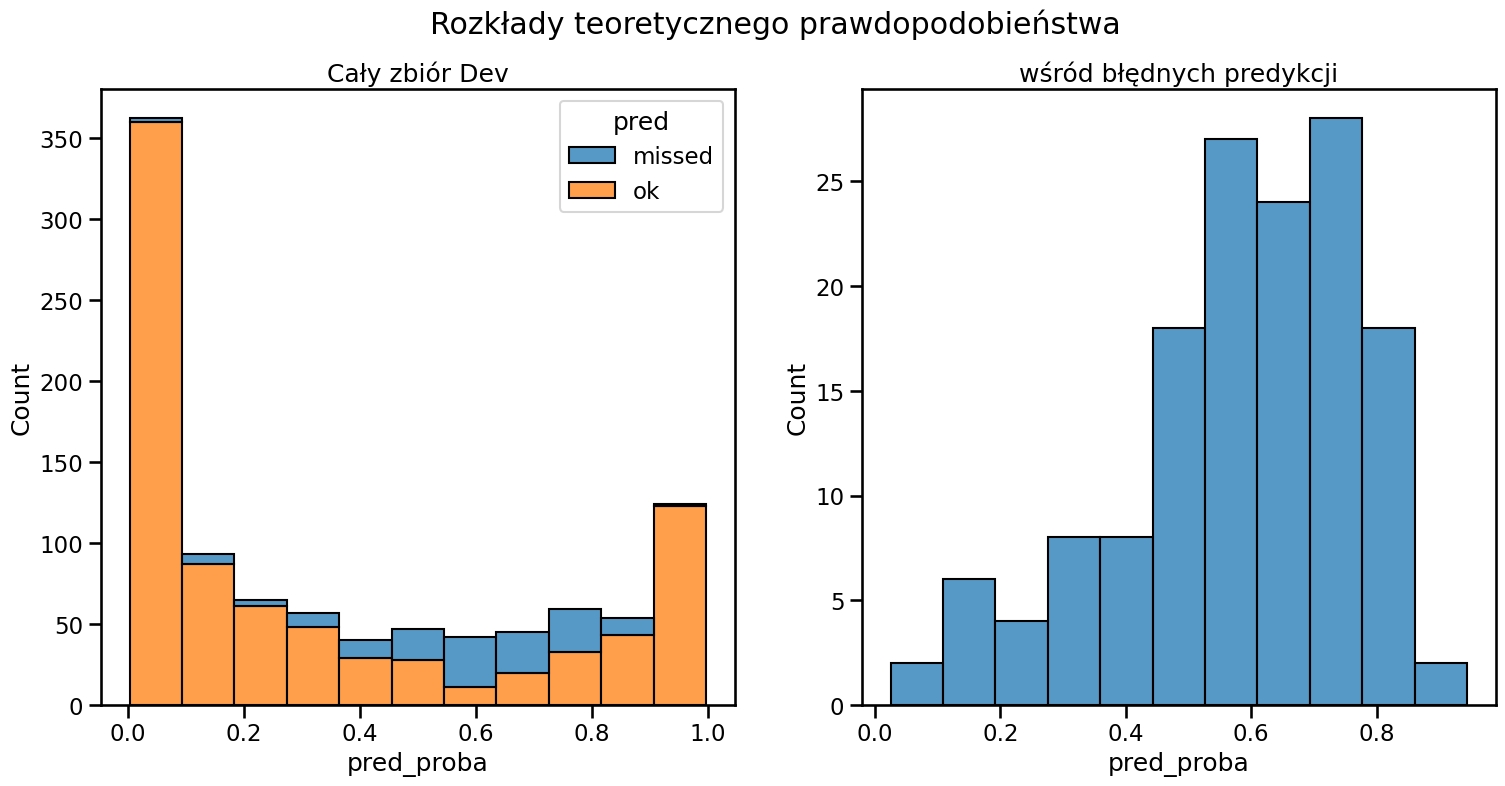

In [60]:
fig, ax = plt.subplots(nrows=1,ncols=2,figsize = (18,8))
fig.suptitle('Rozkłady teoretycznego prawdopodobieństwa')
sns.histplot(data = ea_set, x = 'pred_proba',hue='pred', multiple = 'stack',ax=ax[0])
ax[0].set_title('Cały zbiór Dev')
sns.histplot(data = ea_set[ea_set['pred'] == 'missed'], x = 'pred_proba',ax=ax[1])
ax[1].set_title('wśród błędnych predykcji')

### Analiza Rozkładu Prawdopodobieństw (Prediction Confidence)

Aby dogłębnie zrozumieć jakość predykcji wykraczającą poza standardowe metryki punktowe, przeprowadzono wizualną inspekcję rozkładu prawdopodobieństw zwracanych przez zoptymalizowany model XGBoost. Wykres ten zestawia stopień "pewności" algorytmu z rzeczywistą przynależnością obserwacji do danej klasy (Ground Truth).

Analiza histogramów ujawnia fundamentalne wzorce w procesie wnioskowania modelu:

* **Strefy Wysokiej Pewności (Skrajne krańce rozkładu):** Zdecydowana większość predykcji grupuje się w bliskich okolicach wartości 0.0 oraz 1.0. Obecność wysokich, jednorodnych słupków w tych obszarach świadczy o doskonałej kalibracji modelu w przypadkach ewidentnych. Kiedy algorytm jest matematycznie "pewny", że klient pozostanie (blisko 0) lub zrezygnuje z usług (blisko 1), jego predykcje są niemal bezbłędne. Oznacza to, że silny sygnał w danych jest przez XGBoost odczytywany bez zakłóceń.

* **Strefa Największej Niepewności (Zakres 0.4 - 0.7):** Zgodnie z oczekiwaniami teoretycznymi, najsłabszym ogniwem klasyfikatora jest środkowe pasmo prawdopodobieństw (otoczenie granicy decyzyjnej). W przedziale między 0.4 a 0.7 model wykazuje największe wahanie, a rozkłady klas zaczynają się przenikać. To właśnie w tym obszarze system generuje najwięcej błędów typu False Positive oraz False Negative. Klienci trafiający do tej strefy posiadają mieszany profil behawioralny – wykazują cechy zarówno lojalnych użytkowników, jak i tych skłonnych do rotacji (szum informacyjny).

> **Rekomendacja Operacyjna:** Identyfikacja "strefy niepewności" (0.4 - 0.7) otwiera możliwość wdrożenia warstwowej strategii biznesowej. Dla klientów z prawdopodobieństwem > 0.7 można zautomatyzować przyznawanie drogich, agresywnych rabatów retencyjnych. Natomiast segment z przedziału 0.4 - 0.7, gdzie model często się myli, może zostać skierowany do weryfikacji manualnej przez dedykowanego konsultanta lub objęty tańszą, zachowawczą kampanią marketingową.

In [39]:

X_tsne = TSNE(
    learning_rate=100,               # Szybkość uczenia - niska wartość zapobiega "rozrywaniu" klastrów
    perplexity=10,                  # Liczba sąsiadów branych pod uwagę (równowaga między lokalną a globalną strukturą)
    verbose=1,                      # Wyświetlanie postępu obliczeń w konsoli
    max_iter=5000,                 # Maksymalna liczba iteracji dla uzyskania stabilnego układu punktów
    n_iter_without_progress=100,    # Warunek stopu, jeśli algorytm przestanie optymalizować układ
    n_jobs=-1,                      # Używanie wszystkich rdzeni procesora
    random_state=RANDOM_STATE,      # Zapewnienie powtarzalności rzutu (mapy) - Ustawione dopiero po wielokrotnym testowaniu różnych wartości, 
    init = 'pca'
).fit_transform(X_dev_proc)
ea_set['tsne_0'] = X_tsne['tsne0']
ea_set['tsne_1'] = X_tsne['tsne1']


[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 988 samples in 0.000s...
[t-SNE] Computed neighbors for 988 samples in 0.107s...
[t-SNE] Computed conditional probabilities for sample 988 / 988
[t-SNE] Mean sigma: 1.778936
[t-SNE] KL divergence after 250 iterations with early exaggeration: 78.568352
[t-SNE] KL divergence after 5000 iterations: 1.360460


In [42]:
color_map = {
    'ok': "#6185A1",  
    'missed': '#FF0000'   
   
}

fig = px.scatter(
    ea_set,
    x='tsne_0',
    y='tsne_1',
    color='pred',          
    color_discrete_map=color_map,
    title="Wizualizacja t-SNE: Błędy modelu, na dev set",
    opacity=0.7,                 
    height=1000,
    width=1200 
)


fig.update_traces(marker=dict(size=5)) 

fig.show()

### Przestrzenna Analiza Błędów: Redukcja Wymiarowości (t-SNE)

W celu pogłębionej weryfikacji obszarów, w których system podejmuje błędne decyzje klasyfikacyjne, zastosowano algorytm t-SNE (t-Distributed Stochastic Neighbor Embedding). Technika ta pozwoliła na nieliniową redukcję wielowymiarowej przestrzeni cech do rzutu dwuwymiarowego, umożliwiając wizualną ocenę topologii błędów (obserwacji typu False Positive oraz False Negative) na tle całej populacji zbioru walidacyjnego.



Wizualna inspekcja wygenerowanego rzutu dostarcza kluczowych informacji diagnostycznych. Punkty reprezentujące błędne predykcje nie tworzą wyraźnych, wyizolowanych skupisk, lecz są rozproszone relatywnie równomiernie po całej zredukowanej przestrzeni danych.

> **Wniosek Analityczny i Rozwojowy (Next Steps):** > Brak gęstych "skupisk błędu" to wysoce pozytywny sygnał inżynieryjny. Oznacza on, że zoptymalizowany model XGBoost nie posiada systematycznych "ślepych plam" w procesie wnioskowania – nie pomija specyficznego, spójnego segmentu klientów z powodu braku kluczowego predyktora. 
> 
> Błędy wynikają głównie z naturalnego szumu informacyjnego oraz trudności z jednoznaczną klasyfikacją przypadków granicznych w rzadko reprezentowanych obszarach przestrzeni cech. Daje to solidne podstawy do optymizmu w kontekście skalowania projektu: głównym wąskim gardłem obecnego rozwiązania jest wyłącznie obiektywny brak gęstości danych. Systematyczne powiększanie historycznego zbioru treningowego (np. logowanie zachowań klientów przez kolejne kwartały) powinno bezpośrednio przełożyć się na zagęszczenie przestrzeni i naturalną poprawę metryk modelu w kolejnych iteracjach.

## Analiza Skupień i Segmentacja: Profilowanie Błędów Modelu

Aby jeszcze lepiej zinterpretować zachowanie modelu i zlokalizować jego potencjalne słabe punkty, wyciągnięto wnioski z poprzedniej analizy (t-SNE) i przeniesiono weryfikację błędów na wyższy poziom abstrakcji. Zdecydowano się na przeprowadzenie segmentacji klientów przy użyciu nienadzorowanej analizy skupień.

Celem tego etapu jest podzielenie całej populacji na homogeniczne grupy (skupiające klientów o bardzo podobnym profilu behawioralnym i demograficznym), a następnie sprawdzenie, czy istnieją konkretne segmenty, w których nasz model XGBoost myli się systematycznie częściej niż w innych.



### Wybór Metodologii: Algorytm K-Prototypes

Do przeprowadzenia segmentacji wybrano algorytm **K-Prototypes**. Jest to celowa decyzja architektoniczna. Standardowe metody, takie jak K-Means, opierają się na dystansie euklidesowym i są przeznaczone wyłącznie dla zmiennych ciągłych. Nasz zbiór danych ma charakter wysoce mieszany (zawiera zarówno zmienne numeryczne, np. miesięczne opłaty, jak i liczne zmienne kategoryczne, np. typ umowy czy rodzaj internetu). 

K-Prototypes rozwiązuje ten problem, łącząc dystans euklidesowy dla cech liczbowych z miarą dopasowania (matching dissimilarity) dla cech kategorycznych.

**Założenia analityczne eksperymentu:**
1. **Wyodrębnienie profili:** Podział bazy klientów na logiczne biznesowo segmenty (np. "Lojalne rodziny z długimi umowami", "Młodzi dorośli na elastycznych kontraktach").
2. **Ewaluacja wewnątrzgrupowa:** Obliczenie metryk błędów (False Positives, False Negatives) niezależnie dla każdego z wyznaczonych klastrów.

> **Wartość Biznesowa:** Zidentyfikowanie konkretnego segmentu klientów, dla którego model radzi sobie zauważalnie gorzej, pozwala na wdrożenie precyzyjnych działań naprawczych. Jeśli algorytm myli się np. głównie w segmencie "nowych klientów bez usług dodatkowych", biznes zyskuje jasną informację, że do automatycznej obsługi tej konkretnej grupy należy podchodzić z większą ostrożnością.

In [40]:
cat_columns = ['internet_type', 'dependents', 'reffered_friend', 'premium_support',
       'multiple_lines', 'online_security', 'online_backup',
       'device_prot_plan', 'streaming_tv', 'streaming_movies',
       'paperless_billing', 'contract', 'payment_method_Bank Withdrawal',
       'payment_method_Credit Card', 'payment_method_Mailed Check',
       'missing_age_NA', 'missing_median_income',
       'refund_present', 'city', 'offer', 'outlier_label', 'age_NA',
       'premium_services', 'senior', ]

cat_indices = [i for i, col in enumerate(X_dev_proc.columns) if col in cat_columns]
# 3. Inicjalizacja i dopasowanie modelu
# n_clusters to Twoja liczba skupień
kproto = KPrototypes(n_clusters=5, init='Cao', verbose=1, random_state=42,max_iter=100)
clusters = kproto.fit_predict(X_dev_proc, categorical=cat_indices)
ea_set['cluster'] = clusters
ea_set['true_val'] = y_dev



Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/1000, moves: 369, ncost: 14010.56459000142
Run: 1, iteration: 2/1000, moves: 214, ncost: 13324.531422233482
Run: 1, iteration: 3/1000, moves: 126, ncost: 13038.070144828607
Run: 1, iteration: 4/1000, moves: 82, ncost: 12886.693523250116
Run: 1, iteration: 5/1000, moves: 49, ncost: 12823.307769496229
Run: 1, iteration: 6/1000, moves: 12, ncost: 12819.024980037479
Run: 1, iteration: 7/1000, moves: 4, ncost: 12818.63252460799
Run: 1, iteration: 8/1000, moves: 0, ncost: 12818.63252460799
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/1000, moves: 439, ncost: 13567.470427652348
Run: 2, iteration: 2/1000, moves: 171, ncost: 13272.863972430236
Run: 2, iteration: 3/1000, moves: 68, ncost: 13228.74206595193
Run: 2, iteration: 4/1000, moves: 34, ncost: 13193.4249375354

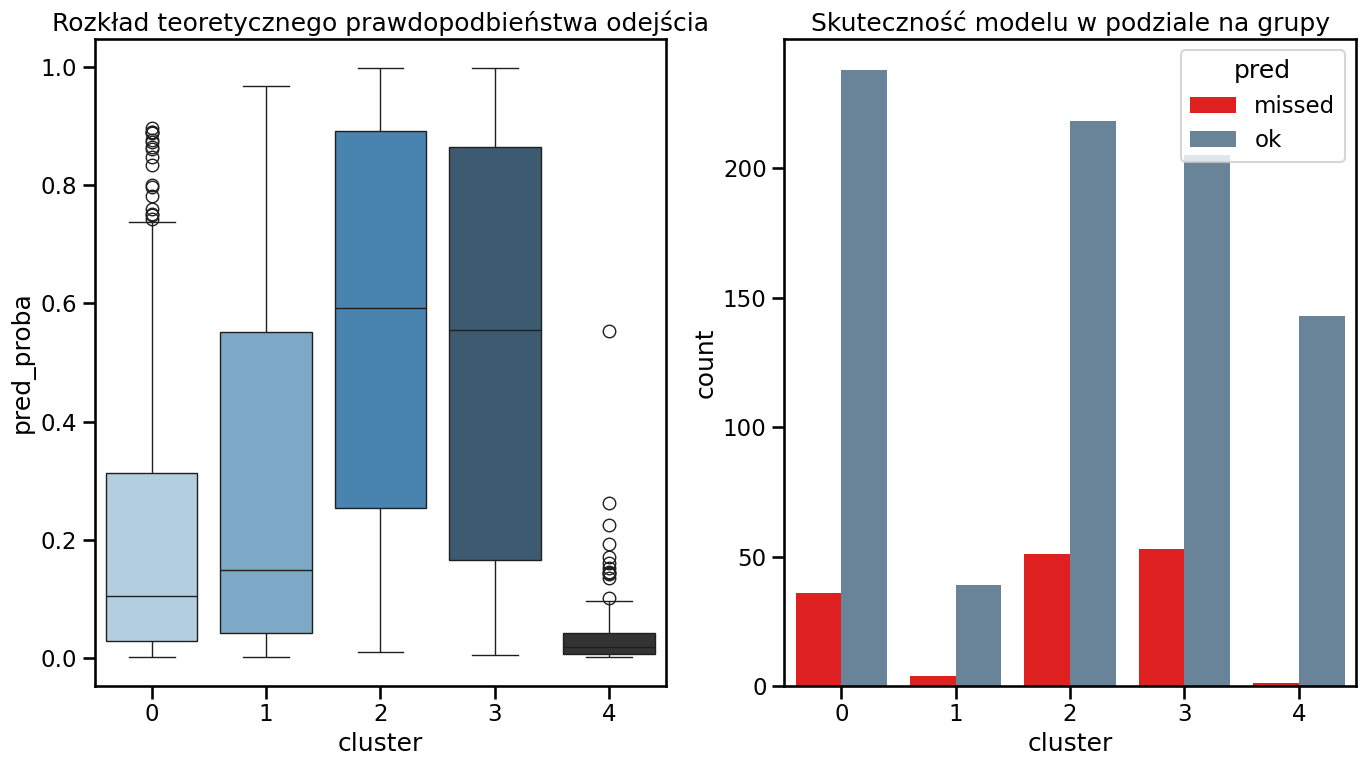

In [43]:
fig, ax = plt.subplots(ncols=2, nrows =1, figsize=(14,8))

sns.boxplot(data = ea_set,  y= 'pred_proba',x = 'cluster', hue= 'cluster',palette='Blues_d', ax=ax[0],legend=False)
ax[0].set_title('Rozkład teoretycznego prawdopodbieństwa odejścia')
sns.countplot(data=ea_set, x='cluster', hue='pred', palette=color_map,ax=ax[1])
ax[1].set_title('Skuteczność modelu w podziale na grupy')


plt.tight_layout()

### Ewaluacja Predykcji w Podziale na Segmenty (Cluster Analysis)

Zestawienie wygenerowanych klastrów z rozkładem predykowanego przez model prawdopodobieństwa dostarcza fundamentalnych informacji o strukturze błędów. Analiza ujawnia wyraźne różnice w pewności decyzyjnej algorytmu XGBoost w zależności od profilu przypisanego klienta.



Szczegółowa inspekcja rozkładów wewnątrz wyodrębnionych skupień prowadzi do następujących wniosków analitycznych:

* **skupienie 4(Wysoka pewność, ekstremalnie niska rotacja):** Skupienie to charakteryzuje się najbardziej skoncentrowanym rozkładem. Model estymuje predykcje dla tej grupy niemal wyłącznie w bardzo bliskim otoczeniu zera. Zestawienie tego faktu ze skutecznością per skupienie dowodzi, że algorytm ma tu rację niemal w 100% przypadków. Reprezentuje to specyficzną, wysoce lojalną grupę klientów, u których ryzyko rezygnacji z usług jest marginalne.
* **skupienie 1 (Wysoka pewność, niska liczebność):** Skupienie to cechuje się podobnie niskim odsetkiem błędów jak skupienie czwarte. Podstawową różnicą jest to, że jest mało liczne oraz posiada mniej skoncentrowany rozkład przewidywanego prawdopodobieństwa.
* **skupienie 0 oraz 3 (Obszary podwyższonego błędu):** To właśnie w obrębie tych grup zidentyfikowano główne "wąskie gardła" optymalizowanego systemu. Skuteczność klasyfikacji zauważalnie tu spada, co wskazuje, że profile behawioralne tych klientów zawierają sprzeczne sygnały, trudne do jednoznacznego odseparowania przez drzewa decyzyjne.

* **skupienie 2 (Strefa maksymalnej niepewności):** Segment wymagający największej uwagi analitycznej. Rozkład przewidywanego prawdopodobieństwa jest w tej grupie wyjątkowo płaski i rozmyty, oscylując w bardzo szerokim przedziale od 0.25 do 0.85. Taki obraz statystyczny oznacza, że model operuje tu w warunkach silnego szumu informacyjnego.


In [45]:
num_cols = [col for col in ea_set.columns if col not in cat_columns]
num_cols.pop(num_cols.index('pred'))
cluster_analysis = ea_set.groupby('cluster')[['tenure_months','pred_proba','true_val','cltv','number_of_dependents','total_charges']].agg(['mean', 'median', 'std', 'min', 'max']).T

In [46]:
cluster_analysis

cluster                                0            1            2  \
tenure_months        mean      59.120438    37.767442    19.208178   
                     median    61.000000    40.000000    15.000000   
                     std       10.773564    23.147392    16.021015   
                     min       28.000000     4.000000     1.000000   
                     max       72.000000    72.000000    71.000000   
pred_proba           mean       0.218135     0.301036     0.572327   
                     median     0.105554     0.150172     0.591880   
                     std        0.244517     0.322554     0.336410   
                     min        0.002998     0.002954     0.010900   
                     max        0.896026     0.967316     0.997403   
true_val             mean       0.131387     0.209302     0.457249   
                     median     0.000000     0.000000     0.000000   
                     std        0.338441     0.411625     0.499098   
                     min        0.000000     0.000000     0.000000   
                     max        1.000000     1.000000     1.000000   
cltv                 mean    5166.919708  4585.046512  4093.832714   
                     median  5198.500000  4848.000000  4194.000000   
                     std      764.164923  1064.492993  1119.607700   
                     min     2098.000000  2454.000000  2014.000000   
                     max     6500.000000  6252.000000  6055.000000   
number_of_dependents mean       0.470803     0.651163     0.267658   
                     median     0.000000     0.000000     0.000000   
                     std        0.972641     1.172781     0.764728   
                     min        0.000000     0.000000     0.000000   
                     max        5.000000     4.000000     5.000000   
total_charges        mean    5434.927920  2541.461628  1229.741450   
                     median  5453.700000  2058.500000   834.200000   
                     std     1379.797909  2211.071546  1164.590291   
                     min     2181.750000   214.550000    19.500000   
                     max     8309.550000  8670.100000  4905.750000   

cluster                                3            4  
tenure_months        mean      17.786822    47.708333  
                     median    15.000000    54.000000  
                     std       14.541939    21.436481  
                     min        1.000000     4.000000  
                     max       72.000000    72.000000  
pred_proba           mean       0.527708     0.039130  
                     median     0.554763     0.019434  
                     std        0.356201     0.062158  
                     min        0.006033     0.003140  
                     max        0.997175     0.553123  
true_val             mean       0.434109     0.000000  
                     median     0.000000     0.000000  
                     std        0.496603     0.000000  
                     min        0.000000     0.000000  
                     max        1.000000     0.000000  
cltv                 mean    3967.124031  4797.055556  
                     median  3964.500000  4931.000000  
                     std     1140.660216  1019.691073  
                     min     2028.000000  2299.000000  
                     max     6371.000000  6469.000000  
number_of_dependents mean       0.209302     1.159722  
                     median     0.000000     1.000000  
                     std        0.668053     1.238447  
                     min        0.000000     0.000000  
                     max        3.000000     4.000000  
total_charges        mean    1068.536047  1315.055903  
                     median   702.700000  1285.200000  
                     std     1023.299618   854.789654  
                     min       19.450000    86.050000  
                     max     4442.750000  3948.450000

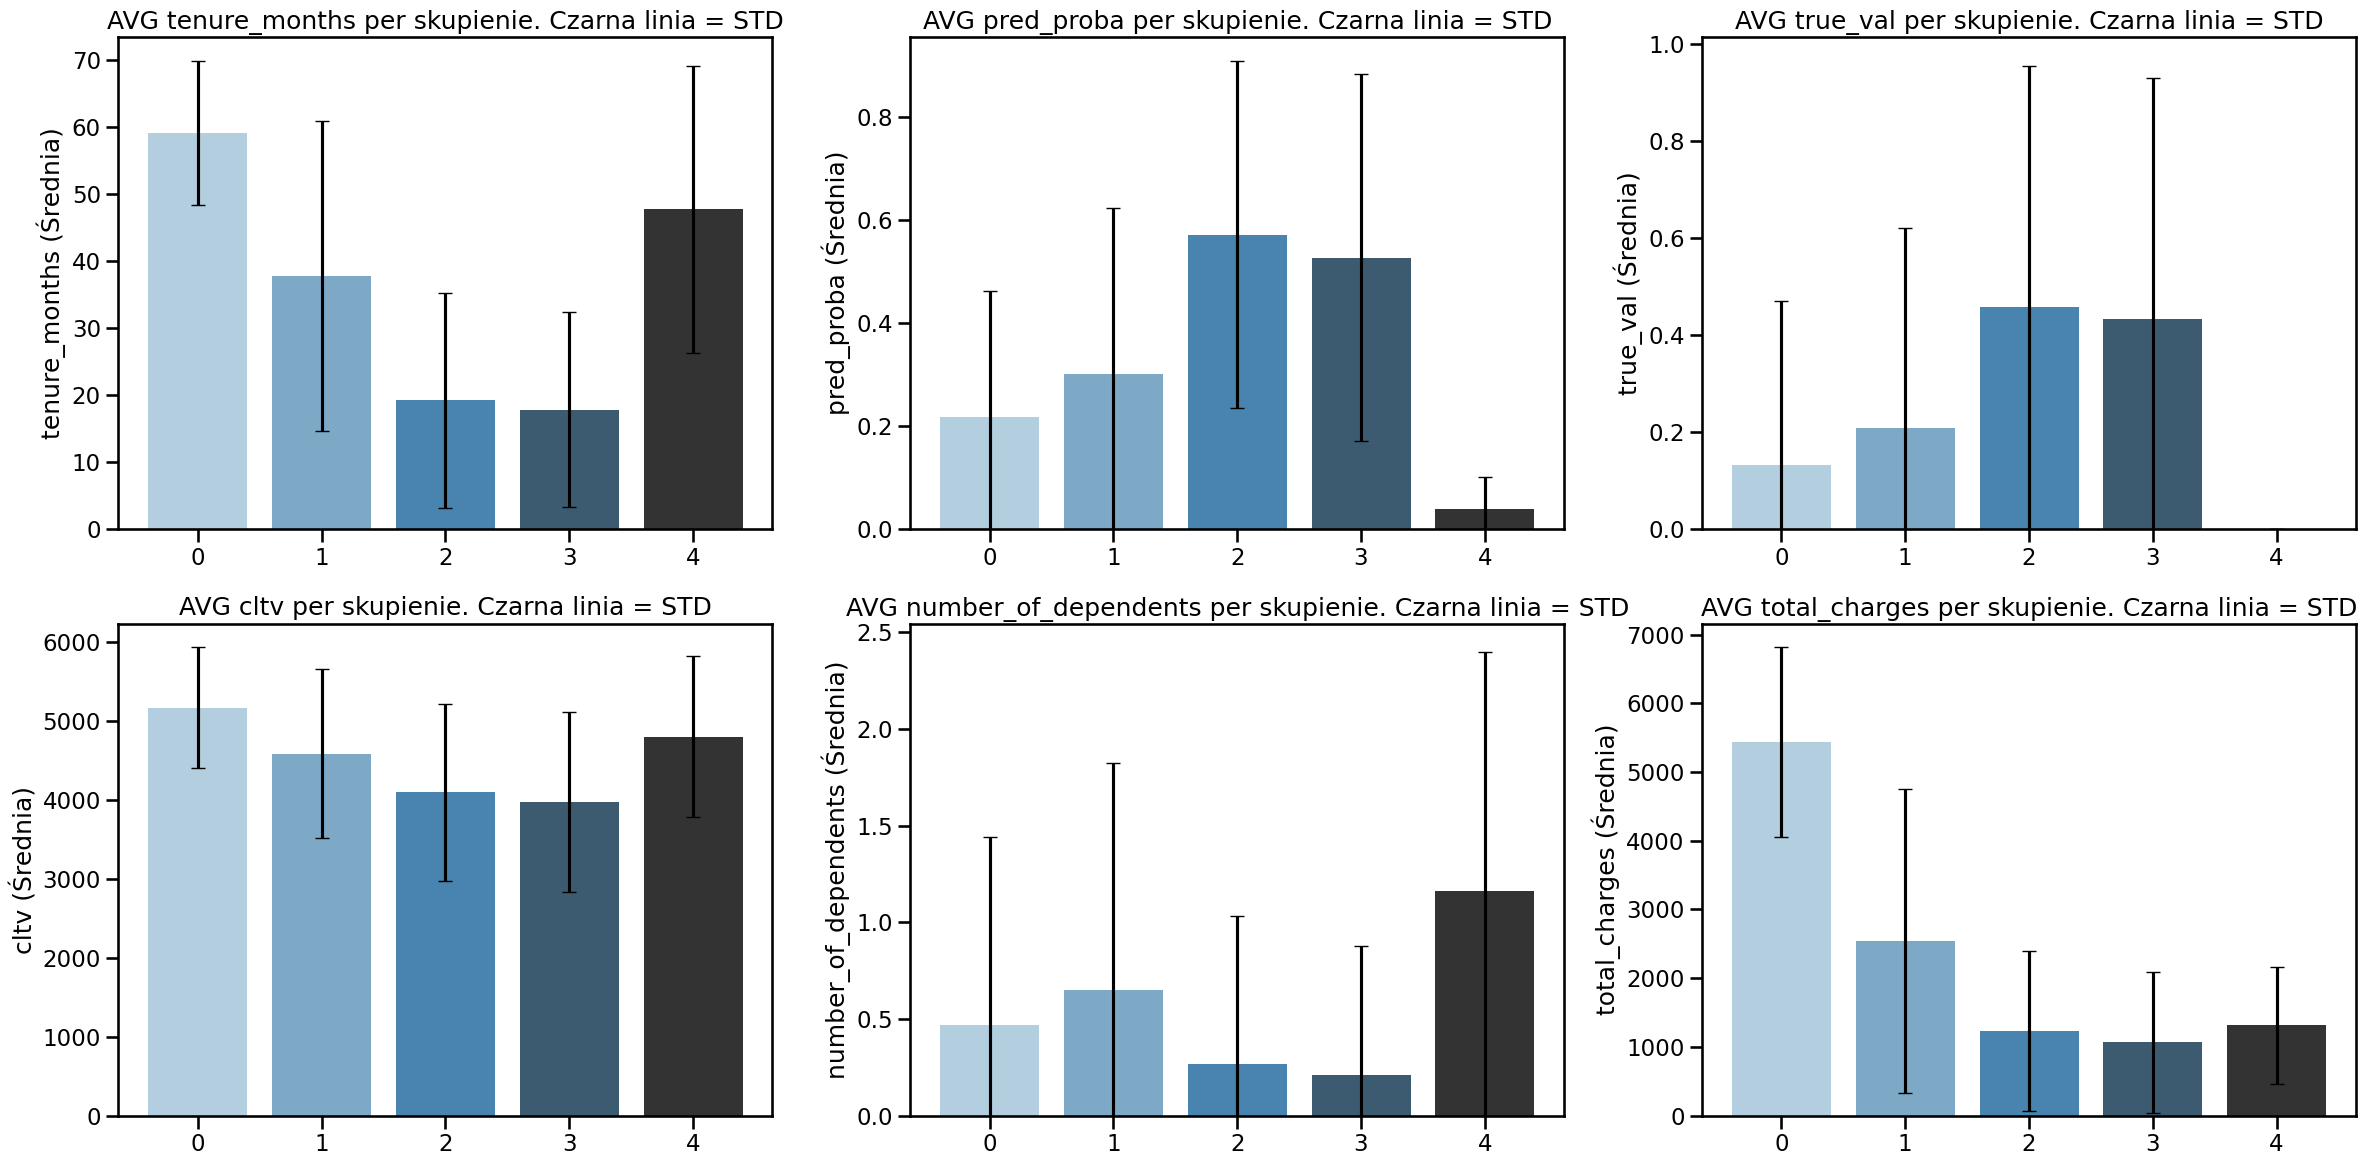

In [1278]:
cols = ['tenure_months','pred_proba','true_val','cltv','number_of_dependents','total_charges']
clusters = [0,1,2,3,4]
i = 1
plt.figure(figsize=(24, 12))
for col in cols: 
    plt.subplot(2,3,i)
    means = cluster_analysis.loc[col].loc['mean']
    stds = cluster_analysis.loc[col].loc['std']

   

    # Rysujemy słupki (barplot)
    ax = sns.barplot(x=clusters, y=means, palette='Blues_d', hue=clusters, legend=False)

    # Ręcznie nakładamy słupki błędu (Error Bars)
    ax.errorbar(x=clusters, y=means, yerr=stds, fmt='none', c='black', capsize=5)

    plt.title(f'AVG {col} per skupienie. Czarna linia = STD')
    plt.ylabel(f'{col} (Średnia)')
    plt.ylim(bottom=0)
    i+=1
plt.tight_layout()

Wnioski z analizy średnich wartości kluczowych zmiennych w wyodrębnionych skupieniach można wyciągnąć wnioski, które pokrywają się z tym co zostało zauważone w trakcie EDA. Skupienie 4, które w rzeczywistości nie miało żadnego klienta, który zrezygnował z usług (Model prawie idealnie to ogarnął) jest "Łatwe" do oddzielenia od reszty. Widać, że składa się z klientów, którzy są z firmą relatywnie długo (Średnio 50 miesięcy) Średnio mają najwięcej osób na jednym rachunku oraz płacą co ciekawe relatywnie nie wiele (Niskie oczekiwania).  Skupienia z najgorszą skutecznością modelu zawierają głównie osoby będące krótko z firmą. Co więcej realne średnie prawdopodobieństwa odejścia w ugrupowaniach są bardzo zbliżone do wartości przewidzianych przez model

### Głębokie Profilowanie Segmentów: Weryfikacja Charakterystyki Klastrów

Aby zrozumieć fizyczne podłoże sukcesów i błędów modelu w poszczególnych ugrupowaniach, przeprowadzono analizę statystyk opisowych dla kluczowych zmiennych wewnątrz każdego z wyodrębnionych klastrów. 

Wyniki tego profilowania w pełni korespondują z pierwotnymi hipotezami postawionymi na etapie Eksploracyjnej Analizy Danych (EDA), zamykając proces analityczny w spójną całość.

#### Skupienie 4: "Bezpieczny Rdzeń" (Wysoka skuteczność modelu)

Skupienie nr 4 to segment, w którym model wykazał się niemal bezbłędną skutecznością, precyzyjnie przypisując klientom minimalne prawdopodobieństwo odejścia. Rzeczywisty wskaźnik rotacji (Churn Rate) wyniósł w tej grupie 0%. 
Analiza średnich wartości demaskuje profil tych klientów jako "łatwy" do odseparowania dla algorytmu. Charakteryzują się oni:
* **Długim stażem (Tenure):** Średnio około 50 miesięcy współpracy z operatorem.
* **Rozbudowaną siecią powiązań:** Najwyższa średnia liczba osób zależnych (Dependents) podpiętych pod jeden rachunek.
* **Niskimi opłatami (Monthly Charges):** Stosunkowo niskie rachunki miesięczne, co sugeruje wybór podstawowych pakietów i posiadanie niskich oczekiwań względem zaawansowanych usług, co minimalizuje ich podatność na agresywne oferty konkurencji.

#### Skupienia Wysokiego Błędu (2, 3): "Nowi Klienci"

Skupienia, w których model wykazywał najwyższy stopień niepewności i generował najwięcej błędów klasyfikacyjnych, współdzielą jedną krytyczną cechę wspólną: bardzo krótki staż (Tenure). Są to w przeważającej mierze nowi klienci. Ograniczona historia współpracy i brak ugruntowanych wzorców behawioralnych sprawiają, że drzewa decyzyjne mają zbyt mało informacji, by precyzyjnie ocenić ich intencje.

### Makroskopowa Kalibracja Modelu

Najważniejszym wnioskiem płynącym z klastrowania jest analiza rozkładu samego prawdopodobieństwa. Zauważono, że **rzeczywiste odsetki odejść (Real Churn Rate) wewnątrz poszczególnych segmentów są niemal identyczne ze średnimi wartościami prawdopodobieństwa przewidzianymi przez model XGBoost.**

> **Wartość Biznesowa (Well-Calibrated Model):** Zbieżność predykcji z rzeczywistością

## Finalna walidacja na nigdy nie widzianym przez model  TEST SET


              precision    recall  f1-score   support

           0       0.95      0.83      0.89       236
           1       0.68      0.89      0.77        94

    accuracy                           0.85       330
   macro avg       0.81      0.86      0.83       330
weighted avg       0.87      0.85      0.85       330

0.9468535881716553


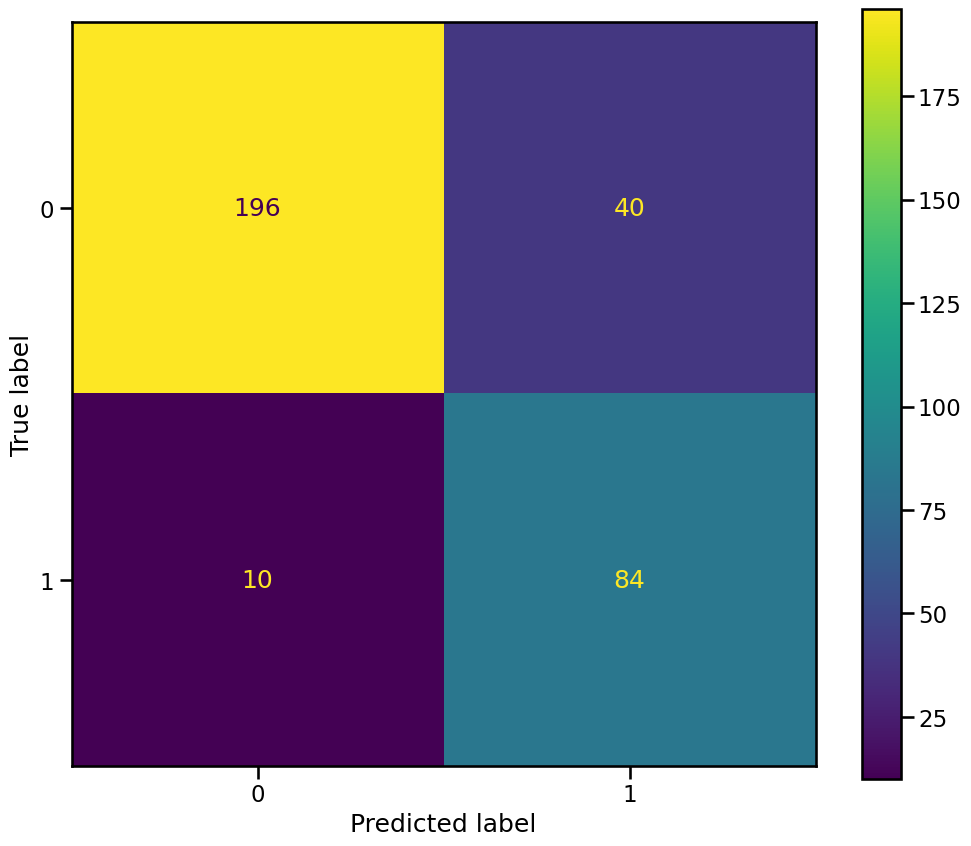

In [74]:
test_preds_proba = best_xgb.predict_proba(X_test)[:,1]
test_preds= best_xgb.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, test_preds)
print(classification_report(y_test, test_preds))
print(roc_auc_score(y_test, test_preds_proba))

## Walidacja na zbiorze testowym przebiegła pomyślnie. Jakość/ performance modelu praktycznie identyczny jak na zbiorze walidacyjnym 

## Retraining na 95% zbioru (Train set + Dev set)

In [64]:
from src.model.train import train_and_save_model

In [ ]:
full_X  = pd.concat([X_train, X_dev])
full_y = pd.concat([y_train, y_dev])

base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
db_path = os.path.join(base_dir, 'src', 'model', 'optuna_xgb_results.db')
storage_url = f"sqlite:///{db_path}"
study = optuna.load_study(study_name='churn_opt_xgb_v1', storage=storage_url)
print(f" Załadowano study! Najlepszy wynik: {study.best_value}")

best_xgb_study = study.best_params
fin_xgb = xgb.XGBClassifier(**best_xgb_study)

fin_xgb = Pipeline([
    ('preprocessor', preprocessor()),
    ('classifier', fin_xgb)
])

fin_xgb.fit(full_X, full_y)

final_preds = fin_xgb.predict(X_test)


 Załadowano study! Najlepszy wynik: 0.939491793252231


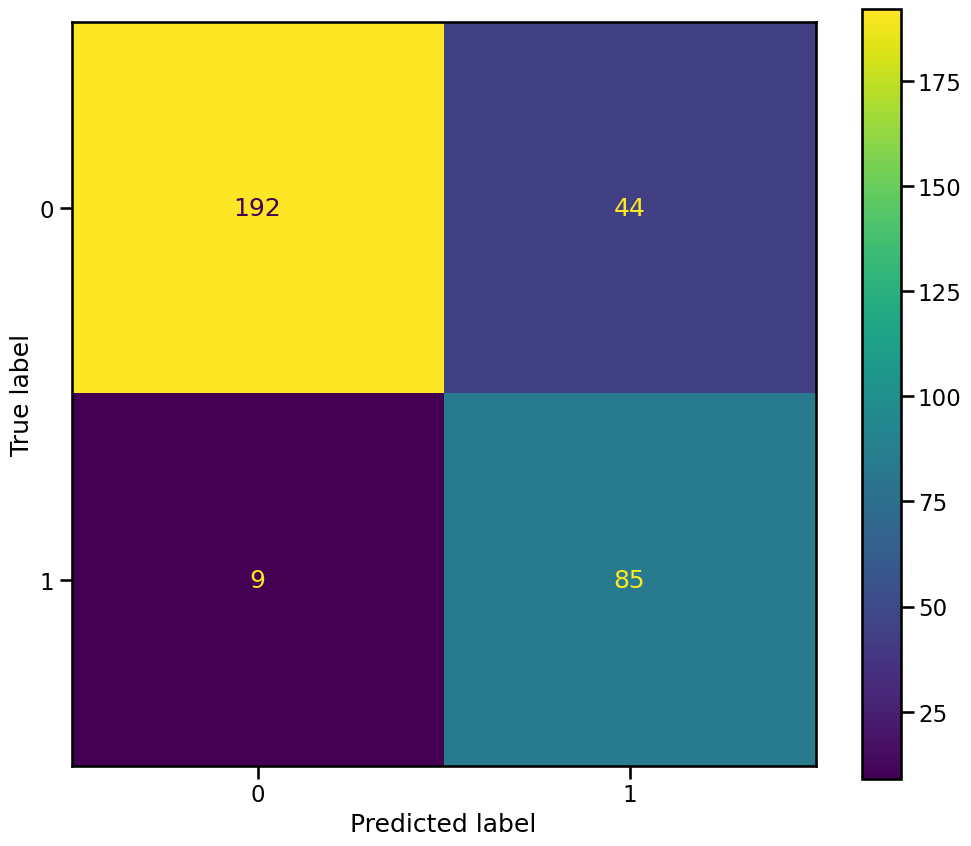

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, final_preds)

### Zweryfikowano na 5% danych testowych, że model jest stabilny i jakość predykcji się ani nie poprawiła ani nie pogorszyła w wyniku wytrenowania modelu na 95% danych. Zdecydowano się na zapisanie takiego modelu i wykorzystanie w konteneryzacji przez Docker

In [34]:
train_and_save_model(return_model=False)

Wczytano bazę
(7043, 53)
Liczba rekordów po usunięciu nowych klientów: 6589
 Załadowano study! Najlepszy wynik: 0.939491793252231
Zakończono i zapisano model w /Users/michalszczepkowski/Documents/03_Projects/01_Own_projects/21_12_25_customer_churn/final_model.joblib


In [3]:
model = train_and_save_model(return_model=True, save_model=False)

Liczba rekordów po usunięciu nowych klientów: 6589
 Załadowano study! Najlepszy wynik: 0.939491793252231


In [24]:
### ZAPIS
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(X_test.index,100)
df_ori.iloc[sample_idx,].to_csv('example.csv', index = False)

## Podsumowanie Projektu (Executive Summary)

W ramach niniejszego projektu przeprowadzono kompleksowy proces budowy i ewaluacji systemu predykcyjnego do wykrywania rezygnacji klientów (Churn Prediction). Skonstruowano i poddano rygorystycznej optymalizacji dwa zaawansowane podejścia analityczne:
1. **Głęboką Sieć Neuronową (ANN)**
2. **Model Gradient Boostingu (XGBoost)**

### Przebieg Eksperymentów i Wybór Architektury docelowej

W obu przypadkach proces modelowania rozpoczął się od stworzenia modeli bazowych (Baseline). Wyniki eksperymentów wykazały, że modele domyślne osiągały rezultaty niewiele gorsze od swoich w pełni zoptymalizowanych wersji. Systematycznie natrafiano na barierę informacyjną – tzw. "szklany sufit" predykcyjny na poziomie metryki ROC AUC rzędu 0.94.

Główną przyczyną tego zjawiska jest ograniczony wolumen danych treningowych. Z tego samego powodu ostateczną decyzją architektoniczną było wytypowanie modelu **XGBoost** jako rozwiązania produkcyjnego. 

**Uzasadnienie wyboru:** XGBoost okazał się modelem "lżejszym" pod kątem alokacji pamięci i złożoności obliczeniowej, a jednocześnie minimalnie skuteczniejszym od sieci neuronowej. Architektury oparte na Deep Learningu wymagają drastycznie większych zbiorów danych do rozwinięcia swojego pełnego potencjału i w obecnych uwarunkowaniach stanowiłyby nieuzasadniony narzut technologiczny (Overengineering).

### Ocena Skuteczności Finalnego Modelu

Mimo osiągnięcia limitu możliwości obecnego zbioru danych, wypracowany model uznaje się za sukces. Weryfikacja na rozłącznych zbiorach testowych i walidacyjnych potwierdziła wysoką stabilność i skuteczność systemu:

* **ROC AUC (0.94):** Wynik ten potwierdza wysoce ponadprzeciętną zdolność modelu do separacji klas. Algorytm z niemal 94-procentowym prawdopodobieństwem oceni klienta faktycznie odchodzącego jako bardziej ryzykownego niż klienta lojalnego.
* **Weighted F1-Score (0.85 - 0.86):** Podczas gdy AUC ocenia globalną zdolność separacji, F1-Score ocenia jakość twardych decyzji klasyfikacyjnych po nałożeniu progu odcięcia. Wynik na poziomie ~0.86 wariantu ważonego (uwzględniającego dysproporcję klas) oznacza wysoce zoptymalizowany kompromis. 
  * *Interpretacja Biznesowa:* Model precyzyjnie wyłapuje znakomitą większość klientów faktycznie planujących odejście (wysoka czułość), jednocześnie rzadko myląc się w stosunku do klientów bezpiecznych (wysoka precyzja). W praktyce operacyjnej przełoży się to na zwiększenie efektywności alokacji budżetu marketingowego – zniżki i akcje retencyjne trafią w 85-86% przypadków dokładnie tam, gdzie są niezbędne do ratowania przychodu firmy, minimalizując zjawisko "przepalania" budżetu na lojalnych użytkowników.

Rozwiązania z zakresu Machine Learningu wykazały potężny potencjał w optymalizacji procesów retencyjnych w firmie. Aby jednak przełamać zidentyfikowaną barierę technologiczną i dalej podnosić skuteczność systemu, rekomenduje się następujące działania:

* **Priorytetyzacja Akwizycji Danych:** Najważniejszym krokiem rozwojowym powinno być znaczne powiększenie historycznego zbioru danych. Zasilenie obecnego, wysoce logicznego i dobrze skalibrowanego modelu większą liczbą obserwacji (np. poprzez agregację danych z kolejnych kwartałów roboczych) naturalnie poprawi jego zdolności generalizacyjne i prawdopodobnie pozwoli przebić obecny "szklany sufit".
* **Rozszerzenie Przestrzeni Cech (Feature Engineering):** Wzbogacenie logów o dodatkowe zmienne, takie jak dane behawioralne z aplikacji mobilnej czy historia kontaktów z Biurem Obsługi Klienta (BOK), co pozwoli zniwelować błędy w segmentach "nowych klientów".